In [1]:
print("hello1")

hello1


In [2]:
import os, sys

PF_ROOT = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4"
PF_PY   = r"C:\Program Files\DIgSILENT\PowerFactory 2025 SP4\Python\3.10"
PF_BIN  = PF_ROOT + r"\Bin"

# 1) powerfactory module
sys.path.append(PF_PY)

# 2) DLL search paths (prevents DLL load errors)
os.environ["PATH"] = PF_ROOT + ";" + PF_BIN + ";" + os.environ["PATH"]
try:
    os.add_dll_directory(PF_ROOT)
    os.add_dll_directory(PF_BIN)
except Exception:
    pass

import powerfactory as pf

# ENGINE MODE connection (PF must be closed)
app = pf.GetApplicationExt("ADMIN")   # try without "ADMIN" if needed
if app is None:
    raise RuntimeError("Could not start PowerFactory engine mode.")

# Activate your project
rc = app.ActivateProject("IEEE33_RE")
print("ActivateProject return:", rc)

# Activate first study case
study = app.GetProjectFolder("study")
cases = study.GetContents("*.IntCase")
print("Study cases:", [c.loc_name for c in cases])
cases[0].Activate()

# Run load flow
ldf = app.GetFromStudyCase("ComLdf")
print("Load flow return:", ldf.Execute())


ActivateProject return: 0
Study cases: ['Study Case']
Load flow return: 0


In [3]:
# DO NOT call pf.GetApplication() here.
# Just use the existing app from your earlier cell.

app.ClearOutputWindow()
print("Connected to PF OK")


Connected to PF OK


In [4]:
terms = app.GetCalcRelevantObjects("*.ElmTerm")
lines = app.GetCalcRelevantObjects("*.ElmLne")
loads = app.GetCalcRelevantObjects("*.ElmLod")
xnets = app.GetCalcRelevantObjects("*.ElmXnet")  # External Grid

app.PrintPlain(f"Terminals: {len(terms)}")
app.PrintPlain(f"Lines: {len(lines)}")
app.PrintPlain(f"Loads: {len(loads)}")
app.PrintPlain(f"External Grids: {len(xnets)}")


In [5]:
# Uses the existing `app` you already created with GetApplicationExt()

# Make sure you're in the right project/study case
app.ActivateProject("IEEE33_RE")
study = app.GetProjectFolder("study")
cases = study.GetContents("*.IntCase")
cases[0].Activate()

# Get objects
terms = app.GetCalcRelevantObjects("*.ElmTerm")
lines = app.GetCalcRelevantObjects("*.ElmLne")
loads = app.GetCalcRelevantObjects("*.ElmLod")
xnets = app.GetCalcRelevantObjects("*.ElmXnet")  # External Grid

# Print to Jupyter (this is what you will see)
print("Terminals (ElmTerm):", len(terms))
print("Lines (ElmLne):", len(lines))
print("Loads (ElmLod):", len(loads))
print("External Grids (ElmXnet):", len(xnets))

# If everything is 0, the network might be empty or not in the active grid


Terminals (ElmTerm): 40
Lines (ElmLne): 38
Loads (ElmLod): 39
External Grids (ElmXnet): 2


In [6]:
# Reuse existing app (do NOT call pf.GetApplication* again)

app.ActivateProject("IEEE33_RE")

# Study case activation (safe)
study = app.GetProjectFolder("study")
cases = study.GetContents("*.IntCase")
cases[0].Activate()

# Correct folder for Network Data / Network Model
netdat = app.GetProjectFolder("netdat")
print("netdat is None?", netdat is None)

# List what exists in the project (include subfolders = 1)
grids = netdat.GetContents("*.ElmNet", 1)
terms = netdat.GetContents("*.ElmTerm", 1)
lines = netdat.GetContents("*.ElmLne", 1)
loads = netdat.GetContents("*.ElmLod", 1)
xnets = netdat.GetContents("*.ElmXnet", 1)

print("Grids (ElmNet):", [g.loc_name for g in grids])
print("Terminals:", len(terms))
print("Lines:", len(lines))
print("Loads:", len(loads))
print("External Grids:", len(xnets))


netdat is None? False
Grids (ElmNet): ['Grid(1)', 'Grid', 'Grid(2)', 'Grid(3)']
Terminals: 40
Lines: 38
Loads: 39
External Grids: 2


In [7]:
# =========================
# PART A: Build a small network by code (PowerFactory)
# Creates: Bus1 -- Line1 -- Bus2 with Load at Bus2 and External Grid (slack) at Bus1
# =========================

import powerfactory as pf


# ---------- Helper: normalize PF return types into a plain list ----------
def pf_list(x):
    """Normalize PowerFactory GetContents()/Get* results into a plain Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        # flatten list-of-lists
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    # single DataObject
    return [x]


# ---------- 1) Get the application ONCE ----------
# If you already created `app` earlier in this Jupyter kernel, reuse it.
try:
    app
    print("Reusing existing 'app' object")
except NameError:
    # Use GetApplicationExt() if you're in engine mode externally.
    # If you're running this INSIDE PF (ComPython), GetApplication() is fine.
    app = pf.GetApplication()
    if app is None:
        raise RuntimeError("Could not get PowerFactory application. If using engine mode, PF GUI must be closed.")
    print("Created new 'app' object")


# ---------- 2) Activate your project + study case ----------
PROJECT_NAME = "IEEE33_RE"
STUDY_CASE_NAME = "Study Case"  # adjust if your study case name differs

rc = app.ActivateProject(PROJECT_NAME)
print(f"ActivateProject return: {rc}")
if rc != 0:
    raise RuntimeError(f"Could not activate project '{PROJECT_NAME}' (return code {rc}).")

study_folder = app.GetProjectFolder("study")
if study_folder is None:
    raise RuntimeError("Study folder not found (GetProjectFolder('study') returned None).")

cases = pf_list(study_folder.GetContents("*.IntCase"))
print("Study cases found:", [c.loc_name for c in cases])

if not cases:
    raise RuntimeError("No study cases found. Create a Study Case in PF first.")

case = next((c for c in cases if c.loc_name == STUDY_CASE_NAME), None)
if case is None:
    print(f"Study case '{STUDY_CASE_NAME}' not found. Using first available.")
    case = cases[0]

case.Activate()
print(f"Activated study case: {case.loc_name}")


# ---------- 3) Find your Grid (ElmNet) inside Network Data (netdat) ----------
netdat = app.GetProjectFolder("netdat")
if netdat is None:
    raise RuntimeError("netdat folder not found. (Project not activated?)")

grids = pf_list(netdat.GetContents("*.ElmNet", 1))
if not grids:
    raise RuntimeError("No ElmNet grids found in netdat.")

grid = next((g for g in grids if g.loc_name == "Grid"), None)
if grid is None:
    grid = grids[0]

print(f"Using grid: {grid.loc_name}")


# ---------- 4) Small helper: get-or-create inside a parent object ----------
def get_or_create(parent, cls_name, obj_name):
    # Try to find exact object by name + class under parent
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name} under {parent}")
    return obj


# ---------- 5) Create Bus1 and Bus2 (ElmTerm) ----------
bus1 = get_or_create(grid, "ElmTerm", "Bus1")
bus2 = get_or_create(grid, "ElmTerm", "Bus2")

# Set nominal voltage (try uknom first; if it fails, we just warn and continue)
for b in (bus1, bus2):
    try:
        b.SetAttribute("uknom", 12.66)  # kV
    except Exception as e:
        print(f"WARNING: Could not set uknom for {b.loc_name}. Error: {e}")

print("Created/verified terminals: Bus1, Bus2")


# ---------- 6) Create External Grid (slack) and connect to Bus1 via cubicle ----------
xnet = get_or_create(grid, "ElmXnet", "Slack")

cub_slack = get_or_create(bus1, "StaCubic", "Cub_Slack")
cub_slack.obj_id = xnet

print("Created/connected External Grid (Slack) at Bus1")


# ---------- 7) Create Load and connect to Bus2 via cubicle ----------
load1 = get_or_create(grid, "ElmLod", "Load_Bus2")

# Set load P/Q (try plini/qlini; if attribute differs, warn)
try:
    load1.SetAttribute("plini", 1.0)   # MW
    load1.SetAttribute("qlini", 0.6)   # MVAr
except Exception as e:
    print(f"WARNING: Could not set plini/qlini for {load1.loc_name}. Error: {e}")

cub_load = get_or_create(bus2, "StaCubic", "Cub_Load")
cub_load.obj_id = load1

print("Created/connected Load at Bus2")


# ---------- 8) Create a line type (TypLne) in Equipment Type Library (equip) ----------
equip = app.GetProjectFolder("equip")
if equip is None:
    raise RuntimeError("equip folder not found (equipment type library).")

typ_line = pf_list(equip.GetContents("IEEE33_LineType.TypLne", 1))
if typ_line:
    typ_line = typ_line[0]
else:
    typ_line = equip.CreateObject("TypLne", "IEEE33_LineType")
    if typ_line is None:
        raise RuntimeError(
            "Could not create TypLne in equip folder.\n"
            "Fix in PF GUI: Data Manager → Equipment Type Library → Lines → New → Line Type (TypLne)\n"
            "Then rerun this script."
        )

# Set line type parameters (example values)
for attr, val in [("rline", 0.2), ("xline", 0.4), ("rline0", 0.6), ("xline0", 1.2)]:
    try:
        typ_line.SetAttribute(attr, val)
    except Exception as e:
        print(f"WARNING: Could not set {attr} on {typ_line.loc_name}. Error: {e}")

print("Created/verified line type: IEEE33_LineType")


# ---------- 9) Create Line and connect Bus1-Bus2 (via cubicles) ----------
line1 = get_or_create(grid, "ElmLne", "Line1")
line1.typ_id = typ_line

try:
    line1.SetAttribute("dline", 1.0)  # km
except Exception as e:
    print(f"WARNING: Could not set dline for {line1.loc_name}. Error: {e}")

cub_l1_i = get_or_create(bus1, "StaCubic", "Cub_Line1_Bus1")
cub_l1_j = get_or_create(bus2, "StaCubic", "Cub_Line1_Bus2")
cub_l1_i.obj_id = line1
cub_l1_j.obj_id = line1

print("Created/connected Line1 between Bus1 and Bus2")


# ---------- 10) Verify objects exist in grid ----------
terms_all = pf_list(grid.GetContents("*.ElmTerm", 0))
lines_all = pf_list(grid.GetContents("*.ElmLne", 0))
loads_all = pf_list(grid.GetContents("*.ElmLod", 0))
xnet_all  = pf_list(grid.GetContents("*.ElmXnet", 0))

print("----- INVENTORY IN GRID -----")
print("Terminals:", [t.loc_name for t in terms_all])
print("Lines:",     [l.loc_name for l in lines_all])
print("Loads:",     [ld.loc_name for ld in loads_all])
print("Xnets:",     [x.loc_name for x in xnet_all])


# ---------- 11) Run load flow ----------
ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in the active Study Case. Add a Load Flow command object in the Study Case.")

ret = ldf.Execute()
print(f"Load flow return: {ret} (0 = OK)")


Reusing existing 'app' object
ActivateProject return: 0
Study cases found: ['Study Case']
Activated study case: Study Case
Using grid: Grid
Created/verified terminals: Bus1, Bus2
Created/connected External Grid (Slack) at Bus1
Created/connected Load at Bus2
Created/verified line type: IEEE33_LineType
Created/connected Line1 between Bus1 and Bus2
----- INVENTORY IN GRID -----
Terminals: ['BESS_LV_Bus33', 'Bus1', 'Bus10', 'Bus11', 'Bus12', 'Bus13', 'Bus14', 'Bus15', 'Bus16', 'Bus17', 'Bus18', 'Bus19', 'Bus2', 'Bus20', 'Bus21', 'Bus22', 'Bus23', 'Bus24', 'Bus25', 'Bus26', 'Bus27', 'Bus28', 'Bus29', 'Bus3', 'Bus30', 'Bus31', 'Bus32', 'Bus33', 'Bus4', 'Bus5', 'Bus6', 'Bus7', 'Bus8', 'Bus9', 'BusHV_33kV', 'PV_LV_Bus18', 'PV_LV_Bus30', 'PV_LV_Bus6', 'WIND_LV_Bus14', 'WIND_LV_Bus25']
Lines: ['L_10_11', 'L_11_12', 'L_12_13', 'L_12_22', 'L_13_14', 'L_14_15', 'L_15_16', 'L_16_17', 'L_17_18', 'L_18_33', 'L_19_20', 'L_1_2', 'L_20_21', 'L_21_22', 'L_21_8', 'L_23_24', 'L_24_25', 'L_25_29', 'L_26_27',

In [8]:
# =========================
# DIAGNOSTICS: Why Load Flow returns 1
# =========================

# 1) Try to access PF Output Window (may or may not work in your engine-mode setup)
try:
    ow = app.GetOutputWindow()
    try:
        ow.Clear()
    except Exception:
        pass
except Exception:
    ow = None

def show_output(title="PowerFactory Output Window"):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    if ow is None:
        print("(No OutputWindow object available in this session.)")
        return
    try:
        try:
            ow.Flush()
        except Exception:
            pass
        txt = ow.GetContent()
        print(txt if txt else "(Output window is empty)")
    except Exception as e:
        print(f"(Could not read output window content: {e})")


# 2) Check calculation-relevant objects (this is the BIG clue)
def calc_relevant_snapshot():
    grids_cr = app.GetCalcRelevantObjects("*.ElmNet")
    terms_cr = app.GetCalcRelevantObjects("*.ElmTerm")
    lines_cr = app.GetCalcRelevantObjects("*.ElmLne")
    loads_cr = app.GetCalcRelevantObjects("*.ElmLod")
    xnet_cr  = app.GetCalcRelevantObjects("*.ElmXnet")

    print("\n--- CALC-RELEVANT SNAPSHOT ---")
    print("Grids (ElmNet):", [g.loc_name for g in grids_cr])
    print("Terminals (ElmTerm):", len(terms_cr))
    print("Lines (ElmLne):", len(lines_cr))
    print("Loads (ElmLod):", len(loads_cr))
    print("External Grids (ElmXnet):", len(xnet_cr))

calc_relevant_snapshot()


# 3) Try to activate the grid (may or may not work depending on PF setup)
try:
    rc = grid.Activate()
    print(f"\nTried grid.Activate() return: {rc}")
except Exception as e:
    print("\ngrid.Activate() not available/failed:", e)

calc_relevant_snapshot()


# 4) Check line connectivity (optional)
print("\n--- LINE CONNECTIVITY CHECK ---")
try:
    b1 = line1.GetAttribute("r:bus1:e:cBusBar")
    b2 = line1.GetAttribute("r:bus2:e:cBusBar")
    print("Line1 bus1:", b1.loc_name if b1 else None)
    print("Line1 bus2:", b2.loc_name if b2 else None)
except Exception as e:
    print("Could not read line connectivity via r:bus1/r:bus2:", e)


# 5) Run load flow and show any output
try:
    if ow is not None:
        try:
            ow.Clear()
        except Exception:
            pass
except Exception:
    pass

ldf = app.GetFromStudyCase("ComLdf")
ret = ldf.Execute()
print(f"\nLoad flow return: {ret}   (0 = OK, 1 = diverged)")

show_output("Output Window after Load Flow")



--- CALC-RELEVANT SNAPSHOT ---
Grids (ElmNet): ['Grid', 'Grid(1)', 'Grid(2)', 'Grid(3)', 'Summary Grid']
Terminals (ElmTerm): 40
Lines (ElmLne): 38
Loads (ElmLod): 39
External Grids (ElmXnet): 2

Tried grid.Activate() return: 1

--- CALC-RELEVANT SNAPSHOT ---
Grids (ElmNet): ['Grid', 'Grid(1)', 'Grid(2)', 'Grid(3)', 'Summary Grid']
Terminals (ElmTerm): 40
Lines (ElmLne): 38
Loads (ElmLod): 39
External Grids (ElmXnet): 2

--- LINE CONNECTIVITY CHECK ---
Line1 bus1: Bus1
Line1 bus2: Bus2

Load flow return: 0   (0 = OK, 1 = diverged)

Output Window after Load Flow
["info - Element 'Slack_HV' is local reference in separated area of 'BusHV_33kV'", 'info - Calculating load flow...', 'info - -------------------------------------------------------------------------------------', 'info - Start Newton-Raphson Algorithm...', 'info - Load flow iteration: 0', 'info - Load flow iteration: 1', 'info - Load flow iteration: 2', 'info - Newton-Raphson converged with 2 iterations.', 'info - Load flow ca

In [9]:
import csv
import powerfactory as pf

# ---------- Helpers ----------
def pf_list(x):
    """Normalize PowerFactory return types into a plain Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def read_csv_dicts(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def set_any(obj, candidates, value):
    """Try setting one of several attribute names (PF differs across versions/templates)."""
    for a in candidates:
        try:
            obj.SetAttribute(a, value)
            return True, a
        except Exception:
            pass
    return False, None

def try_print_output(app, title="PF Output"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*80)
        print(title)
        print("="*80)
        print(ow.GetContent())
    except Exception:
        pass

# ---------- Connection ----------
# If you already have 'app' from earlier cells, reuse it
try:
    app
    print("Reusing existing 'app'")
except NameError:
    # Engine mode (PF will show NON-INTERACTIVE MODE in title bar)
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PowerFactory engine. Close PF GUI and try again.")
    print("Created new 'app'")

# Show PF window (optional)
try:
    app.Show()
except Exception:
    pass

# ---------- USER SETTINGS ----------
PROJECT_NAME = "IEEE33_RE"
GRID_NAME = "Grid"

LV_KV = 12.66
HV_KV = 33.0

LINES_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_lines.csv"
LOADS_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_loads.csv"
EXPORT_VOLTAGES_CSV = r"C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv"

# IEEE-33 normally-open tie lines
TIE_LINES = {(21,8), (9,15), (12,22), (18,33), (25,29)}

# ---------- Activate project + study case ----------
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found. Create one in PowerFactory first.")
cases[0].Activate()
print("Active Study Case:", cases[0].loc_name)

# Load flow command
ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case. Add a Load Flow command (ComLdf) to the Study Case.")

# Diagram layout tool command (optional but recommended)
comlayout = app.GetFromStudyCase("ComSgllayout")

# ---------- Get Grid ----------
netdat = app.GetProjectFolder("netdat")
grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found. Found grids: {[g.loc_name for g in grids]}")
print("Using grid:", grid.loc_name)

# ---------- Read CSVs ----------
line_rows = read_csv_dicts(LINES_CSV)
load_rows = read_csv_dicts(LOADS_CSV)

print("Lines in CSV:", len(line_rows))
print("Loads in CSV:", len(load_rows))

# Detect if loads are kW/kVAr
p_max = max(float(r["P_MW"]) for r in load_rows)
scale = 0.001 if p_max > 10 else 1.0
print("Load scaling:", ("kW->MW (÷1000)" if scale == 0.001 else "already MW"))

# ---------- Create LV buses Bus1..Bus33 ----------
buses = {}
for i in range(1, 34):
    name = f"Bus{i}"
    t = get_or_create(grid, "ElmTerm", name)
    set_any(t, ["uknom", "Unom"], LV_KV)
    buses[i] = t
print("Created/verified LV buses:", len(buses))

# ---------- Create HV bus for transformer + slack ----------
bus_hv = get_or_create(grid, "ElmTerm", "BusHV_33kV")
set_any(bus_hv, ["uknom", "Unom"], HV_KV)
print("Created/verified HV bus:", bus_hv.loc_name)

# ---------- Equipment type library ----------
equip = app.GetProjectFolder("equip")
if equip is None:
    raise RuntimeError("Equipment type library folder 'equip' not found.")

# ---------- Create Transformer TYPE (TypTr2): 33/12.66 kV ----------
typ_tr = pf_list(equip.GetContents("Typ_TR_33_12p66.TypTr2", 1))
typ_tr = typ_tr[0] if typ_tr else equip.CreateObject("TypTr2", "Typ_TR_33_12p66")
if typ_tr is None:
    raise RuntimeError("Could not create/find TypTr2 'Typ_TR_33_12p66' in equipment library.")

# Set nameplate data (try multiple attribute names to be safe)
ok_hv, a_hv = set_any(typ_tr, ["utrn_hv", "utrn_h", "Uhv", "uhv"], HV_KV)
ok_lv, a_lv = set_any(typ_tr, ["utrn_lv", "utrn_l", "Ulv", "ulv"], LV_KV)
ok_sn, a_sn = set_any(typ_tr, ["strn", "Sn", "srnom"], 10.0)  # MVA

# Optional: impedance (not strictly required for load flow to run, but good practice)
set_any(typ_tr, ["uktr", "uk"], 10.0)       # % short-circuit voltage
set_any(typ_tr, ["pcutr", "pCu"], 0.1)      # MW copper loss (rough placeholder)

print("Transformer type ready: Typ_TR_33_12p66",
      f"(HV set via {a_hv}, LV via {a_lv}, Sn via {a_sn})")

# ---------- Create Transformer ELEMENT (ElmTr2) and connect HV<->Bus1 ----------
tr = get_or_create(grid, "ElmTr2", "TR_33_12p66")
tr.typ_id = typ_tr

# Connect transformer using cubicles
cub_tr_hv = get_or_create(bus_hv, "StaCubic", "Cub_TR_HV")
cub_tr_lv = get_or_create(buses[1], "StaCubic", "Cub_TR_LV")
cub_tr_hv.obj_id = tr
cub_tr_lv.obj_id = tr

print("Transformer connected: BusHV_33kV <-> Bus1")

# ---------- Create/Move Slack to HV side ----------
xnet = get_or_create(grid, "ElmXnet", "Slack")

# Detach any old Slack cubicle on Bus1 (if it exists from older runs)
for cub in pf_list(buses[1].GetContents("*.StaCubic", 0)):
    try:
        if getattr(cub, "obj_id", None) == xnet:
            cub.obj_id = None
    except Exception:
        pass

cub_slack_hv = get_or_create(bus_hv, "StaCubic", "Cub_Slack_HV")
cub_slack_hv.obj_id = xnet
set_any(xnet, ["usetp"], 1.0)  # 1.0 pu voltage setpoint
print("Slack connected at HV bus (BusHV_33kV)")

# ---------- Create Lines (LV network) ----------
for r in line_rows:
    fb = int(float(r["from_bus"]))
    tb = int(float(r["to_bus"]))
    R  = float(r["R"])
    X  = float(r["X"])

    line_name = f"L_{fb}_{tb}"
    type_name = f"Typ_{fb}_{tb}"

    typ = pf_list(equip.GetContents(f"{type_name}.TypLne", 1))
    typ = typ[0] if typ else equip.CreateObject("TypLne", type_name)
    if typ is None:
        raise RuntimeError(f"Could not create/find line type {type_name}")

    # Nominal voltage for LV line types (prevents "Nominal voltage too low")
    set_any(typ, ["uline", "Unom"], LV_KV)
    set_any(typ, ["rline"], R)
    set_any(typ, ["xline"], X)

    # optional zero-seq placeholders
    set_any(typ, ["rline0"], 3*R)
    set_any(typ, ["xline0"], 3*X)

    line = get_or_create(grid, "ElmLne", line_name)
    line.typ_id = typ
    set_any(line, ["dline"], 1.0)

    # tie lines open
    if (fb, tb) in TIE_LINES or (tb, fb) in TIE_LINES:
        set_any(line, ["outserv"], 1)
    else:
        set_any(line, ["outserv"], 0)

    cubA = get_or_create(buses[fb], "StaCubic", f"Cub_{line_name}_A")
    cubB = get_or_create(buses[tb], "StaCubic", f"Cub_{line_name}_B")
    cubA.obj_id = line
    cubB.obj_id = line

print("Created/connected all LV lines (tie lines out of service)")

# ---------- Create Loads ----------
for r in load_rows:
    bus = int(float(r["bus"]))
    Praw = float(r["P_MW"])
    Qraw = float(r["Q_MVAr"])

    Pmw = Praw * scale
    Qmvar = Qraw * scale

    load_name = f"Load_Bus{bus}"
    lod = get_or_create(grid, "ElmLod", load_name)
    set_any(lod, ["plini"], Pmw)
    set_any(lod, ["qlini"], Qmvar)

    cub = get_or_create(buses[bus], "StaCubic", f"Cub_{load_name}")
    cub.obj_id = lod

print("Created/connected all loads")

# ---------- Run Load Flow ----------
ret = ldf.Execute()
print("Load flow return:", ret, "(0=OK)")
if ret != 0:
    try_print_output(app, "Output window after failed Load Flow")
    raise RuntimeError("Load flow did not converge. See output above.")

# ---------- Export voltages (LV buses) ----------
terms = app.GetCalcRelevantObjects("*.ElmTerm")
rows = []
for t in terms:
    try:
        u = t.GetAttribute("m:u")  # pu
        rows.append((t.loc_name, u))
    except Exception:
        pass

# sort Bus1..Bus33 first
def sort_key(name):
    if name.startswith("Bus") and name[3:].isdigit():
        return int(name[3:])
    return 9999

rows.sort(key=lambda x: sort_key(x[0]))

with open(EXPORT_VOLTAGES_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["bus", "U_pu"])
    w.writerows(rows)

u_min = min(u for _, u in rows)
u_max = max(u for _, u in rows)
print(f"Voltage range: min={u_min:.4f} pu, max={u_max:.4f} pu")
print("Saved voltages to:", EXPORT_VOLTAGES_CSV)

# =====================================================================
# Auto-generate / auto-insert + layout single line diagram
# =====================================================================
print("\nAttempting diagram layout (no drag/drop)...")

desktop = None
try:
    desktop = app.GetDesktop()
except Exception:
    desktop = None

if desktop is None:
    print("No Desktop available in this session (headless).")
    print("Open PF normally and run Diagram Layout Tool there.")
else:
    # Unfreeze graphics so PF is allowed to draw
    try:
        desktop.Unfreeze()
    except Exception:
        pass

    if comlayout is None:
        print("ComSgllayout not found in Study Case. Add it once, then rerun.")
    else:
        # These settings worked in your earlier runs; keep them.
        try:
            comlayout.iAction = 1
            comlayout.insertionMode = 1
        except Exception:
            pass

        rc_layout = comlayout.Execute()
        print("ComSgllayout return:", rc_layout)
        try_print_output(app, "Output window after ComSgllayout")
        print("Now check the Graphic tab: transformer should appear at the top (HV side).")


Reusing existing 'app'
ActivateProject return: 0
Active Study Case: Study Case
Using grid: Grid
Lines in CSV: 37
Loads in CSV: 32
Load scaling: kW->MW (÷1000)
Created/verified LV buses: 33
Created/verified HV bus: BusHV_33kV
Transformer type ready: Typ_TR_33_12p66 (HV set via utrn_h, LV via utrn_l, Sn via strn)
Transformer connected: BusHV_33kV <-> Bus1
Slack connected at HV bus (BusHV_33kV)
Created/connected all LV lines (tie lines out of service)
Created/connected all loads
Load flow return: 0 (0=OK)
Voltage range: min=0.0000 pu, max=0.0000 pu
Saved voltages to: C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv

Attempting diagram layout (no drag/drop)...
No Desktop available in this session (headless).
Open PF normally and run Diagram Layout Tool there.


In [10]:
import csv
import os
import powerfactory as pf

# -----------------------------
# Helpers
# -----------------------------
def pf_list(x):
    """Normalize PowerFactory return types into a plain Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def safe_get(obj, attr, default=None):
    try:
        return obj.GetAttribute(attr)
    except Exception:
        return default

def safe_set(obj, attr, val):
    try:
        obj.SetAttribute(attr, val)
        return True
    except Exception:
        return False

def try_print_output(app, title="PF Output"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*80)
        print(title)
        print("="*80)
        print(ow.GetContent())
    except Exception:
        pass

# -----------------------------
# Connection (reuse app if exists)
# -----------------------------
try:
    app
    print("Reusing existing 'app'")
except NameError:
    # If you run in engine mode:
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PowerFactory engine. Close PF GUI and try again.")
    print("Created new 'app'")

# -----------------------------
# USER SETTINGS
# -----------------------------
PROJECT_NAME = "IEEE33_RE"
GRID_NAME = "Grid"

# Choose PV buses (edit this list!)
# Tip: start with a few buses spread across feeder:
PV_BUSES = [6, 14, 18, 25, 30]   # <-- change to what you want

PENETRATIONS = [0, 10, 25, 50, 75]  # %

EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data"
SUMMARY_CSV = os.path.join(EXPORT_DIR, "pf_stage1_summary.csv")

SAVE_VOLTAGES_PER_CASE = True  # set False if you don't want many files

# -----------------------------
# Activate project + study case
# -----------------------------
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found.")
case = cases[0]
case.Activate()
print("Active Study Case:", case.loc_name)

ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case.")

# -----------------------------
# Get Grid
# -----------------------------
netdat = app.GetProjectFolder("netdat")
grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found. Found: {[g.loc_name for g in grids]}")
print("Using grid:", grid.loc_name)

# -----------------------------
# Get buses + loads + lines
# -----------------------------
terms = pf_list(grid.GetContents("*.ElmTerm", 1))
loads = pf_list(grid.GetContents("*.ElmLod", 1))
lines = pf_list(grid.GetContents("*.ElmLne", 1))

# Map Bus number from name "BusX"
bus_by_num = {}
for t in terms:
    n = getattr(t, "loc_name", "")
    if n.startswith("Bus"):
        try:
            idx = int(n.replace("Bus", ""))
            bus_by_num[idx] = t
        except Exception:
            pass

missing = [b for b in PV_BUSES if b not in bus_by_num]
if missing:
    raise RuntimeError(f"These PV buses are missing in your model: {missing}")

# -----------------------------
# Compute total load MW (from load flow setpoints plini)
# -----------------------------
total_load_mw = 0.0
for ld in loads:
    p = safe_get(ld, "plini", 0.0)
    if p is None:
        p = 0.0
    total_load_mw += float(p)

print(f"Total load (from plini): {total_load_mw:.4f} MW")

# -----------------------------
# Create PV generators at selected buses
# We'll use ElmGenstat (static generator)
# -----------------------------
pv_objs = []
for b in PV_BUSES:
    term = bus_by_num[b]
    pv = get_or_create(grid, "ElmGenstat", f"PV_Bus{b}")
    # connect via cubicle
    cub = get_or_create(term, "StaCubic", f"Cub_PV_Bus{b}")
    cub.obj_id = pv

    # make sure it is in service
    safe_set(pv, "outserv", 0)

    # set as PQ injection (typical: pgini/qgini)
    # We'll set Q=0 for Stage 1 (you can add Q control later if needed)
    safe_set(pv, "qgini", 0.0)

    pv_objs.append((b, pv))

print(f"PV units created/verified: {len(pv_objs)} on buses {PV_BUSES}")

# -----------------------------
# Scenario loop
# -----------------------------
summary_rows = []
for pen in PENETRATIONS:
    pv_total = (pen / 100.0) * total_load_mw

    # distribute equally across PV buses (simple baseline)
    per_pv = pv_total / len(pv_objs) if pv_objs else 0.0

    # update PV setpoints
    for b, pv in pv_objs:
        safe_set(pv, "pgini", per_pv)   # MW
        safe_set(pv, "qgini", 0.0)      # MVAr

    # run load flow
    ret = ldf.Execute()
    print(f"Penetration {pen}% -> PV total {pv_total:.4f} MW -> Load flow ret={ret}")

    if ret != 0:
        try_print_output(app, f"Load flow failed at {pen}%")
        summary_rows.append([pen, pv_total, "FAIL", "", "", "", ""])
        continue

    # voltages at terminals (pu)
    calc_terms = pf_list(app.GetCalcRelevantObjects("*.ElmTerm"))
    u_list = []
    for t in calc_terms:
        u = safe_get(t, "m:u", None)
        if u is not None:
            u_list.append(float(u))
    vmin = min(u_list) if u_list else None
    vmax = max(u_list) if u_list else None

    # line loading (%)
    calc_lines = pf_list(app.GetCalcRelevantObjects("*.ElmLne"))
    loading = []
    for ln in calc_lines:
        # common: c:loading or m:loading depending on PF setup
        val = safe_get(ln, "c:loading", None)
        if val is None:
            val = safe_get(ln, "m:loading", None)
        if val is not None:
            loading.append(float(val))
    max_loading = max(loading) if loading else None

    # losses (MW)
    # easiest robust approach: sum line losses if available
    # common: m:Ploss (MW) for lines (sometimes "m:Ploss")
    ploss = 0.0
    got_any_loss = False
    for ln in calc_lines:
        p = safe_get(ln, "m:Ploss", None)
        if p is not None:
            ploss += float(p)
            got_any_loss = True
    if not got_any_loss:
        ploss = ""  # leave blank if not available

    summary_rows.append([
        pen,
        round(pv_total, 6),
        "OK",
        round(vmin, 6) if vmin is not None else "",
        round(vmax, 6) if vmax is not None else "",
        round(max_loading, 3) if max_loading is not None else "",
        round(ploss, 6) if isinstance(ploss, float) else ploss
    ])

    # save voltages per case (optional)
    if SAVE_VOLTAGES_PER_CASE and u_list:
        volts_path = os.path.join(EXPORT_DIR, f"pf_stage1_voltages_{pen}.csv")
        # sort buses numerically if possible
        volt_rows = []
        for t in calc_terms:
            name = getattr(t, "loc_name", "")
            u = safe_get(t, "m:u", None)
            if u is None:
                continue
            volt_rows.append((name, float(u)))
        def keyfun(x):
            n = x[0]
            if n.startswith("Bus"):
                try:
                    return int(n.replace("Bus",""))
                except:
                    return 9999
            return 9999
        volt_rows.sort(key=keyfun)

        with open(volts_path, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["terminal", "U_pu"])
            w.writerows(volt_rows)

# -----------------------------
# Write summary CSV
# -----------------------------
os.makedirs(EXPORT_DIR, exist_ok=True)
with open(SUMMARY_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["penetration_%", "PV_total_MW", "status", "Vmin_pu", "Vmax_pu", "max_line_loading_%", "losses_MW"])
    w.writerows(summary_rows)

print("\nSaved Stage 1 summary to:", SUMMARY_CSV)
print("Done.")


Reusing existing 'app'
ActivateProject return: 0
Active Study Case: Study Case
Using grid: Grid
Total load (from plini): 3.3872 MW
PV units created/verified: 5 on buses [6, 14, 18, 25, 30]
Penetration 0% -> PV total 0.0000 MW -> Load flow ret=0
Penetration 10% -> PV total 0.3387 MW -> Load flow ret=0
Penetration 25% -> PV total 0.8468 MW -> Load flow ret=0
Penetration 50% -> PV total 1.6936 MW -> Load flow ret=0
Penetration 75% -> PV total 2.5404 MW -> Load flow ret=0

Saved Stage 1 summary to: C:\Users\ADMIN\Desktop\data\pf_stage1_summary.csv
Done.


In [11]:
import csv
import powerfactory as pf

# ============================================================
# STEP A) Helpers
# ============================================================

def pf_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def read_csv_dicts(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def try_set(obj, attr, val):
    try:
        obj.SetAttribute(attr, val)
        return True
    except Exception:
        return False

def must_set(obj, attr, val, label):
    ok = try_set(obj, attr, val)
    if not ok:
        raise RuntimeError(f"Could not set {label}: {obj.loc_name}.{attr} = {val}")
    return ok

def print_pf_output(app, title="PF Output Window"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*80)
        print(title)
        print("="*80)
        for msg in ow.GetContent():
            print(msg)
    except Exception:
        pass


# ============================================================
# STEP 0) Connect to PowerFactory (engine mode)
# ============================================================

try:
    app
    print("Reusing existing 'app'")
except NameError:
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PF engine. Close PF GUI and try again.")
    print("Created new 'app'")

# optional: clear old log messages so you only see current errors
try:
    app.ClearOutputWindow()
except Exception:
    pass


# ============================================================
# STEP 1) USER SETTINGS (edit only here)
# ============================================================

PROJECT_NAME = "IEEE33_RE"
GRID_NAME    = "Grid"

HV_KV = 33.0
MV_KV = 12.66
LV_KV = 0.4

LINES_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_lines.csv"
LOADS_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_loads.csv"

PV_BUSES   = [6, 18, 30]
WIND_BUSES = [14, 25]
BESS_BUSES = [33]

PEN_LEVELS = [0.0, 0.10, 0.25, 0.50, 0.75]
PV_SHARE   = 0.70
WIND_SHARE = 0.30

TIE_LINES = {(21,8), (9,15), (12,22), (18,33), (25,29)}


# ============================================================
# STEP 2) Activate project + study case + get Load Flow command
# ============================================================

rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found.")
cases[0].Activate()
print("Active Study Case:", cases[0].loc_name)

ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case.")


# ============================================================
# STEP 3) Get Grid + Equipment Type Library
# ============================================================

netdat = app.GetProjectFolder("netdat")
if netdat is None:
    raise RuntimeError("Project folder 'netdat' not found.")

grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found. Found: {[g.loc_name for g in grids]}")
print("Using grid:", grid.loc_name)

equip = app.GetProjectFolder("equip")
if equip is None:
    raise RuntimeError("Equipment type library folder 'equip' not found.")


# ============================================================
# STEP 4) Read CSVs + compute total load
# ============================================================

line_rows = read_csv_dicts(LINES_CSV)
load_rows = read_csv_dicts(LOADS_CSV)

p_max = max(float(r["P_MW"]) for r in load_rows)
scale = 0.001 if p_max > 10 else 1.0
print("Load scaling:", ("kW->MW (÷1000)" if scale == 0.001 else "already MW"))

P_load_total = sum(float(r["P_MW"])*scale for r in load_rows)
print("Total load (MW):", round(P_load_total, 4))


# ============================================================
# STEP 5) Create/verify MV buses (Bus1..Bus33)
# ============================================================

buses_mv = {}
for i in range(1, 34):
    t = get_or_create(grid, "ElmTerm", f"Bus{i}")
    must_set(t, "uknom", MV_KV, "MV bus nominal voltage")
    buses_mv[i] = t
print("MV buses ready:", len(buses_mv))


# ============================================================
# STEP 6) HV/MV interface: Slack_HV -> TR 33/12.66 -> Bus1  (FIXED)
# ============================================================

# 6.1 HV bus
bus_hv = get_or_create(grid, "ElmTerm", "BusHV_33kV")
must_set(bus_hv, "uknom", HV_KV, "HV bus nominal voltage (BusHV_33kV)")

# 6.2 Main transformer TYPE
typ_main = get_or_create(equip, "TypTr2", "Typ_TR_33_12p66")
must_set(typ_main, "utrn_h", HV_KV, "Main TR type HV rated kV")
must_set(typ_main, "utrn_l", MV_KV, "Main TR type LV rated kV")
try_set(typ_main, "strn", 10.0)
try_set(typ_main, "uktr", 6.0)

# 6.3 Main transformer ELEMENT
tr_main = get_or_create(grid, "ElmTr2", "TR_33_12p66")
tr_main.typ_id = typ_main
try_set(tr_main, "outserv", 0)

# 6.4 Create cubicles on BOTH buses and connect transformer
cub_tr_hv = get_or_create(bus_hv, "StaCubic", "Cub_TR_main_HV")
cub_tr_mv = get_or_create(buses_mv[1], "StaCubic", "Cub_TR_main_MV")
cub_tr_hv.obj_id = tr_main
cub_tr_mv.obj_id = tr_main

# 6.5 CRITICAL FIX: Force which side is HV and which side is LV
# ElmTr2 expects: bushv = HV-side cubicle, buslv = LV-side cubicle  :contentReference[oaicite:2]{index=2}
must_set(tr_main, "bushv", cub_tr_hv, "TR_33_12p66.bushv (HV cubicle)")
must_set(tr_main, "buslv", cub_tr_mv, "TR_33_12p66.buslv (LV cubicle)")

# 6.6 Slack on HV bus
xnet = get_or_create(grid, "ElmXnet", "Slack_HV")
try_set(xnet, "outserv", 0)
try_set(xnet, "usetp", 1.0)

cub_slack = get_or_create(bus_hv, "StaCubic", "Cub_Slack_HV")
cub_slack.obj_id = xnet

# 6.7 IMPORTANT CLEANUP: Disable any other external grids (old "Slack", etc.)
all_xnets = pf_list(grid.GetContents("*.ElmXnet", 1))
for xn in all_xnets:
    if xn.loc_name != "Slack_HV":
        try_set(xn, "outserv", 1)

print("HV/MV interface ready (with forced sides): Slack_HV -> TR_33_12p66 -> Bus1")

# ============================================================
# STEP 7) Create MV Lines
# ============================================================

for r in line_rows:
    fb = int(float(r["from_bus"]))
    tb = int(float(r["to_bus"]))
    R  = float(r["R"])
    X  = float(r["X"])

    line_name = f"L_{fb}_{tb}"
    type_name = f"Typ_{fb}_{tb}"

    typ = pf_list(equip.GetContents(f"{type_name}.TypLne", 1))
    typ = typ[0] if typ else equip.CreateObject("TypLne", type_name)
    if typ is None:
        raise RuntimeError(f"Could not create/find line type {type_name}")

    must_set(typ, "uline", MV_KV, "Line type nominal voltage (uline)")
    try_set(typ, "rline", R)
    try_set(typ, "xline", X)

    line = get_or_create(grid, "ElmLne", line_name)
    line.typ_id = typ
    try_set(line, "dline", 1.0)

    if (fb, tb) in TIE_LINES or (tb, fb) in TIE_LINES:
        try_set(line, "outserv", 1)
    else:
        try_set(line, "outserv", 0)

    cubA = get_or_create(buses_mv[fb], "StaCubic", f"Cub_{line_name}_A")
    cubB = get_or_create(buses_mv[tb], "StaCubic", f"Cub_{line_name}_B")
    cubA.obj_id = line
    cubB.obj_id = line

print("MV lines ready.")


# ============================================================
# STEP 8) Create Loads on MV buses
# ============================================================

for r in load_rows:
    b = int(float(r["bus"]))
    Pmw = float(r["P_MW"])*scale
    Qmv = float(r["Q_MVAr"])*scale

    lod = get_or_create(grid, "ElmLod", f"Load_Bus{b}")
    try_set(lod, "plini", Pmw)
    try_set(lod, "qlini", Qmv)

    cub = get_or_create(buses_mv[b], "StaCubic", f"Cub_Load_Bus{b}")
    cub.obj_id = lod

print("Loads ready.")


# ============================================================
# STEP 9) Baseline load flow (must work before DER scenarios)
# ============================================================

print("\nRunning BASELINE load flow (no DER)...")
ret0 = ldf.Execute()
print("Baseline LDF =", ret0)
if ret0 != 0:
    print_pf_output(app, "Baseline load flow failed")
    raise RuntimeError("Baseline LF failed. Fix HV/MV interface first.")


# ============================================================
# STEP 10) Stage 2 Option B: DER behind LV bus + TR + NEGATIVE LOAD injection
# ============================================================

typ_der = get_or_create(equip, "TypTr2", "Typ_TR_12p66_0p4")
must_set(typ_der, "utrn_h", MV_KV, "DER TR type HV rated kV")
must_set(typ_der, "utrn_l", LV_KV, "DER TR type LV rated kV")
try_set(typ_der, "strn", 2.0)
try_set(typ_der, "uktr", 6.0)

def ensure_der_injection(prefix, mv_bus_no):
    mv_bus = buses_mv[mv_bus_no]

    lv_bus = get_or_create(grid, "ElmTerm", f"{prefix}_LV_Bus{mv_bus_no}")
    must_set(lv_bus, "uknom", LV_KV, "LV bus nominal voltage")

    tr = get_or_create(grid, "ElmTr2", f"TR_{prefix}_Bus{mv_bus_no}")
    tr.typ_id = typ_der
    try_set(tr, "outserv", 0)

    cub_mv = get_or_create(mv_bus, "StaCubic", f"Cub_TR_{prefix}_MV_Bus{mv_bus_no}")
    cub_lv = get_or_create(lv_bus, "StaCubic", f"Cub_TR_{prefix}_LV_Bus{mv_bus_no}")
    cub_mv.obj_id = tr
    cub_lv.obj_id = tr

    inj = get_or_create(grid, "ElmLod", f"{prefix}_INJ_Bus{mv_bus_no}")
    try_set(inj, "plini", 0.0)
    try_set(inj, "qlini", 0.0)
    try_set(inj, "outserv", 1)   # OFF by default

    cub_inj = get_or_create(lv_bus, "StaCubic", f"Cub_{prefix}_INJ_Bus{mv_bus_no}")
    cub_inj.obj_id = inj

    return inj

pv_inj   = [ensure_der_injection("PV",   b) for b in PV_BUSES]
wind_inj = [ensure_der_injection("WIND", b) for b in WIND_BUSES]
bess_inj = [ensure_der_injection("BESS", b) for b in BESS_BUSES]

print(f"Created DER injections: PV={len(pv_inj)}, WIND={len(wind_inj)}, BESS={len(bess_inj)}")

def set_penetration(level):
    P_target = level * P_load_total
    P_pv     = PV_SHARE   * P_target
    P_wind   = WIND_SHARE * P_target

    pv_each   = (P_pv / len(pv_inj)) if pv_inj else 0.0
    wind_each = (P_wind / len(wind_inj)) if wind_inj else 0.0

    # 0% => OFF
    if level == 0.0:
        for x in pv_inj + wind_inj + bess_inj:
            try_set(x, "plini", 0.0)
            try_set(x, "qlini", 0.0)
            try_set(x, "outserv", 1)
        return P_target, 0.0, 0.0

    # PV negative loads
    for x in pv_inj:
        try_set(x, "outserv", 0)
        try_set(x, "plini", -pv_each)
        try_set(x, "qlini", 0.0)

    # Wind negative loads
    for x in wind_inj:
        try_set(x, "outserv", 0)
        try_set(x, "plini", -wind_each)
        try_set(x, "qlini", 0.0)

    # Keep BESS OFF in Stage 2
    for x in bess_inj:
        try_set(x, "outserv", 1)
        try_set(x, "plini", 0.0)
        try_set(x, "qlini", 0.0)

    return P_target, pv_each, wind_each


import os

EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data\stage2_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

summary_rows = []  # we will save one summary line per penetration case

print("\n--- Stage 2 (Option B) scenarios ---")
for lvl in PEN_LEVELS:
    # 1) Set DER penetration (negative loads)
    P_target, pv_each, wind_each = set_penetration(lvl)

    # 2) Run load flow
    ret = ldf.Execute()
   


    pen_pct = int(lvl * 100)
    print(f"Pen {pen_pct:>2}% | Target={P_target:.3f}MW | PV(each)={pv_each:.3f} | Wind(each)={wind_each:.3f} | LDF={ret}")

    # 3) If load flow failed, stop and print PF output window
    if ret != 0:
        print_pf_output(app, f"Output after Load Flow failed at {pen_pct}%")
        raise RuntimeError("Load flow diverged at penetration level: " + str(lvl))

    # ============================================================
    # 4) EXPORT RESULTS (THIS IS THE PART YOU ASKED ABOUT)
    #    It must be AFTER a successful load flow
    # ============================================================

    # 4A) Export MV bus voltages (Bus1..Bus33) to CSV
    terms = app.GetCalcRelevantObjects("*.ElmTerm")
    volt_rows = []
    for t in terms:
        if t.loc_name.startswith("Bus") and t.loc_name[3:].isdigit():
            u = t.GetAttribute("m:u")  # voltage magnitude in pu
            volt_rows.append((t.loc_name, u))

    volt_rows.sort(key=lambda x: int(x[0].replace("Bus", "")))

    volt_path = os.path.join(EXPORT_DIR, f"stage2_voltages_{pen_pct}.csv")
    with open(volt_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["bus", "U_pu"])
        w.writerows(volt_rows)

    # compute Vmin/Vmax
    u_list = [u for _, u in volt_rows]
    vmin = min(u_list)
    vmax = max(u_list)

    # 4B) Export line loading
    lines = app.GetCalcRelevantObjects("*.ElmLne")
    loadings = []
    for ln in lines:
        # attribute name differs across PF versions
        val = None
        for attr in ["c:loading", "m:loading"]:
            try:
                val = ln.GetAttribute(attr)
                break
            except Exception:
                pass
        if val is not None:
            loadings.append(val)

    max_loading = max(loadings) if loadings else None

    # 4C) Try to get total losses (depends on PF result settings)
    # If this returns None, it’s okay—we’ll still have voltages + loading.
    losses_mw = None
    try:
        # Sometimes the grid object stores total losses after load flow
        # Attribute names vary by version; try a few.
        for attr in ["c:Ploss", "m:Ploss", "c:ploss", "m:ploss"]:
            try:
                losses_mw = grid.GetAttribute(attr)
                if losses_mw is not None:
                    break
            except Exception:
                pass
    except Exception:
        pass

    # 4D) Save one summary row
    summary_rows.append([pen_pct, P_target, vmin, vmax, max_loading, losses_mw, volt_path])

# ============================================================
# 5) Write summary CSV (one file for your report)
# ============================================================

summary_path = os.path.join(EXPORT_DIR, "stage2_summary.csv")
with open(summary_path, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["penetration_%", "DER_target_MW", "Vmin_pu", "Vmax_pu", "max_line_loading_%", "losses_MW", "voltages_csv"])
    w.writerows(summary_rows)

print("\nStage 2 Option B complete ✅")
print("Saved summary to:", summary_path)
print("Saved voltage CSVs to:", EXPORT_DIR)


Reusing existing 'app'
ActivateProject return: 0
Active Study Case: Study Case
Using grid: Grid
Load scaling: kW->MW (÷1000)
Total load (MW): 3.715
MV buses ready: 33
HV/MV interface ready (with forced sides): Slack_HV -> TR_33_12p66 -> Bus1
MV lines ready.
Loads ready.

Running BASELINE load flow (no DER)...
Baseline LDF = 0
Created DER injections: PV=3, WIND=2, BESS=1

--- Stage 2 (Option B) scenarios ---
Pen  0% | Target=0.000MW | PV(each)=0.000 | Wind(each)=0.000 | LDF=0
Pen 10% | Target=0.372MW | PV(each)=0.087 | Wind(each)=0.056 | LDF=0
Pen 25% | Target=0.929MW | PV(each)=0.217 | Wind(each)=0.139 | LDF=0
Pen 50% | Target=1.858MW | PV(each)=0.433 | Wind(each)=0.279 | LDF=0
Pen 75% | Target=2.786MW | PV(each)=0.650 | Wind(each)=0.418 | LDF=0

Stage 2 Option B complete ✅
Saved summary to: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary.csv
Saved voltage CSVs to: C:\Users\ADMIN\Desktop\data\stage2_exports


In [12]:
#  stage 3

In [13]:
import powerfactory as pf

# ============================================================
# Helpers
# ============================================================
def pf_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def try_set(obj, attr, val):
    try:
        obj.SetAttribute(attr, val)
        return True
    except Exception:
        return False

def print_pf_output(app, title="PF Output Window"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*90)
        print(title)
        print("="*90)
        for msg in ow.GetContent():
            print(msg)
    except Exception as e:
        print("Could not read output window:", e)

def checkpoint(name):
    print(f"\n✅ CHECKPOINT: {name}")

def fail(name, app=None):
    print(f"\n❌ FAILED AT: {name}")
    if app is not None:
        print_pf_output(app, f"Output Window after failure at: {name}")
    raise RuntimeError(name)

def get_one(folder, pattern):
    items = pf_list(folder.GetContents(pattern, 1))
    return items[0] if items else None

# ============================================================
# STEP 0) Connect
# ============================================================
try:
    app
    print("Reusing existing 'app'")
except NameError:
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PF engine. Close PF GUI and try again.")
    print("Created new 'app'")
checkpoint("Connected to PowerFactory")

# ============================================================
# STEP 1) User settings
# ============================================================
PROJECT_NAME = "IEEE33_RE"
GRID_NAME = "Grid"
HV_KV = 33.0
MV_KV = 12.66
PEN_LEVEL = 0.75  # you can change later

checkpoint("User settings loaded")

# ============================================================
# STEP 2) Activate project + study case
# ============================================================
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    fail("ActivateProject failed", app)

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    fail("No Study Case found", app)

case = cases[0]
case.Activate()
print("Active Study Case:", case.loc_name)

ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    fail("ComLdf not found in Study Case", app)

checkpoint("Project + Study Case active (ComLdf found)")

# ============================================================
# STEP 3) Get grid
# ============================================================
netdat = app.GetProjectFolder("netdat")
if netdat is None:
    fail("Project folder 'netdat' not found", app)

grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
print("Grids found:", [g.loc_name for g in grids])

if grid is None:
    fail(f"Grid '{GRID_NAME}' not found", app)

checkpoint("Grid object found")

# ============================================================
# STEP 4) Grab key objects (and print sanity checks)
# ============================================================
bus1 = get_one(grid, "Bus1.ElmTerm")
bus_hv = get_one(grid, "BusHV_33kV.ElmTerm")
slack = get_one(grid, "Slack_HV.ElmXnet")
tr = get_one(grid, "TR_33_12p66.ElmTr2")

if bus1 is None:   fail("Bus1 not found (run Stage 2 build first)", app)
if bus_hv is None: fail("BusHV_33kV not found (run Stage 2 build first)", app)
if slack is None:  fail("Slack_HV not found (run Stage 2 build first)", app)
if tr is None:     fail("TR_33_12p66 not found (run Stage 2 build first)", app)

# Force bus nominal voltages (this prevents hidden mismatches)
try_set(bus1, "uknom", MV_KV)
try_set(bus_hv, "uknom", HV_KV)

print("\n--- NOMINAL VOLTAGE CHECK ---")
print("Bus1 uknom:", bus1.GetAttribute("uknom"))
print("BusHV_33kV uknom:", bus_hv.GetAttribute("uknom"))

print("\n--- OUT OF SERVICE CHECK ---")
for obj in [slack, tr]:
    try:
        print(obj.loc_name, "outserv =", obj.GetAttribute("outserv"))
    except Exception:
        pass

checkpoint("Key objects exist (Bus1, BusHV_33kV, Slack_HV, TR_33_12p66)")

# ============================================================
# STEP 5) Connectivity check (most common reason LF fails)
# ============================================================
# If slack is “not connected”, load flow fails or slack is not relevant.
# We verify that the HV bus has at least one cubicle pointing to slack and one to transformer.

def list_cub_connections(term):
    cubs = pf_list(term.GetContents("*.StaCubic", 1))
    conns = []
    for c in cubs:
        try:
            target = c.obj_id
            tname = target.loc_name if target is not None else None
            tcls = target.GetClassName() if target is not None else None
            conns.append((c.loc_name, tcls, tname))
        except Exception:
            pass
    return conns

hv_conns = list_cub_connections(bus_hv)
mv_conns = list_cub_connections(bus1)

print("\n--- HV BUS CUBICLE CONNECTIONS (BusHV_33kV) ---")
for row in hv_conns:
    print(row)

print("\n--- MV BUS CUBICLE CONNECTIONS (Bus1) ---")
for row in mv_conns:
    print(row)

# simple check: slack and transformer should appear in HV bus connections
hv_targets = [x[2] for x in hv_conns]
if ("Slack_HV" not in hv_targets) and ("Slack" not in hv_targets):
    fail("Slack_HV is NOT connected to BusHV_33kV (cubicle missing/broken)", app)

if "TR_33_12p66" not in hv_targets:
    fail("Transformer is NOT connected to BusHV_33kV (cubicle missing/broken)", app)

checkpoint("Connectivity OK (Slack + Transformer connected at HV bus)")

# ============================================================
# STEP 6) Run BASELINE load flow (no guessing)
# ============================================================
print("\nRunning Load Flow NOW...")
ret = ldf.Execute()
print("Load Flow ret =", ret, "(0 = OK)")

if ret != 0:
    # This prints the REAL PF reason
    print_pf_output(app, "Load Flow FAILED - PF Output Window")
    fail("Load flow failed (fix based on PF output above)", app)

checkpoint("Load flow converged ✅ (safe to proceed to RMS)")

# ============================================================
# STEP 7) If we reach here, Stage 3 can proceed
# ============================================================
print("\n✅ Load flow is OK. Next step is ComInc -> ComSim.")
print("Now we can add ComInc/ComSim debug in the next cell.")


Reusing existing 'app'

✅ CHECKPOINT: Connected to PowerFactory

✅ CHECKPOINT: User settings loaded
ActivateProject return: 0
Active Study Case: Study Case

✅ CHECKPOINT: Project + Study Case active (ComLdf found)
Grids found: ['Grid(1)', 'Grid', 'Grid(2)', 'Grid(3)']

✅ CHECKPOINT: Grid object found

--- NOMINAL VOLTAGE CHECK ---
Bus1 uknom: 12.65999984741211
BusHV_33kV uknom: 33.0

--- OUT OF SERVICE CHECK ---
Slack_HV outserv = 0
TR_33_12p66 outserv = 0

✅ CHECKPOINT: Key objects exist (Bus1, BusHV_33kV, Slack_HV, TR_33_12p66)

--- HV BUS CUBICLE CONNECTIONS (BusHV_33kV) ---
('Cub_GREF_HV', 'ElmSym', 'GREF_HV')
('Cub_Slack_HV', 'ElmXnet', 'Slack_HV')
('Cub_TR_HV', None, None)
('Cub_TR_main_HV', 'ElmTr2', 'TR_33_12p66')

--- MV BUS CUBICLE CONNECTIONS (Bus1) ---
('Cub_Disturb_Load', 'ElmLod', 'Disturb_Load')
('Cub_L_1_2_A', 'ElmLne', 'L_1_2')
('Cub_Line1_Bus1', 'ElmLne', 'Line1')
('Cub_Slack', None, None)
('Cub_TR_LV', None, None)
('Cub_TR_main_MV', 'ElmTr2', 'TR_33_12p66')

✅ CHECKP

In [14]:
def dump_pf_output(app, n=60):
    ow = app.GetOutputWindow()
    ow.Flush()
    msgs = ow.GetContent()
    print("\n" + "="*90)
    print(f"LAST {min(n, len(msgs))} OUTPUT MESSAGES (most recent at bottom)")
    print("="*90)
    for m in msgs[-n:]:
        print(m)

dump_pf_output(app, 60)



LAST 60 OUTPUT MESSAGES (most recent at bottom)
info - Newton-Raphson converged with 3 iterations.
info - Load flow calculation successful.
info - -------------------------------------------------------------------------------------
            Report of Control Condition for Relevant Controllers
       -------------------------------------------------------------------------------------
info - Control conditions for all controllers of interest are fulfilled.
info - A calculation relevant object was changed.
info - The calculation results have been deleted.
info - Element 'Slack_HV' is local reference in separated area of 'BusHV_33kV'
info - Calculating load flow...
info - -------------------------------------------------------------------------------------
info - Start Newton-Raphson Algorithm...
info - Load flow iteration: 0
info - Load flow iteration: 1
info - Load flow iteration: 2
info - Load flow iteration: 3
info - Newton-Raphson converged with 3 iterations.
info - Load flow ca

In [16]:
import os
import math
import csv
import powerfactory as pf

# ============================================================
# Helpers
# ============================================================
def pf_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def try_set(obj, attr, val):
    try:
        obj.SetAttribute(attr, val)
        return True
    except Exception:
        return False

def print_pf_output(app, title="PF Output Window"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*80)
        print(title)
        print("="*80)
        for msg in ow.GetContent():
            print(msg)
    except Exception:
        pass

# ============================================================
# 0) Connect
# ============================================================
try:
    app
    print("Reusing existing 'app'")
except NameError:
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PF engine. Close PF GUI and try again.")
    print("Created new 'app'")

# ============================================================
# 1) USER SETTINGS
# ============================================================
PROJECT_NAME = "IEEE33_RE"
GRID_NAME    = "Grid"

# Choose a penetration "capacity" (like Stage 2 levels)
PEN_LEVEL = 0.75          # 0.0, 0.10, 0.25, 0.50, 0.75

# PV/Wind split (same as Stage 2)
PV_SHARE   = 0.70
WIND_SHARE = 0.30

# Time-series horizon
N_STEPS = 24              # 24 hours
DT_HOURS = 1              # 1 hour step

# Option: scale loads with a daily demand profile (0..1)
USE_LOAD_PROFILE = True

# Simple built-in profiles (no extra files needed)
# - PV profile: 0 at night, peak at midday
# - Wind profile: mild variation around 0.6
# - Load profile: evening peak
def pv_profile(hour):
    # hour 0..23 -> 0..1
    # sunrise ~6, sunset ~18
    if hour < 6 or hour > 18:
        return 0.0
    # bell-like curve
    x = (hour - 12) / 6.0
    return max(0.0, 1.0 - x*x)

def wind_profile(hour):
    # smoother variation
    return 0.6 + 0.2*math.sin(2*math.pi*(hour/24.0 + 0.15))

def load_profile(hour):
    # evening peak around 19:00
    return 0.75 + 0.25*math.sin(2*math.pi*(hour/24.0 - 0.30))

EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data\stage3_timeseries"
os.makedirs(EXPORT_DIR, exist_ok=True)

SUMMARY_CSV = os.path.join(EXPORT_DIR, "stage3_timeseries_summary.csv")
VMIN_CSV    = os.path.join(EXPORT_DIR, "stage3_timeseries_v_bus_min.csv")

print("Exports ->", EXPORT_DIR)

# ============================================================
# 2) Activate project + study case + commands
# ============================================================
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError("Could not activate project")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found.")
cases[0].Activate()

ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case.")

# ============================================================
# 3) Get grid
# ============================================================
netdat = app.GetProjectFolder("netdat")
grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found.")
print("Using grid:", grid.loc_name)

# ============================================================
# 4) IMPORTANT: disable the RMS reference machine if it exists
# (it caused nominal voltage errors in load flow)
# ============================================================
gref = pf_list(grid.GetContents("GREF_HV.ElmSym", 1))
if gref:
    try_set(gref[0], "outserv", 1)
    print("Disabled GREF_HV (ElmSym) to keep LF clean.")

# ============================================================
# 5) Identify normal loads + DER injection loads created in Stage 2
# ============================================================
base_loads = pf_list(grid.GetContents("Load_Bus*.ElmLod", 1))
if not base_loads:
    raise RuntimeError("No Load_Bus* loads found. Run Stage 2 build first.")

pv_inj   = pf_list(grid.GetContents("PV_INJ_Bus*.ElmLod", 1))
wind_inj = pf_list(grid.GetContents("WIND_INJ_Bus*.ElmLod", 1))
bess_inj = pf_list(grid.GetContents("BESS_INJ_Bus*.ElmLod", 1))

if not (pv_inj or wind_inj or bess_inj):
    raise RuntimeError("No DER injection loads found (PV_INJ_*/WIND_INJ_*/BESS_INJ_*). Run Stage 2 Option B first.")

# Total base load MW from PF objects (already scaled correctly)
P_base_total = 0.0
Q_base_total = 0.0
for ld in base_loads:
    try:
        P_base_total += float(ld.GetAttribute("plini"))
        Q_base_total += float(ld.GetAttribute("qlini"))
    except Exception:
        pass

print("Base totals from PF loads: P=", round(P_base_total, 4), "MW | Q=", round(Q_base_total, 4), "MVAr")
print("DER objects: PV=", len(pv_inj), "WIND=", len(wind_inj), "BESS=", len(bess_inj))

# Store original load setpoints so we can scale and restore reliably
base_load_PQ = []
for ld in base_loads:
    base_load_PQ.append((ld, float(ld.GetAttribute("plini")), float(ld.GetAttribute("qlini"))))

# ============================================================
# 6) Function: set DER capacity according to penetration + time profiles
#   DER is applied as NEGATIVE plini in injection loads
# ============================================================
def apply_time_step(hour):
    # demand scaling
    L = load_profile(hour) if USE_LOAD_PROFILE else 1.0
    L = max(0.2, min(1.2, L))

    # DER availability
    pv_av = max(0.0, min(1.0, pv_profile(hour)))
    wd_av = max(0.0, min(1.0, wind_profile(hour)))

    # scale normal loads
    for ld, P0, Q0 in base_load_PQ:
        try_set(ld, "plini", P0 * L)
        try_set(ld, "qlini", Q0 * L)

    # compute target DER MW based on *scaled* load total
    P_load_scaled = P_base_total * L
    P_target = PEN_LEVEL * P_load_scaled
    P_pv = PV_SHARE * P_target * pv_av
    P_wd = WIND_SHARE * P_target * wd_av

    pv_each = P_pv / len(pv_inj) if pv_inj else 0.0
    wd_each = P_wd / len(wind_inj) if wind_inj else 0.0

    # PV injections ON/OFF
    for x in pv_inj:
        try_set(x, "outserv", 0 if pv_each > 0 else 1)
        try_set(x, "plini", -pv_each if pv_each > 0 else 0.0)
        try_set(x, "qlini", 0.0)

    # Wind injections ON/OFF
    for x in wind_inj:
        try_set(x, "outserv", 0 if wd_each > 0 else 1)
        try_set(x, "plini", -wd_each if wd_each > 0 else 0.0)
        try_set(x, "qlini", 0.0)

    # Keep BESS off for this Stage 3 (we can add a simple rule later)
    for x in bess_inj:
        try_set(x, "outserv", 1)
        try_set(x, "plini", 0.0)
        try_set(x, "qlini", 0.0)

    return {
        "hour": hour,
        "load_scale": L,
        "pv_av": pv_av,
        "wind_av": wd_av,
        "P_load_scaled": P_load_scaled,
        "P_target": P_target,
        "P_pv": P_pv,
        "P_wind": P_wd
    }

# ============================================================
# 7) Run time-series LF and export results each step
# ============================================================
terms = app.GetCalcRelevantObjects("*.ElmTerm")
lines = app.GetCalcRelevantObjects("*.ElmLne")

summary_rows = []
vmin_rows = []

for k in range(N_STEPS):
    hour = (k * DT_HOURS) % 24
    info = apply_time_step(hour)

    ret = ldf.Execute()
    if ret != 0:
        print(f"\n❌ Load flow failed at hour={hour}")
        print_pf_output(app, "Load Flow failed during time-series")
        raise RuntimeError(f"Time-series LF failed at hour={hour}")

    # Voltages
    vmin = 999.0
    vmin_bus = None
    vmax = -999.0

    for t in terms:
        try:
            v = float(t.GetAttribute("m:u"))
            if v < vmin:
                vmin = v
                vmin_bus = t.loc_name
            if v > vmax:
                vmax = v
        except Exception:
            pass

    # Max line loading
    max_loading = None
    max_line = None
    for l in lines:
        try:
            ld = float(l.GetAttribute("c:loading"))
            if (max_loading is None) or (ld > max_loading):
                max_loading = ld
                max_line = l.loc_name
        except Exception:
            pass

    # Losses (if available)
    losses_MW = None
    try:
        # common: total active losses for all lines can be read from grid summary,
        # but here we keep it simple: use Slack power if PF provides it
        slack = app.GetCalcRelevantObjects("Slack_HV.ElmXnet")
        if slack:
            slack = slack[0]
            # sometimes m:LossP exists on calculation objects
            try:
                losses_MW = float(slack.GetAttribute("m:LossP"))
            except Exception:
                losses_MW = None
    except Exception:
        pass

    summary_rows.append([
        hour,
        info["load_scale"],
        info["pv_av"],
        info["wind_av"],
        info["P_load_scaled"],
        info["P_pv"],
        info["P_wind"],
        vmin,
        vmax,
        max_loading,
        max_line,
        losses_MW
    ])

    vmin_rows.append([hour, vmin_bus, vmin])

    print(f"[OK] hour={hour:>2} | load_scale={info['load_scale']:.2f} | "
          f"PV_av={info['pv_av']:.2f} | Wind_av={info['wind_av']:.2f} | "
          f"Vmin={vmin:.4f} ({vmin_bus}) | maxLoad={max_loading}")

# ============================================================
# 8) Save CSVs
# ============================================================
with open(SUMMARY_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["hour",
                "load_scale",
                "pv_availability",
                "wind_availability",
                "P_load_scaled_MW",
                "P_pv_MW",
                "P_wind_MW",
                "Vmin_pu",
                "Vmax_pu",
                "max_line_loading_pct",
                "max_line_name",
                "losses_MW"])
    w.writerows(summary_rows)

with open(VMIN_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["hour", "min_voltage_bus", "Vmin_pu"])
    w.writerows(vmin_rows)

print("\n✅ Stage 3 (time-series load flow) complete")
print("Saved:", SUMMARY_CSV)
print("Saved:", VMIN_CSV)


Reusing existing 'app'
Exports -> C:\Users\ADMIN\Desktop\data\stage3_timeseries
ActivateProject return: 0
Using grid: Grid
Disabled GREF_HV (ElmSym) to keep LF clean.
Base totals from PF loads: P= 2.0073 MW | Q= 1.2428 MVAr
DER objects: PV= 3 WIND= 2 BESS= 1
[OK] hour= 0 | load_scale=0.51 | PV_av=0.00 | Wind_av=0.76 | Vmin=0.9948 (Bus22) | maxLoad=8.485615870776869
[OK] hour= 1 | load_scale=0.50 | PV_av=0.00 | Wind_av=0.79 | Vmin=0.9950 (Bus22) | maxLoad=8.558681990762615
[OK] hour= 2 | load_scale=0.51 | PV_av=0.00 | Wind_av=0.80 | Vmin=0.9949 (Bus22) | maxLoad=8.54888940509574
[OK] hour= 3 | load_scale=0.53 | PV_av=0.00 | Wind_av=0.80 | Vmin=0.9946 (Bus22) | maxLoad=8.458897547891887
[OK] hour= 4 | load_scale=0.56 | PV_av=0.00 | Wind_av=0.78 | Vmin=0.9942 (Bus22) | maxLoad=8.298854644921883
[OK] hour= 5 | load_scale=0.61 | PV_av=0.00 | Wind_av=0.76 | Vmin=0.9937 (Bus22) | maxLoad=8.085539690309353
[OK] hour= 6 | load_scale=0.67 | PV_av=0.00 | Wind_av=0.72 | Vmin=0.9930 (Bus22) | maxLo

In [22]:
import pandas as pd

summary_path = r"C:\Users\ADMIN\Desktop\data\stage3_timeseries\stage3_timeseries_summary.csv"
vmin_path    = r"C:\Users\ADMIN\Desktop\data\stage3_timeseries\stage3_timeseries_v_bus_min.csv"

df  = pd.read_csv(summary_path)
dfv = pd.read_csv(vmin_path)

print(df.head())
print(dfv.head())


   hour  load_scale  pv_availability  wind_availability  P_load_scaled_MW  \
0     0    0.512236              0.0           0.761803          1.902956   
1     1    0.500343              0.0           0.786716          1.858773   
2     2    0.505463              0.0           0.798904          1.877795   
3     3    0.527248              0.0           0.797538          1.958728   
4     4    0.564214              0.0           0.782709          2.096054   

   P_pv_MW  P_wind_MW   Vmin_pu  Vmax_pu  max_line_loading_pct max_line_name  \
0      0.0   0.326178  0.965595      1.0              5.836903         L_2_3   
1      0.0   0.329023  0.966761      1.0              5.634137         L_2_3   
2      0.0   0.337540  0.966343      1.0              5.698459         L_2_3   
3      0.0   0.351486  0.964369      1.0              6.025571         L_2_3   
4      0.0   0.369135  0.960951      1.0              6.603198         L_2_3   

   losses_MW  
0        NaN  
1        NaN  
2        Na

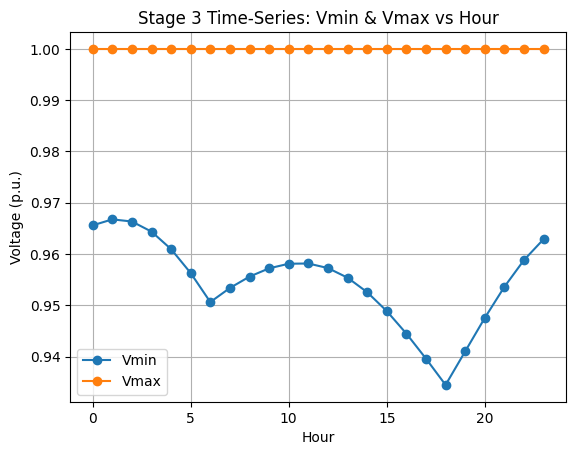

In [23]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["hour"], df["Vmin_pu"], marker="o", label="Vmin")
plt.plot(df["hour"], df["Vmax_pu"], marker="o", label="Vmax")
plt.xlabel("Hour")
plt.ylabel("Voltage (p.u.)")
plt.title("Stage 3 Time-Series: Vmin & Vmax vs Hour")
plt.grid(True)
plt.legend()
plt.show()


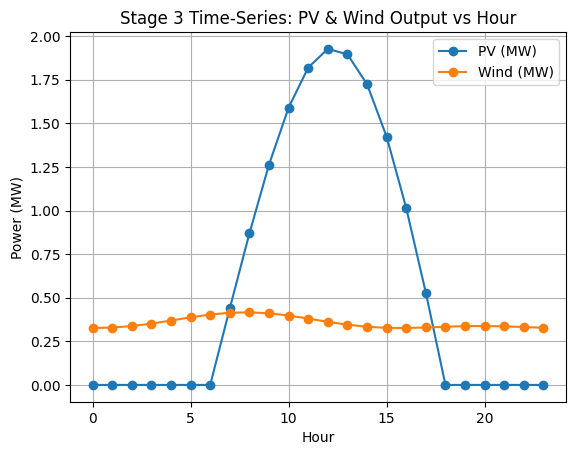

In [24]:
plt.figure()
plt.plot(df["hour"], df["P_pv_MW"], marker="o", label="PV (MW)")
plt.plot(df["hour"], df["P_wind_MW"], marker="o", label="Wind (MW)")
plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title("Stage 3 Time-Series: PV & Wind Output vs Hour")
plt.grid(True)
plt.legend()
plt.show()


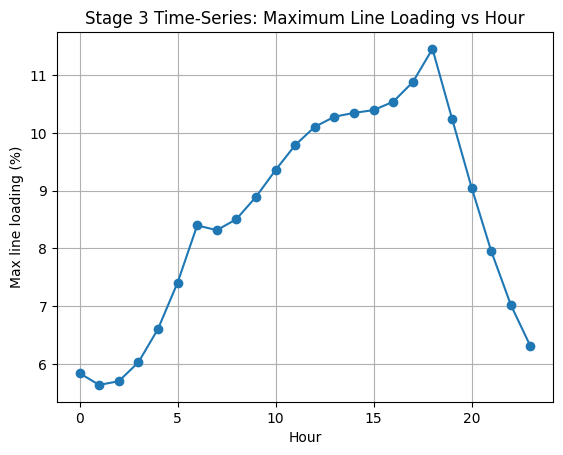

In [25]:
plt.figure()
plt.plot(df["hour"], df["max_line_loading_pct"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Max line loading (%)")
plt.title("Stage 3 Time-Series: Maximum Line Loading vs Hour")
plt.grid(True)
plt.show()


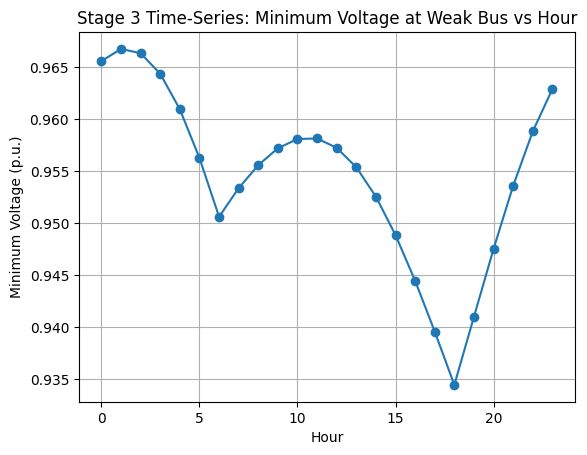

    hour min_voltage_bus   Vmin_pu
0      0   BESS_LV_Bus33  0.965595
1      1   BESS_LV_Bus33  0.966761
2      2   BESS_LV_Bus33  0.966343
3      3   BESS_LV_Bus33  0.964369
4      4   BESS_LV_Bus33  0.960951
5      5   BESS_LV_Bus33  0.956282
6      6   BESS_LV_Bus33  0.950634
7      7   BESS_LV_Bus33  0.953386
8      8   BESS_LV_Bus33  0.955599
9      9   BESS_LV_Bus33  0.957214
10    10   BESS_LV_Bus33  0.958109
11    11           Bus33  0.958155
12    12   BESS_LV_Bus33  0.957260
13    13           Bus33  0.955387
14    14   BESS_LV_Bus33  0.952561
15    15   BESS_LV_Bus33  0.948874
16    16   BESS_LV_Bus33  0.944483
17    17           Bus33  0.939603
18    18   BESS_LV_Bus33  0.934475
19    19   BESS_LV_Bus33  0.941014
20    20   BESS_LV_Bus33  0.947541
21    21   BESS_LV_Bus33  0.953605
22    22   BESS_LV_Bus33  0.958829
23    23   BESS_LV_Bus33  0.962903


In [26]:
plt.figure()
plt.plot(dfv["hour"], dfv["Vmin_pu"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Minimum Voltage (p.u.)")
plt.title("Stage 3 Time-Series: Minimum Voltage at Weak Bus vs Hour")
plt.grid(True)
plt.show()

print(dfv[["hour","min_voltage_bus","Vmin_pu"]])


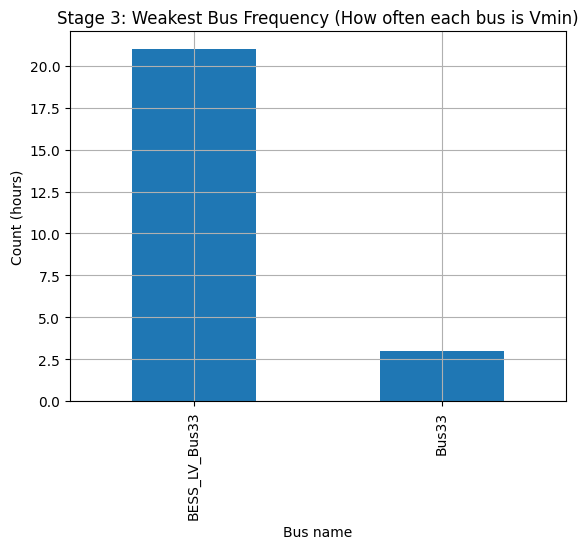

min_voltage_bus
BESS_LV_Bus33    21
Bus33             3
Name: count, dtype: int64


In [27]:
counts = dfv["min_voltage_bus"].value_counts()

plt.figure()
counts.plot(kind="bar")
plt.xlabel("Bus name")
plt.ylabel("Count (hours)")
plt.title("Stage 3: Weakest Bus Frequency (How often each bus is Vmin)")
plt.grid(True)
plt.show()

print(counts)


    hour min_voltage_bus   Vmin_pu
11    11           Bus33  0.958155
13    13           Bus33  0.955387
17    17           Bus33  0.939603


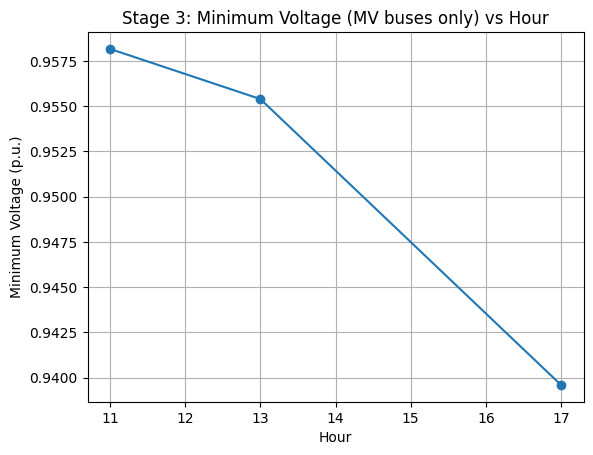

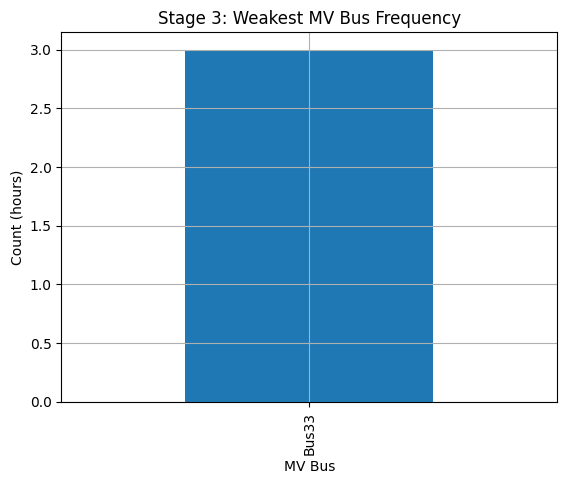

min_voltage_bus
Bus33    3
Name: count, dtype: int64


In [28]:
mv_only = dfv[dfv["min_voltage_bus"].str.match(r"^Bus\d+$", na=False)]
print(mv_only)

plt.figure()
plt.plot(mv_only["hour"], mv_only["Vmin_pu"], marker="o")
plt.xlabel("Hour")
plt.ylabel("Minimum Voltage (p.u.)")
plt.title("Stage 3: Minimum Voltage (MV buses only) vs Hour")
plt.grid(True)
plt.show()

counts_mv = mv_only["min_voltage_bus"].value_counts()
plt.figure()
counts_mv.plot(kind="bar")
plt.xlabel("MV Bus")
plt.ylabel("Count (hours)")
plt.title("Stage 3: Weakest MV Bus Frequency")
plt.grid(True)
plt.show()

print(counts_mv)


In [15]:
pip install pandas matplotlib

Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.1 MB 2.4 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.1 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.1 MB 4.0 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.1 MB 4.4 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.1 MB 5.4 MB/s eta 0:00:01
   

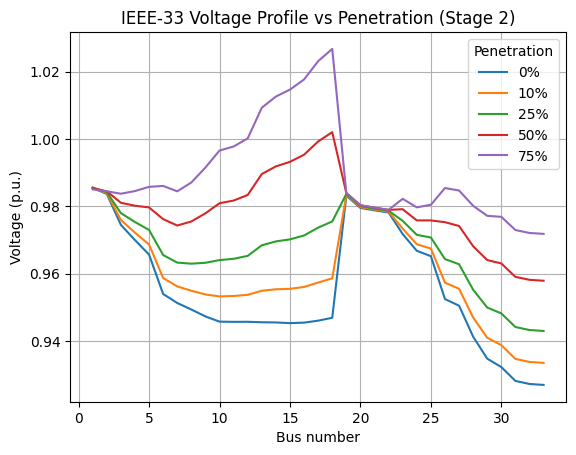

Saved: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_voltage_profiles.png


In [16]:
import os, glob, re
import pandas as pd
import matplotlib.pyplot as plt

# 1) Folder where you saved Stage 2 exports
EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data\stage2_exports"

# 2) Find all voltage CSVs
files = sorted(glob.glob(os.path.join(EXPORT_DIR, "stage2_voltages_*.csv")))
if not files:
    raise FileNotFoundError(f"No voltage files found in: {EXPORT_DIR}")

def bus_number(bus_name: str) -> int:
    m = re.search(r"(\d+)$", str(bus_name))
    return int(m.group(1)) if m else 9999

def penetration_from_filename(path: str) -> int:
    # expects stage2_voltages_0.csv, stage2_voltages_10.csv, ...
    base = os.path.basename(path)
    m = re.search(r"stage2_voltages_(\d+)\.csv$", base)
    return int(m.group(1)) if m else -1

# 3) Read and store each case
cases = []
for f in files:
    pen = penetration_from_filename(f)
    df = pd.read_csv(f)
    df["bus_no"] = df["bus"].apply(bus_number)
    df = df.sort_values("bus_no")
    cases.append((pen, df))

cases = sorted(cases, key=lambda x: x[0])  # sort by penetration %

# 4) Plot: Voltage profile per penetration
plt.figure()
for pen, df in cases:
    plt.plot(df["bus_no"], df["U_pu"], label=f"{pen}%")
plt.xlabel("Bus number")
plt.ylabel("Voltage (p.u.)")
plt.title("IEEE-33 Voltage Profile vs Penetration (Stage 2)")
plt.grid(True)
plt.legend(title="Penetration")

# 5) Save figure
out_png = os.path.join(EXPORT_DIR, "stage2_voltage_profiles.png")
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_png)


   penetration_pct weak_bus   Vmin_pu   Vmax_pu
0                0    Bus33  0.926993  0.985488
1               10    Bus33  0.933538  0.985554
2               25    Bus33  0.943020  0.985579
3               50    Bus33  0.957931  1.002053
4               75    Bus33  0.971848  1.026769
Saved: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_weak_bus_table.csv


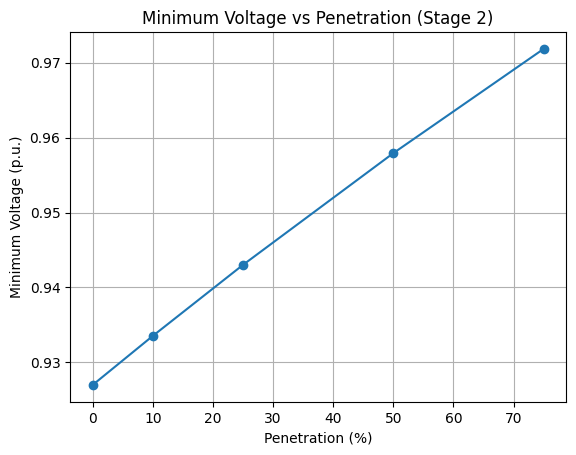

Saved: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_vmin_vs_penetration.png


In [17]:
import os
import pandas as pd
import matplotlib.pyplot as plt

EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data\stage2_exports"
files = sorted([f for f in os.listdir(EXPORT_DIR) if f.startswith("stage2_voltages_") and f.endswith(".csv")])

def pen_from_name(name: str) -> int:
    return int(name.replace("stage2_voltages_", "").replace(".csv", ""))

rows = []
for name in files:
    pen = pen_from_name(name)
    df = pd.read_csv(os.path.join(EXPORT_DIR, name))
    # weak bus = min voltage
    idx = df["U_pu"].idxmin()
    weak_bus = df.loc[idx, "bus"]
    vmin = float(df.loc[idx, "U_pu"])
    vmax = float(df["U_pu"].max())
    rows.append({"penetration_pct": pen, "weak_bus": weak_bus, "Vmin_pu": vmin, "Vmax_pu": vmax})

weak_df = pd.DataFrame(rows).sort_values("penetration_pct").reset_index(drop=True)
print(weak_df)

# Save table for your report
out_csv = os.path.join(EXPORT_DIR, "stage2_weak_bus_table.csv")
weak_df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Plot Vmin vs penetration
plt.figure()
plt.plot(weak_df["penetration_pct"], weak_df["Vmin_pu"], marker="o")
plt.xlabel("Penetration (%)")
plt.ylabel("Minimum Voltage (p.u.)")
plt.title("Minimum Voltage vs Penetration (Stage 2)")
plt.grid(True)

out_png = os.path.join(EXPORT_DIR, "stage2_vmin_vs_penetration.png")
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", out_png)


In [18]:
import math
import os
import csv

EXPORT_DIR = r"C:\Users\ADMIN\Desktop\data\stage2_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

def get_first_attr(obj, candidates):
    """Try multiple PF attribute names; return (value, attr_name) or (None, None)."""
    for a in candidates:
        try:
            v = obj.GetAttribute(a)
            if v is None:
                continue
            # accept numeric values
            if isinstance(v, (int, float)) and not (isinstance(v, float) and math.isnan(v)):
                return float(v), a
        except Exception:
            pass
    return None, None

def line_loading_pct(line):
    # Commonly used in PF scripts / examples
    v, a = get_first_attr(line, ["c:loading", "m:loading", "c:Loading", "m:Loading"])
    return v

# 1) Total network losses (MW) from the GRID (ElmNet grouping results)
# PF documentation lists total losses variables (LossP, LossQ, etc.) for grouping elements. :contentReference[oaicite:0]{index=0}
loss_MW, loss_attr = get_first_attr(grid, ["m:LossP", "LossP", "c:LossP"])

# 2) Max line loading (%)
lines = app.GetCalcRelevantObjects("*.ElmLne")
max_load = None
max_line = None
for ln in lines:
    ld = line_loading_pct(ln)
    if ld is None:
        continue
    if (max_load is None) or (ld > max_load):
        max_load = ld
        max_line = ln.loc_name

# 3) Append one row to a summary CSV (good for your thesis tables)
summary_file = os.path.join(EXPORT_DIR, "stage2_summary_extra.csv")
file_exists = os.path.exists(summary_file)

with open(summary_file, "a", newline="") as f:
    w = csv.writer(f)
    if not file_exists:
        w.writerow([
            "penetration_pct",
            "total_losses_MW", "loss_attr_used",
            "max_line_loading_pct", "max_loaded_line"
        ])
    w.writerow([
        pen_pct,
        loss_MW, loss_attr,
        max_load, max_line
    ])

print(f"[Export] pen={pen_pct}% | losses={loss_MW} MW ({loss_attr}) | max_loading={max_load}% ({max_line})")
print("Saved:", summary_file)


[Export] pen=75% | losses=0.14235331108049365 MW (m:LossP) | max_loading=11.126917468225454% (L_2_3)
Saved: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary_extra.csv


In [1]:
import pandas as pd

path = r"C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary_extra.csv"
df = pd.read_csv(path)
df = df.sort_values("penetration_pct")
print(df)


   penetration_pct  total_losses_MW loss_attr_used  max_line_loading_pct  \
0               75         0.142353        m:LossP             11.126917   

  max_loaded_line  
0           L_2_3  


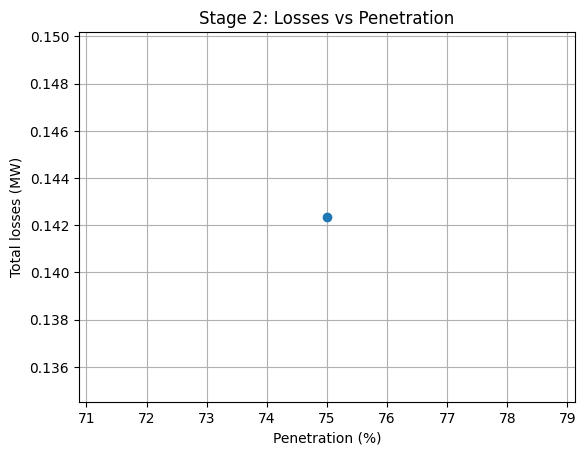

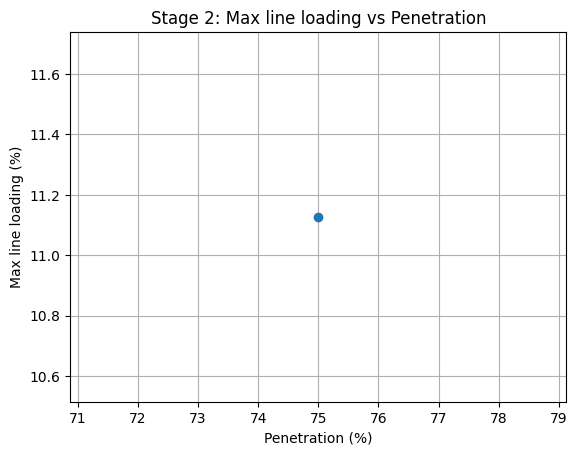

In [2]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["penetration_pct"], df["total_losses_MW"], marker="o")
plt.xlabel("Penetration (%)")
plt.ylabel("Total losses (MW)")
plt.title("Stage 2: Losses vs Penetration")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(df["penetration_pct"], df["max_line_loading_pct"], marker="o")
plt.xlabel("Penetration (%)")
plt.ylabel("Max line loading (%)")
plt.title("Stage 2: Max line loading vs Penetration")
plt.grid(True)
plt.show()


In [3]:
import pandas as pd

base = pd.read_csv(r"C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary.csv")
extra = pd.read_csv(r"C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary_extra.csv")

merged = base.merge(extra, left_on="penetration_%", right_on="penetration_pct", how="left")
merged = merged.drop(columns=["penetration_pct"])
out = r"C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary_merged.csv"
merged.to_csv(out, index=False)

print("Saved:", out)
print(merged)


Saved: C:\Users\ADMIN\Desktop\data\stage2_exports\stage2_summary_merged.csv
   penetration_%  DER_target_MW   Vmin_pu   Vmax_pu  max_line_loading_%  \
0              0        0.00000  0.926993  0.985488           13.121852   
1             10        0.37150  0.933538  0.985554           12.016681   
2             25        0.92875  0.943020  0.985579           10.763495   
3             50        1.85750  0.957931  1.002053           10.051812   
4             75        2.78625  0.971848  1.026769           11.126917   

   losses_MW                                       voltages_csv  \
0   0.098959  C:\Users\ADMIN\Desktop\data\stage2_exports\sta...   
1   0.087500  C:\Users\ADMIN\Desktop\data\stage2_exports\sta...   
2   0.081034  C:\Users\ADMIN\Desktop\data\stage2_exports\sta...   
3   0.096708  C:\Users\ADMIN\Desktop\data\stage2_exports\sta...   
4   0.142353  C:\Users\ADMIN\Desktop\data\stage2_exports\sta...   

   total_losses_MW loss_attr_used  max_line_loading_pct max_loaded_lin

In [10]:
def show_nominals():
    for t in [bus1, bus2]:
        vals = {}
        for a in ["uknom", "Unom", "u_nom", "ucn", "uknom_a"]:
            try:
                vals[a] = t.GetAttribute(a)
            except Exception:
                pass
        print(t.loc_name, vals)

print("Terminal nominal voltage attributes:")
show_nominals()

print("\nLine nominal voltage attributes:")
for a in ["uknom", "Unom", "u_nom"]:
    try:
        print(a, line1.GetAttribute(a))
    except Exception:
        pass


Terminal nominal voltage attributes:
Bus1 {'uknom': 12.65999984741211}
Bus2 {'uknom': 12.65999984741211}

Line nominal voltage attributes:
Unom 12.65999984741211


In [11]:
# --- 1) Show current voltages (before) ---
print("Before fix:")
print("Bus1 uknom:", bus1.GetAttribute("uknom"))
print("Bus2 uknom:", bus2.GetAttribute("uknom"))
print("Line1 Unom :", line1.GetAttribute("Unom"))

# --- 2) Try setting the line nominal voltage directly ---
try:
    line1.SetAttribute("Unom", 12.66)
    print("Set line1.Unom = 12.66 kV ✅")
except Exception as e:
    print("Could NOT set line1.Unom:", e)

# --- 3) Also try setting a line nominal voltage field if your model uses it ---
for a in ["uknom", "uline"]:
    try:
        line1.SetAttribute(a, 12.66)
        print(f"Set line1.{a} = 12.66 kV ✅")
    except Exception:
        pass

# --- 4) If the line takes nominal voltage from the TYPE, set it there too ---
for a in ["Unom", "uknom", "uline"]:
    try:
        typ_line.SetAttribute(a, 12.66)
        print(f"Set typ_line.{a} = 12.66 kV ✅")
    except Exception:
        pass

# --- 5) Set Slack voltage setpoint (optional but good) ---
for a in ["usetp", "u0pu", "u0"]:
    try:
        xnet.SetAttribute(a, 1.0)  # 1.0 pu
        print(f"Set slack {a} = 1.0 pu ✅")
        break
    except Exception:
        pass

# --- 6) Check again (after) ---
print("\nAfter fix:")
try:
    print("Line1 Unom :", line1.GetAttribute("Unom"))
except Exception as e:
    print("Could not read Line1 Unom:", e)

# --- 7) Run load flow again ---
ret = ldf.Execute()
print("\nLoad flow return:", ret, "(0 = OK)")


Before fix:
Bus1 uknom: 12.65999984741211
Bus2 uknom: 12.65999984741211
Line1 Unom : 12.65999984741211
Could NOT set line1.Unom: setting attribute 'Unom' of 'DataObject' object failed
Set typ_line.uline = 12.66 kV ✅
Set slack usetp = 1.0 pu ✅

After fix:
Line1 Unom : 12.65999984741211

Load flow return: 0 (0 = OK)


In [12]:
import csv
import powerfactory as pf

# ---------- Helpers ----------
def pf_list(x):
    """Normalize PowerFactory return types into a plain Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def read_csv_dicts(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

# ---------- Connection ----------
# In Jupyter: reuse existing app if already created earlier in this kernel
try:
    app
    print("Reusing existing 'app'")
except NameError:
    # If running INSIDE PF ComPython, use pf.GetApplication()
    # If running outside PF (engine mode), use pf.GetApplicationExt("ADMIN")
    app = pf.GetApplicationExt("ADMIN")
    if app is None:
        raise RuntimeError("Could not start PowerFactory engine. Close PF GUI and try again.")
    print("Created new 'app'")

# ---------- USER SETTINGS ----------
PROJECT_NAME = "IEEE33_RE"
GRID_NAME = "Grid"
BASE_KV = 12.66

LINES_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_lines.csv"
LOADS_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_loads.csv"

EXPORT_VOLTAGES_CSV = r"C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv"

# IEEE-33 normally-open tie lines (from your CSV tail)
TIE_LINES = {(21,8), (9,15), (12,22), (18,33), (25,29)}
# --------------------------------

# ---------- Activate project + study case ----------
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found. Create one in PowerFactory first.")
cases[0].Activate()
print("Active Study Case:", cases[0].loc_name)

# Load flow command
ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case. Add a Load Flow command (ComLdf) to the Study Case.")

# ---------- Get Grid ----------
netdat = app.GetProjectFolder("netdat")
grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found. Found grids: {[g.loc_name for g in grids]}")
print("Using grid:", grid.loc_name)

# ---------- Read CSVs ----------
line_rows = read_csv_dicts(LINES_CSV)
load_rows = read_csv_dicts(LOADS_CSV)

print("Lines in CSV:", len(line_rows))
print("Loads in CSV:", len(load_rows))

# Detect if loads are kW/kVAr (typical IEEE-33)
p_max = max(float(r["P_MW"]) for r in load_rows)
scale = 0.001 if p_max > 10 else 1.0
print("Load scaling:", ("kW->MW (÷1000)" if scale == 0.001 else "already MW"))

# ---------- Create Buses Bus1..Bus33 ----------
buses = {}
for i in range(1, 34):
    name = f"Bus{i}"
    t = get_or_create(grid, "ElmTerm", name)
    try:
        t.SetAttribute("uknom", BASE_KV)  # nominal kV
    except Exception:
        pass
    buses[i] = t

print("Created/verified buses:", len(buses))

# ---------- Create Slack at Bus1 ----------
xnet = get_or_create(grid, "ElmXnet", "Slack")
cub_slack = get_or_create(buses[1], "StaCubic", "Cub_Slack")
cub_slack.obj_id = xnet

# Slack setpoint (1.0 pu)
try:
    xnet.SetAttribute("usetp", 1.0)
except Exception:
    pass

print("Slack connected at Bus1")

# ---------- Equipment type library ----------
equip = app.GetProjectFolder("equip")
if equip is None:
    raise RuntimeError("Equipment type library folder 'equip' not found.")

# ---------- Create Lines ----------
# We create one line TYPE per branch so each branch gets its own R/X.
# We set typ_line.uline to avoid the “Nominal voltage too low” error you hit earlier.
for r in line_rows:
    fb = int(float(r["from_bus"]))
    tb = int(float(r["to_bus"]))
    R  = float(r["R"])
    X  = float(r["X"])
    Lkm = float(r.get("length_km", 1.0))

    # Name
    line_name = f"L_{fb}_{tb}"
    type_name = f"Typ_{fb}_{tb}"

    # Line type
    typ = pf_list(equip.GetContents(f"{type_name}.TypLne", 1))
    typ = typ[0] if typ else equip.CreateObject("TypLne", type_name)
    if typ is None:
        raise RuntimeError(f"Could not create/find line type {type_name}")

    # Set nominal voltage for the type (this is the key!)
    try:
        typ.SetAttribute("uline", BASE_KV)
    except Exception:
        pass

    # Put impedance in type as ohm/km and set line length to 1 km (or use your length_km if you trust it)
    # If your R/X are TOTAL per branch, use dline=1.0 and rline=R, xline=X (what we do here).
    try:
        typ.SetAttribute("rline", R)
        typ.SetAttribute("xline", X)
    except Exception:
        pass

    # Optional zero-sequence (not needed for load flow; helps later for fault studies)
    try:
        typ.SetAttribute("rline0", 3*R)
        typ.SetAttribute("xline0", 3*X)
    except Exception:
        pass

    # Line element
    line = get_or_create(grid, "ElmLne", line_name)
    line.typ_id = typ
    try:
        line.SetAttribute("dline", 1.0)  # keep 1.0 so R/X act as total branch impedance
    except Exception:
        pass

    # Normally-open tie lines -> out of service (open)
    if (fb, tb) in TIE_LINES or (tb, fb) in TIE_LINES:
        try:
            line.SetAttribute("outserv", 1)
        except Exception:
            pass
    else:
        try:
            line.SetAttribute("outserv", 0)
        except Exception:
            pass

    # Connect line to both buses via cubicles
    cubA = get_or_create(buses[fb], "StaCubic", f"Cub_{line_name}_A")
    cubB = get_or_create(buses[tb], "StaCubic", f"Cub_{line_name}_B")
    cubA.obj_id = line
    cubB.obj_id = line

print("Created/connected all lines (tie lines set out of service)")

# ---------- Create Loads ----------
for r in load_rows:
    bus = int(float(r["bus"]))
    Praw = float(r["P_MW"])
    Qraw = float(r["Q_MVAr"])

    Pmw = Praw * scale
    Qmvar = Qraw * scale

    load_name = f"Load_Bus{bus}"
    lod = get_or_create(grid, "ElmLod", load_name)
    try:
        lod.SetAttribute("plini", Pmw)
        lod.SetAttribute("qlini", Qmvar)
    except Exception:
        pass

    cub = get_or_create(buses[bus], "StaCubic", f"Cub_{load_name}")
    cub.obj_id = lod

print("Created/connected all loads")

# ---------- Run Load Flow ----------
ret = ldf.Execute()
print("Load flow return:", ret, "(0=OK)")

if ret != 0:
    ow = app.GetOutputWindow()
    try:
        ow.Flush()
        print("Output window:\n", ow.GetContent())
    except Exception:
        pass
    raise RuntimeError("Load flow did not converge. See output above.")

# ---------- Export voltages ----------
terms = app.GetCalcRelevantObjects("*.ElmTerm")
rows = []
for t in terms:
    try:
        u = t.GetAttribute("m:u")  # pu
        rows.append((t.loc_name, u))
    except Exception:
        pass

rows.sort(key=lambda x: int(x[0].replace("Bus","")) if x[0].startswith("Bus") else 999)

with open(EXPORT_VOLTAGES_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["bus", "U_pu"])
    w.writerows(rows)

u_min = min(u for _, u in rows)
u_max = max(u for _, u in rows)
print(f"Voltage range: min={u_min:.4f} pu, max={u_max:.4f} pu")
print("Saved voltages to:", EXPORT_VOLTAGES_CSV)


Reusing existing 'app'
ActivateProject return: 0
Active Study Case: Study Case
Using grid: Grid
Lines in CSV: 37
Loads in CSV: 32
Load scaling: kW->MW (÷1000)
Created/verified buses: 33
Slack connected at Bus1
Created/connected all lines (tie lines set out of service)
Created/connected all loads
Load flow return: 0 (0=OK)
Voltage range: min=0.9137 pu, max=1.0000 pu
Saved voltages to: C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv


In [13]:
import csv
import powerfactory as pf

# ---------- Helpers ----------
def pf_list(x):
    """Normalize PowerFactory return types into a plain Python list."""
    if x is None:
        return []
    if isinstance(x, list):
        if len(x) > 0 and isinstance(x[0], list):
            out = []
            for sub in x:
                out.extend(sub)
            return out
        return x
    if isinstance(x, tuple):
        out = []
        for item in x:
            out.extend(pf_list(item))
        return out
    return [x]

def get_or_create(parent, cls_name, obj_name):
    found = pf_list(parent.GetContents(f"{obj_name}.{cls_name}", 0))
    if found:
        return found[0]
    obj = parent.CreateObject(cls_name, obj_name)
    if obj is None:
        raise RuntimeError(f"CreateObject failed for {obj_name}.{cls_name}")
    return obj

def read_csv_dicts(path):
    with open(path, newline="") as f:
        return list(csv.DictReader(f))

def try_print_output(app, title="PF Output"):
    try:
        ow = app.GetOutputWindow()
        ow.Flush()
        print("\n" + "="*80)
        print(title)
        print("="*80)
        print(ow.GetContent())
    except Exception:
        pass


# ---------- Connection ----------
try:
    app
    print("Reusing existing 'app'")
except NameError:
    app = pf.GetApplicationExt("ADMIN")  # engine mode
    if app is None:
        raise RuntimeError("Could not start PowerFactory engine. Close PF GUI and try again.")
    print("Created new 'app'")

# --- NEW: show PowerFactory window (engine/unattended mode) ---
try:
    app.Show()
    print("Called app.Show() (PowerFactory window should appear).")
except Exception as e:
    print("Could not show GUI via app.Show():", e)

# ---------- USER SETTINGS ----------
PROJECT_NAME = "IEEE33_RE"
GRID_NAME = "Grid"
BASE_KV = 12.66

LINES_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_lines.csv"
LOADS_CSV = r"C:\Users\ADMIN\Desktop\data\ieee33_loads.csv"

EXPORT_VOLTAGES_CSV = r"C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv"

# IEEE-33 normally-open tie lines (normally open)
TIE_LINES = {(21,8), (9,15), (12,22), (18,33), (25,29)}

# ---------- Activate project + study case ----------
rc = app.ActivateProject(PROJECT_NAME)
print("ActivateProject return:", rc)
if rc != 0:
    raise RuntimeError(f"Could not activate project {PROJECT_NAME}")

study = app.GetProjectFolder("study")
cases = pf_list(study.GetContents("*.IntCase"))
if not cases:
    raise RuntimeError("No Study Case found. Create one in PowerFactory first.")
cases[0].Activate()
print("Active Study Case:", cases[0].loc_name)

# Load flow command
ldf = app.GetFromStudyCase("ComLdf")
if ldf is None:
    raise RuntimeError("ComLdf not found in Study Case. Add a Load Flow command (ComLdf) to the Study Case.")

# ---------- Get Grid ----------
netdat = app.GetProjectFolder("netdat")
grids = pf_list(netdat.GetContents("*.ElmNet", 1))
grid = next((g for g in grids if g.loc_name == GRID_NAME), None)
if grid is None:
    raise RuntimeError(f"Grid '{GRID_NAME}' not found. Found grids: {[g.loc_name for g in grids]}")
print("Using grid:", grid.loc_name)

# ---------- Read CSVs ----------
line_rows = read_csv_dicts(LINES_CSV)
load_rows = read_csv_dicts(LOADS_CSV)

print("Lines in CSV:", len(line_rows))
print("Loads in CSV:", len(load_rows))

# Detect if loads are kW/kVAr (typical IEEE-33)
p_max = max(float(r["P_MW"]) for r in load_rows)
scale = 0.001 if p_max > 10 else 1.0
print("Load scaling:", ("kW->MW (÷1000)" if scale == 0.001 else "already MW"))

# ---------- Create Buses Bus1..Bus33 ----------
buses = {}
for i in range(1, 34):
    name = f"Bus{i}"
    t = get_or_create(grid, "ElmTerm", name)
    try:
        t.SetAttribute("uknom", BASE_KV)
    except Exception:
        pass
    buses[i] = t

print("Created/verified buses:", len(buses))

# ---------- Create Slack at Bus1 ----------
xnet = get_or_create(grid, "ElmXnet", "Slack")
cub_slack = get_or_create(buses[1], "StaCubic", "Cub_Slack")
cub_slack.obj_id = xnet
try:
    xnet.SetAttribute("usetp", 1.0)
except Exception:
    pass
print("Slack connected at Bus1")

# ---------- Equipment type library ----------
equip = app.GetProjectFolder("equip")
if equip is None:
    raise RuntimeError("Equipment type library folder 'equip' not found.")

# ---------- Create Lines ----------
for r in line_rows:
    fb = int(float(r["from_bus"]))
    tb = int(float(r["to_bus"]))
    R  = float(r["R"])
    X  = float(r["X"])

    line_name = f"L_{fb}_{tb}"
    type_name = f"Typ_{fb}_{tb}"

    typ = pf_list(equip.GetContents(f"{type_name}.TypLne", 1))
    typ = typ[0] if typ else equip.CreateObject("TypLne", type_name)
    if typ is None:
        raise RuntimeError(f"Could not create/find line type {type_name}")

    # critical: nominal voltage for type (prevents "Nominal voltage too low")
    try:
        typ.SetAttribute("uline", BASE_KV)
    except Exception:
        pass

    try:
        typ.SetAttribute("rline", R)
        typ.SetAttribute("xline", X)
    except Exception:
        pass

    # optional zero-sequence
    try:
        typ.SetAttribute("rline0", 3*R)
        typ.SetAttribute("xline0", 3*X)
    except Exception:
        pass

    line = get_or_create(grid, "ElmLne", line_name)
    line.typ_id = typ
    try:
        line.SetAttribute("dline", 1.0)
    except Exception:
        pass

    # Normally-open tie lines -> open/out of service
    if (fb, tb) in TIE_LINES or (tb, fb) in TIE_LINES:
        try:
            line.SetAttribute("outserv", 1)
        except Exception:
            pass
    else:
        try:
            line.SetAttribute("outserv", 0)
        except Exception:
            pass

    cubA = get_or_create(buses[fb], "StaCubic", f"Cub_{line_name}_A")
    cubB = get_or_create(buses[tb], "StaCubic", f"Cub_{line_name}_B")
    cubA.obj_id = line
    cubB.obj_id = line

print("Created/connected all lines (tie lines set out of service)")

# ---------- Create Loads ----------
for r in load_rows:
    bus = int(float(r["bus"]))
    Praw = float(r["P_MW"])
    Qraw = float(r["Q_MVAr"])

    Pmw = Praw * scale
    Qmvar = Qraw * scale

    load_name = f"Load_Bus{bus}"
    lod = get_or_create(grid, "ElmLod", load_name)
    try:
        lod.SetAttribute("plini", Pmw)
        lod.SetAttribute("qlini", Qmvar)
    except Exception:
        pass

    cub = get_or_create(buses[bus], "StaCubic", f"Cub_{load_name}")
    cub.obj_id = lod

print("Created/connected all loads")

# ---------- Run Load Flow ----------
ret = ldf.Execute()
print("Load flow return:", ret, "(0=OK)")

if ret != 0:
    try_print_output(app, "Output window after failed Load Flow")
    raise RuntimeError("Load flow did not converge. See output above.")

# ---------- Export voltages ----------
terms = app.GetCalcRelevantObjects("*.ElmTerm")
rows = []
for t in terms:
    try:
        u = t.GetAttribute("m:u")
        rows.append((t.loc_name, u))
    except Exception:
        pass

rows.sort(key=lambda x: int(x[0].replace("Bus","")) if x[0].startswith("Bus") else 999)

with open(EXPORT_VOLTAGES_CSV, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["bus", "U_pu"])
    w.writerows(rows)

u_min = min(u for _, u in rows)
u_max = max(u for _, u in rows)
print(f"Voltage range: min={u_min:.4f} pu, max={u_max:.4f} pu")
print("Saved voltages to:", EXPORT_VOLTAGES_CSV)

# =====================================================================
# NEW: Auto-insert + Auto-layout into Single Line Diagram (no drag/drop)
# =====================================================================
print("\nAttempting diagram auto-insert + layout...")

desktop = None
try:
    desktop = app.GetDesktop()
except Exception:
    desktop = None

if desktop is None:
    print("No Desktop available (engine session is headless).")
    print("Result: model is created, but diagram cannot be displayed from Jupyter in this session.")
    print("Open PF GUI normally -> Grid -> New Diagram (one time) then you can run ComSgllayout inside PF.")
else:
    try:
        desktop.Unfreeze()
    except Exception:
        pass

    # This command inserts network elements into the active single-line diagram and arranges them
    comlayout = app.GetFromStudyCase("ComSgllayout")
    if comlayout is None:
        print("ComSgllayout not found in Study Case. Add it once in the Study Case, then rerun.")
    else:
        try:
            comlayout.iAction = 1
            comlayout.insertionMode = 1
        except Exception:
            pass

        rc_layout = comlayout.Execute()
        print("ComSgllayout return:", rc_layout)

        try_print_output(app, "Output window after ComSgllayout")
        print("If a diagram page exists, it should now be populated and arranged.")


Reusing existing 'app'
Called app.Show() (PowerFactory window should appear).
ActivateProject return: 0
Active Study Case: Study Case
Using grid: Grid
Lines in CSV: 37
Loads in CSV: 32
Load scaling: kW->MW (÷1000)
Created/verified buses: 33
Slack connected at Bus1
Created/connected all lines (tie lines set out of service)
Created/connected all loads
Load flow return: 0 (0=OK)
Voltage range: min=0.9137 pu, max=1.0000 pu
Saved voltages to: C:\Users\ADMIN\Desktop\data\pf_ieee33_voltages.csv

Attempting diagram auto-insert + layout...
No Desktop available (engine session is headless).
Result: model is created, but diagram cannot be displayed from Jupyter in this session.
Open PF GUI normally -> Grid -> New Diagram (one time) then you can run ComSgllayout inside PF.


In [ ]:
# Make sure PF window is visible
app.Show()

# Auto-insert / auto-layout elements into the currently open diagram
graphic = app.GetDesktop()
graphic.Unfreeze()

comlayout = app.GetFromStudyCase("ComSgllayout")
comlayout.iAction = 1          # action mode (auto insert)
comlayout.insertionMode = 1    # insert into current diagram
comlayout.Execute()


In [ ]:
try:
    app.Hide()   # optional
except Exception:
    pass

try:
    app.Quit()
except Exception as e:
    print("Quit error:", e)


In [19]:
pip install scipy


  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl (41.3 MB)


In [9]:
import os

BASE_DIR = r"C:\Users\ADMIN\Desktop\data"

# If BASE_DIR already contains stage2_exports, use it. Otherwise use BASE_DIR\data
if os.path.exists(os.path.join(BASE_DIR, "stage2_exports")):
    DATA_DIR = BASE_DIR
else:
    DATA_DIR = os.path.join(BASE_DIR, "data")

print("DATA_DIR:", DATA_DIR)
print("Exists:", os.path.exists(DATA_DIR))
print("Folders:", [x for x in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, x))])


DATA_DIR: C:\Users\ADMIN\Desktop\data
Exists: True
Folders: ['stage2_exports', 'stage3_exports', 'stage3_timeseries']


In [10]:
stage2_path = os.path.join(DATA_DIR, 'stage2_exports', 'stage2_summary_merged.csv')
df2 = pd.read_csv(stage2_path).sort_values('penetration_%')
df2[['penetration_%','Vmin_pu','Vmax_pu','losses_MW','max_line_loading_%']]

,penetration_%,Vmin_pu,Vmax_pu,losses_MW,max_line_loading_%
0,0,0.926993,0.985488,0.098959,13.121852
1,10,0.933538,0.985554,0.087500,12.016681
2,25,0.943020,0.985579,0.081034,10.763495
3,50,0.957931,1.002053,0.096708,10.051812
4,75,0.971848,1.026769,0.142353,11.126917


In [11]:
# Create Table II-friendly view (single metrics column like your manuscript style)
def metrics_string(row):
    return (f"Vmin/Vmax: {row['Vmin_pu']:.3f}/{row['Vmax_pu']:.3f}\n"
            f"Losses: {row['losses_MW']:.3f} MW\n"
            f"Max loading: {row['max_line_loading_%']:.2f}%")

table2 = pd.DataFrame({
    'Penetration (%)': df2['penetration_%'].astype(int),
    'Metrics (pu/MW/%)': df2.apply(metrics_string, axis=1)
})

table2


,Penetration (%),Metrics (pu/MW/%)
0,0,Vmin/Vmax: 0.927/0.985\nLosses: 0.099 MW\nMax ...
1,10,Vmin/Vmax: 0.934/0.986\nLosses: 0.088 MW\nMax ...
2,25,Vmin/Vmax: 0.943/0.986\nLosses: 0.081 MW\nMax ...
3,50,Vmin/Vmax: 0.958/1.002\nLosses: 0.097 MW\nMax ...
4,75,Vmin/Vmax: 0.972/1.027\nLosses: 0.142 MW\nMax ...


## Option 3: Open-source frequency disturbance tests (GFM/VSM + droop + deadband + optional FFR)
We model system frequency response using a reduced-order swing-equation style model often used in GFM/VSM studies.

- **H (s):** virtual inertia constant
- **R:** droop gain (Hz → pu power)
- **deadband (Hz):** no response inside ±deadband
- **FFR:** fast injection during the first few seconds (capped)

You can tune the disturbance size `dP_step` to match your PowerFactory RMS event (e.g., generation trip or load step).

In [12]:
@dataclass
class Params:
    f0: float = 50.0          # nominal frequency (Hz)
    H: float = 3.0            # virtual inertia (s)
    D: float = 1.0            # damping term (simplified)
    R: float = 0.05           # droop (Hz/pu equivalent)
    deadband: float = 0.02    # Hz
    Pmax: float = 0.20        # pu cap on support
    ffr_gain: float = 0.0     # pu/Hz extra fast response gain
    ffr_duration: float = 0.0 # seconds
    eps_settle: float = 0.02  # Hz band for settling time

def clamp(x, lo, hi):
    return np.minimum(np.maximum(x, lo), hi)

def support_power(df_hz, t, p: Params):
    # Deadband
    if abs(df_hz) <= p.deadband:
        base = 0.0
    else:
        base = -(df_hz) / p.R  # droop: df<0 => +P
    # Fast frequency response (optional)
    ffr = 0.0
    if p.ffr_duration > 0 and p.ffr_gain != 0 and t <= p.ffr_duration and abs(df_hz) > p.deadband:
        ffr = -(df_hz) * p.ffr_gain
    return float(clamp(base + ffr, -p.Pmax, p.Pmax))

def simulate_frequency(p: Params, t_end=20.0, dt=0.01, dP_step=-0.15):
    """Fixed-step simulation (no SciPy dependency). dP_step < 0 means power deficit."""
    n = int(np.floor(t_end/dt)) + 1
    t = np.linspace(0, t_end, n)
    f = np.empty(n)
    df = 0.0
    f[0] = p.f0 + df

    k = p.f0 / (2.0 * p.H)
    for i in range(1, n):
        ti = t[i-1]
        Ps = support_power(df, ti, p)
        ddf_dt = k * (dP_step + Ps - p.D * df)
        df = df + dt * ddf_dt
        f[i] = p.f0 + df

    rocof = float(np.max(np.abs(np.gradient(f, t))))  # Hz/s
    nadir = float(np.min(f))                          # Hz
    f_final = float(f[-1])

    within = np.abs(f - f_final) <= p.eps_settle
    settle = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settle = float(t[i])
            break
    return t, f, rocof, nadir, settle

def metrics_from_trace(t, f, f0=50.0, eps=0.02):
    t = np.asarray(t); f = np.asarray(f)
    rocof = float(np.max(np.abs(np.gradient(f, t))))
    nadir = float(np.min(f))
    f_final = float(f[-1])
    within = np.abs(f - f_final) <= eps
    settle = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settle = float(t[i]); break
    return rocof, nadir, settle

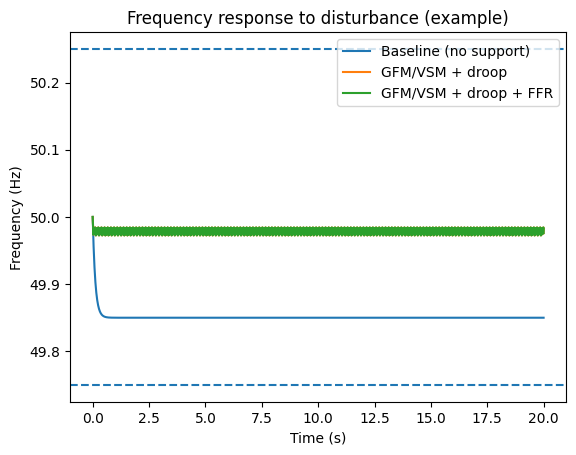

,Case,H (s),Droop R,Deadband (Hz),Pmax (pu),FFR gain,FFR duration (s),RoCoF (Hz/s),Nadir (Hz),Settling time (s)
0,Baseline (no support),3.0,0.05,0.02,0.0,0.0,0.0,1.2500,49.85000,0.24
1,GFM/VSM + droop,4.0,0.06,0.02,0.2,0.0,0.0,0.9375,49.97243,0.01
2,GFM/VSM + droop + FFR,4.0,0.06,0.02,0.2,0.6,2.0,0.9375,49.97243,0.01


In [13]:
# Disturbance: power deficit (pu). Example: -0.15 pu
dP_step = -0.15

cases = {
    "Baseline (no support)": Params(H=3.0, R=0.05, deadband=0.02, Pmax=0.0, ffr_gain=0.0, ffr_duration=0.0),
    "GFM/VSM + droop":       Params(H=4.0, R=0.06, deadband=0.02, Pmax=0.20, ffr_gain=0.0, ffr_duration=0.0),
    "GFM/VSM + droop + FFR": Params(H=4.0, R=0.06, deadband=0.02, Pmax=0.20, ffr_gain=0.6, ffr_duration=2.0),
}

rows=[]
plt.figure()
for name, p in cases.items():
    t, f, rocof, nadir, st = simulate_frequency(p, dP_step=dP_step, t_end=20.0, dt=0.01)
    plt.plot(t, f, label=name)
    rows.append([name, p.H, p.R, p.deadband, p.Pmax, p.ffr_gain, p.ffr_duration, rocof, nadir, st])
plt.axhline(49.75, linestyle='--')  # Nigeria normal control lower band
plt.axhline(50.25, linestyle='--')  # Nigeria normal control upper band
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.title('Frequency response to disturbance (example)')
plt.legend()
plt.show()

metrics_df = pd.DataFrame(rows, columns=[
    'Case','H (s)','Droop R','Deadband (Hz)','Pmax (pu)','FFR gain','FFR duration (s)','RoCoF (Hz/s)','Nadir (Hz)','Settling time (s)'
])
metrics_df

In [14]:
# Export the metrics table (paper-ready)
out_metrics = os.path.join(BASE_DIR, 'dynamic_metrics_cases.csv')
metrics_df.to_csv(out_metrics, index=False)
out_metrics

'C:\\Users\\ADMIN\\Desktop\\data\\dynamic_metrics_cases.csv'

### Sensitivity study: (H, droop, deadband)
This generates a sensitivity dataset you can cite and summarize in your results section.

In [15]:
Hs  = [2.0, 3.0, 4.0, 5.0]
Rs  = [0.04, 0.05, 0.06, 0.08]
DBs = [0.01, 0.02, 0.03, 0.05]

p_base = Params(H=4.0, R=0.06, deadband=0.02, Pmax=0.20, ffr_gain=0.6, ffr_duration=2.0)

sens=[]
for H in Hs:
    for R in Rs:
        for db in DBs:
            p = Params(**{**p_base.__dict__, 'H':H, 'R':R, 'deadband':db})
            t, f, rocof, nadir, st = simulate_frequency(p, dP_step=dP_step, t_end=20.0, dt=0.01)
            sens.append([H, R, db, rocof, nadir, st])

sens_df = pd.DataFrame(sens, columns=['H (s)','Droop R','Deadband (Hz)','RoCoF (Hz/s)','Nadir (Hz)','Settling time (s)'])
sens_df.head()

,H (s),Droop R,Deadband (Hz),RoCoF (Hz/s),Nadir (Hz),Settling time (s)
0,2.0,0.04,0.01,1.875,49.974260,0.00
1,2.0,0.04,0.02,1.875,49.963757,0.00
2,2.0,0.04,0.03,1.875,49.955185,19.98
3,2.0,0.04,0.05,1.875,49.937927,0.03
4,2.0,0.05,0.01,1.875,49.974260,0.00


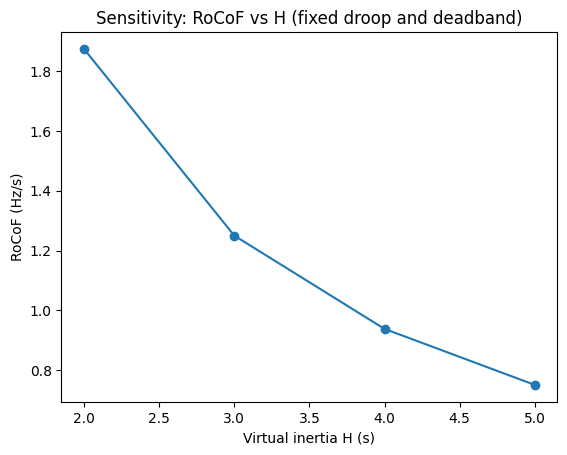

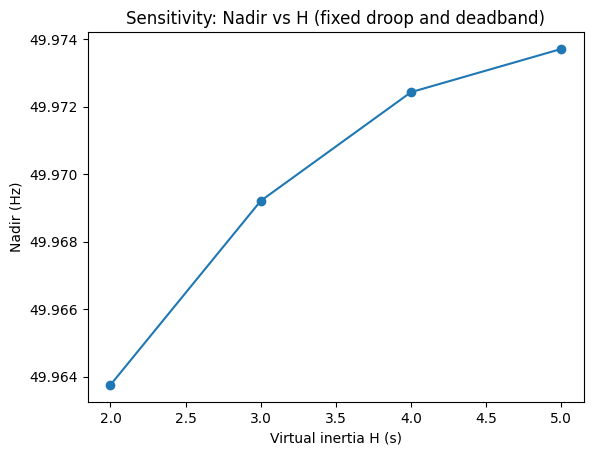

In [16]:
# Quick plots (example: RoCoF vs H at fixed R, deadband)
fixed_R = 0.06
fixed_db = 0.02
subset = sens_df[(sens_df['Droop R']==fixed_R) & (sens_df['Deadband (Hz)']==fixed_db)].sort_values('H (s)')

plt.figure()
plt.plot(subset['H (s)'], subset['RoCoF (Hz/s)'], marker='o')
plt.xlabel('Virtual inertia H (s)')
plt.ylabel('RoCoF (Hz/s)')
plt.title('Sensitivity: RoCoF vs H (fixed droop and deadband)')
plt.show()

plt.figure()
plt.plot(subset['H (s)'], subset['Nadir (Hz)'], marker='o')
plt.xlabel('Virtual inertia H (s)')
plt.ylabel('Nadir (Hz)')
plt.title('Sensitivity: Nadir vs H (fixed droop and deadband)')
plt.show()

In [17]:
# Export sensitivity dataset
out_sens = os.path.join(BASE_DIR, 'dynamic_metrics_sensitivity.csv')
sens_df.to_csv(out_sens, index=False)
out_sens

'C:\\Users\\ADMIN\\Desktop\\data\\dynamic_metrics_sensitivity.csv'

In [20]:
pip install OMPython pandas numpy matplotlib scipy



# Renewable Energy Integration Study – OpenModelica + Python (Q1-ready workflow)

This notebook **continues your existing PowerFactory steady-state dataset** and adds a **free/open-source frequency stability workflow** using:

- **OpenModelica + OpenIPSL** (to generate frequency time-series for disturbance cases)
- **Python** (to compute **RoCoF, nadir, settling time**, and build sensitivity tables/plots)

## What this notebook covers
1. Load your existing PowerFactory exports from `data.zip` (steady-state / time-series summary).
2. Rebuild **TABLE II** (steady-state metrics vs PV/Wind penetration).
3. Connect to **OpenModelica** through `OMPython`.
4. Load **OpenIPSL** and run **2–3 key disturbance cases** (load step / generation trip / line outage).
5. Extract frequency from OpenModelica CSV (`time`, `f_Hz` or `omega` → Hz).
6. Compute **RoCoF, nadir, settling time** and export IEEE/Q1-ready tables.
7. (Optional) Sensitivity sweep for **H, droop, deadband**.

## Requirements on your PC
- OpenModelica installed (OMEdit/OMC)
- OpenIPSL cloned at `C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo`
- Python packages: `pandas numpy matplotlib scipy OMPython`

Install missing Python packages:
```bash
pip install pandas numpy matplotlib scipy OMPython
```


In [2]:

import os
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Configure paths ---
# Adjust BASE_DIR to where you extracted data.zip on your laptop.
BASE_DIR = r"C:\Users\ADMIN\Desktop\data"

# Robust data folder detection (handles either ...\data or ...\data\data)
if os.path.exists(os.path.join(BASE_DIR, "stage2_exports")):
    DATA_DIR = BASE_DIR
else:
    DATA_DIR = os.path.join(BASE_DIR, "data")

OPENIPSL_PACKAGE = r"C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", os.path.exists(DATA_DIR))
if os.path.exists(DATA_DIR):
    print("Top folders:", [x for x in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, x))])
print("OpenIPSL package exists:", os.path.exists(OPENIPSL_PACKAGE))


BASE_DIR: C:\Users\ADMIN\Desktop\data
DATA_DIR: C:\Users\ADMIN\Desktop\data
DATA_DIR exists: True
Top folders: ['stage2_exports', 'stage3_exports', 'stage3_timeseries']
OpenIPSL package exists: True


## Stage 2 steady-state results (PowerFactory export) → TABLE II

In [4]:

# Load your merged Stage 2 summary (steady-state metrics)
stage2_path = os.path.join(DATA_DIR, "stage2_exports", "stage2_summary_merged.csv")
df2 = pd.read_csv(stage2_path).sort_values("penetration_%").reset_index(drop=True)

display(df2[["penetration_%", "Vmin_pu", "Vmax_pu", "losses_MW", "max_line_loading_%"]])


,penetration_%,Vmin_pu,Vmax_pu,losses_MW,max_line_loading_%
0,0,0.926993,0.985488,0.098959,13.121852
1,10,0.933538,0.985554,0.087500,12.016681
2,25,0.943020,0.985579,0.081034,10.763495
3,50,0.957931,1.002053,0.096708,10.051812
4,75,0.971848,1.026769,0.142353,11.126917


In [5]:

# Build TABLE II-friendly format (single metrics column, same as manuscript style)
def metrics_string(row):
    return (f"Vmin/Vmax: {row['Vmin_pu']:.3f}/{row['Vmax_pu']:.3f}\n"
            f"Losses: {row['losses_MW']:.3f} MW\n"
            f"Max loading: {row['max_line_loading_%']:.2f}%")

table2 = pd.DataFrame({
    "Penetration (%)": df2["penetration_%"].astype(int),
    "Metrics (pu/MW/%)": df2.apply(metrics_string, axis=1)
})

display(table2)

# Export for manuscript integration
table2_csv = os.path.join(DATA_DIR, "TABLE_II_steady_state_metrics.csv")
table2.to_csv(table2_csv, index=False)
print("Saved:", table2_csv)


,Penetration (%),Metrics (pu/MW/%)
0,0,Vmin/Vmax: 0.927/0.985\nLosses: 0.099 MW\nMax ...
1,10,Vmin/Vmax: 0.934/0.986\nLosses: 0.088 MW\nMax ...
2,25,Vmin/Vmax: 0.943/0.986\nLosses: 0.081 MW\nMax ...
3,50,Vmin/Vmax: 0.958/1.002\nLosses: 0.097 MW\nMax ...
4,75,Vmin/Vmax: 0.972/1.027\nLosses: 0.142 MW\nMax ...


Saved: C:\Users\ADMIN\Desktop\data\TABLE_II_steady_state_metrics.csv



## Frequency metrics utilities (for OpenModelica/OpenIPSL result CSVs)

This section computes:
- **RoCoF** = max |df/dt| (Hz/s)
- **Nadir** = minimum frequency (Hz)
- **Settling time** = first time after which |f − f_final| ≤ ε for the remainder of simulation


In [6]:

def compute_frequency_metrics(t, f_hz, eps=0.02):
    t = np.asarray(t, dtype=float)
    f_hz = np.asarray(f_hz, dtype=float)

    # Basic sanity checks
    if len(t) != len(f_hz) or len(t) < 3:
        raise ValueError("t and f_hz must have same length and contain at least 3 points")

    rocof = float(np.max(np.abs(np.gradient(f_hz, t))))
    nadir = float(np.min(f_hz))
    f_final = float(f_hz[-1])

    within = np.abs(f_hz - f_final) <= eps
    settling_time = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling_time = float(t[i])
            break

    return rocof, nadir, settling_time

def infer_frequency_column(df, f0=50.0):
    '''
    Try to find a frequency-like column in OpenModelica CSV:
    - direct Hz columns (contains "freq" or "hz")
    - otherwise speed/omega in pu (contains "omega" or ".w"), converted to Hz with f0
    Returns (f_hz_series, source_column, conversion_note)
    '''
    cols = list(df.columns)
    lc = [c.lower() for c in cols]

    # 1) Direct Hz frequency columns
    direct_idx = [i for i, c in enumerate(lc) if ("freq" in c or "hz" in c)]
    if direct_idx:
        c = cols[direct_idx[0]]
        return pd.to_numeric(df[c], errors="coerce"), c, "direct_hz"

    # 2) Speed / omega columns in pu
    omega_idx = [i for i, c in enumerate(lc) if ("omega" in c or c.endswith(".w") or ".w_" in c or c == "w")]
    if omega_idx:
        c = cols[omega_idx[0]]
        return f0 * pd.to_numeric(df[c], errors="coerce"), c, "omega_pu_to_hz"

    raise KeyError("No frequency-like column found. Inspect df.columns manually and choose the correct one.")

def load_freq_trace_from_openmodelica_csv(csv_path, time_col="time", freq_col=None, f0=50.0):
    df = pd.read_csv(csv_path)
    if time_col not in df.columns:
        # fallback: try case-insensitive match
        matches = [c for c in df.columns if c.lower() == "time"]
        if not matches:
            raise KeyError(f"Time column '{time_col}' not found. Available columns: {list(df.columns)[:20]}")
        time_col = matches[0]

    t = pd.to_numeric(df[time_col], errors="coerce")

    if freq_col is None:
        f_hz, source_col, mode = infer_frequency_column(df, f0=f0)
    else:
        if freq_col not in df.columns:
            raise KeyError(f"Frequency column '{freq_col}' not found.")
        f_hz = pd.to_numeric(df[freq_col], errors="coerce")
        source_col = freq_col
        mode = "manual"

    valid = (~t.isna()) & (~f_hz.isna())
    return t[valid].to_numpy(), f_hz[valid].to_numpy(), source_col, mode, df



## OpenModelica/OpenIPSL connection (via OMPython)

This cell checks that:
- OpenModelica (`omc`) is installed and accessible
- OpenIPSL library file exists
- the OpenIPSL package loads successfully

> If this cell fails, install OpenModelica first and make sure `OPENIPSL_PACKAGE` points to `...\OpenIPSL\OpenIPSL\package.mo`.


In [7]:

# Connect to OpenModelica (OMC) and load OpenIPSL
try:
    from OMPython import OMCSessionZMQ
except ImportError as e:
    raise ImportError("OMPython is not installed. Run: pip install OMPython") from e

omc = OMCSessionZMQ()

print("loadModel(Modelica):", omc.sendExpression("loadModel(Modelica)"))
print("OpenIPSL package path:", OPENIPSL_PACKAGE)
print("loadFile(OpenIPSL):", omc.sendExpression(f'loadFile("{OPENIPSL_PACKAGE}")'))

# Optional: get OpenModelica version
try:
    print("OpenModelica version:", omc.sendExpression("getVersion()"))
except Exception:
    pass


loadModel(Modelica): True
OpenIPSL package path: C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo


[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \O is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \O is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\OpenIPSL\OpenIPSL\package.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \p is not a valid Modelica escape sequence.


loadFile(OpenIPSL): True
OpenModelica version: OpenModelica v1.26.2 (64-bit)


## Discover example models in OpenIPSL (choose a starting model)

In [8]:

# List candidate models (Examples / Tests / IEEE / Kundur / SMIB)
all_classes = omc.sendExpression("getClassNames(OpenIPSL, recursive=true)")
keys = ("Example", "Examples", "SMIB", "Kundur", "IEEE", "Test")
candidates = [c for c in all_classes if any(k in c for k in keys)]

print("Candidates found:", len(candidates))
for c in candidates[:200]:
    print(c)


Candidates found: 415
OpenIPSL.UsersGuide.Testing
OpenIPSL.Examples
OpenIPSL.Examples.Tutorial
OpenIPSL.Examples.Tutorial.Example_1
OpenIPSL.Examples.Tutorial.Example_1.Example_1
OpenIPSL.Examples.Tutorial.Example_1.Generator
OpenIPSL.Examples.Tutorial.Example_1.Generator.Step_1
OpenIPSL.Examples.Tutorial.Example_1.Generator.Step_2
OpenIPSL.Examples.Tutorial.Example_1.Generator.Step_3
OpenIPSL.Examples.Tutorial.Example_1.Generator.Generator
OpenIPSL.Examples.Tutorial.Example_1.Network
OpenIPSL.Examples.Tutorial.Example_1.Network.Step_1
OpenIPSL.Examples.Tutorial.Example_1.Network.Step_2
OpenIPSL.Examples.Tutorial.Example_1.Network.Step_3
OpenIPSL.Examples.Tutorial.Example_1.Network.Step_4
OpenIPSL.Examples.Tutorial.Example_1.Network.Step_5
OpenIPSL.Examples.Tutorial.Example_1.modal_analysis
OpenIPSL.Examples.Tutorial.Example_2
OpenIPSL.Examples.Tutorial.Example_2.Example_2
OpenIPSL.Examples.Tutorial.Example_2.Generator
OpenIPSL.Examples.Tutorial.Example_2.Generator.Step_1
OpenIPSL.Exam


## Run 2–3 key disturbance cases in OpenModelica/OpenIPSL

### IMPORTANT (edit before running)
Replace the placeholder model names below with the actual models you create/use, for example:
- `FreqCases.Case_LoadStep_Baseline`
- `FreqCases.Case_LoadStep_GFM_Droop`
- `FreqCases.Case_LoadStep_GFM_Droop_FFR`

You can also use an existing OpenIPSL example as a starting point and duplicate it into your own package.


In [15]:
TRY_MODELS = [
    "OpenIPSL.Examples.KundurSMIB.SMIB",
    "OpenIPSL.Examples.KundurSMIB.SMIB_AVR",
    "OpenIPSL.Examples.KundurSMIB.SMIB_AVR_PSS",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network1",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network2",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network3",
    "OpenIPSL.Examples.IEEE9.IEEE_9_Buses",
]

In [16]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def simulate_openmodelica_model(omc, model_name, stopTime=20.0, stepSize=0.01, outputFormat="csv", parameter_overrides=None):
    model_expr = model_name
    if parameter_overrides:
        mods = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        model_expr = f"{model_name}({mods})"

    cmd = f'simulate({model_expr}, stopTime={stopTime}, stepSize={stepSize}, outputFormat="{outputFormat}")'
    sim_out = omc.sendExpression(cmd)
    print(f"\nSimulating: {model_expr}")
    print("simulate() output:", sim_out)

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        return m.group(1), sim_out

    m2 = re.search(r'([A-Za-z]:[/\\][^,\s"]+\.csv)', txt)
    if m2:
        return m2.group(1), sim_out

    raise RuntimeError("Could not parse result CSV path from simulate() output.")


def try_models_until_one_runs(omc, model_list, stopTime=10.0, stepSize=0.01):
    for m in model_list:
        try:
            result_csv, raw = simulate_openmodelica_model(
                omc, m, stopTime=stopTime, stepSize=stepSize, outputFormat="csv"
            )
            print(f"\n✅ SUCCESS: {m}")
            print("CSV:", result_csv)
            return m, result_csv
        except Exception as e:
            print(f"\n❌ FAILED: {m}")
            print("Reason:", e)
    raise RuntimeError("None of the candidate models ran successfully.")

In [17]:
TRY_MODELS = [
    "OpenIPSL.Examples.KundurSMIB.SMIB",
    "OpenIPSL.Examples.KundurSMIB.SMIB_AVR",
    "OpenIPSL.Examples.KundurSMIB.SMIB_AVR_PSS",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network1",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network2",
    "OpenIPSL.Examples.DAEMode.SMIB_Examples.Example_1.Network3",
    "OpenIPSL.Examples.IEEE9.IEEE_9_Buses",
]

good_model, result_csv = try_models_until_one_runs(omc, TRY_MODELS, stopTime=10.0, stepSize=0.01)
print("Using model:", good_model)

[OMC log for 'sendExpression(simulate(OpenIPSL.Examples.KundurSMIB.SMIB, stopTime=10.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:warning:509] In relation transformer.m <> 1.0, <> on Real numbers is only allowed inside functions.
[OMC log for 'sendExpression(simulate(OpenIPSL.Examples.KundurSMIB.SMIB, stopTime=10.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").
[OMC log for 'sendExpression(simulate(OpenIPSL.Examples.KundurSMIB.SMIB, stopTime=10.0, stepSize=0.01, outputFormat="csv"), True)']: [symbolic:warning:7017] The model contains alias variables with redundant start and/or conflicting nominal values. It is recommended to resolve the conflicts, because otherwise the system could be hard to sol


Simulating: OpenIPSL.Examples.KundurSMIB.SMIB
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/OpenIPSL.Examples.KundurSMIB.SMIB_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 10.0, numberOfIntervals = 1000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'OpenIPSL.Examples.KundurSMIB.SMIB', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = ''", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 2.7111476, 'timeBackend': 8.7055798, 'timeSimCode': 0.9229817, 'timeTemplates': 0.5909637, 'timeCompile': 16.1633261, 'timeSimulation': 1.8084501, 'timeTotal': 30.9050307}

✅ SUCCESS: OpenIPSL.Examples.KundurSMIB.SMIB
CSV: C:/Users/ADMIN/Desktop/ms-project/OpenIPSL.Examples.KundurSMIB.SMIB_res.csv
Using model: OpenIPSL.Examples.KundurSMIB.SMIB


In [18]:
def inspect_frequency_candidates(result_csv):
    df = pd.read_csv(result_csv)
    rows = []
    for c in df.columns:
        if c.lower() == "time":
            continue
        s = pd.to_numeric(df[c], errors="coerce")
        if s.notna().sum() < 5:
            continue
        name = c.lower()
        if any(k in name for k in ["freq", "hz", "omega", "speed", ".w"]):
            rows.append([
                c,
                float(np.nanmin(s)),
                float(np.nanmax(s)),
                float(np.nanmedian(s)),
                float(np.nanstd(s))
            ])
    out = pd.DataFrame(rows, columns=["column", "min", "max", "median", "std"])
    display(out.sort_values("column"))
    print("\nFirst 80 columns:")
    print(df.columns.tolist()[:80])
    return df, out

df_debug, cand_table = inspect_frequency_candidates(result_csv)

,column,min,max,median,std
0,G1.machine.w,1.000000,2.087237,1.453318,0.344853
1,der(G1.machine.w),-0.022944,0.253599,0.099671,0.090899



First 80 columns:
['time', 'G1.machine.delta', 'G1.machine.e1d', 'G1.machine.e1q', 'G1.machine.e2d', 'G1.machine.e2q', 'G1.machine.w', 'der(G1.machine.delta)', 'der(G1.machine.e1d)', 'der(G1.machine.e1q)', 'der(G1.machine.e2d)', 'der(G1.machine.e2q)', 'der(G1.machine.w)', 'B1.angle', 'B1.angleDisplay', 'B1.p.ii', 'B1.p.ir', 'B1.v', 'B2.angle', 'B2.angleDisplay', 'B2.p.ii', 'B2.p.ir', 'B2.v', 'B3.angle', 'B3.angleDisplay', 'B3.p.ii', 'B3.p.ir', 'B3.v', 'G1.P', 'G1.Q', 'G1.machine.P', 'G1.machine.Q', 'G1.machine.anglev', 'G1.machine.id', 'G1.machine.iq', 'G1.machine.v', 'G1.machine.vd', 'G1.machine.vq', 'fault.p.ii', 'fault.p.ir', 'infinite_bus.P', 'infinite_bus.Q', 'infinite_bus.p.ii', 'infinite_bus.p.ir', 'infinite_bus.p.vi', 'infinite_bus.p.vr', 'line_1.P12', 'line_1.P21', 'line_1.Q12', 'line_1.Q21', 'line_1.ir.im', 'line_1.ir.re', 'line_1.is.im', 'line_1.is.re', 'line_2.P12', 'line_2.P21', 'line_2.Q12', 'line_2.Q21', 'line_2.ir.im', 'line_2.ir.re', 'line_2.is.im', 'line_2.is.re', 'l

In [19]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from OMPython import OMCSessionZMQ

omc = OMCSessionZMQ()

# Load standard Modelica
print(omc.sendExpression("loadModel(Modelica)"))

# Load your custom thesis model package
THESIS_MO = r"C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"
print(omc.sendExpression(f'loadFile("{THESIS_MO}")'))

# Optional: confirm classes are visible
print(omc.sendExpression("getClassNames(ThesisFreqCases, recursive=true)"))

True


[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \T is not a valid Modelica escape sequence.


True
('ThesisFreqCases', 'ThesisFreqCases.BaseFreqCase', 'ThesisFreqCases.BaseCase', 'ThesisFreqCases.DroopCase', 'ThesisFreqCases.DroopFFRCase')


In [20]:
def simulate_openmodelica_model(omc, model_name, stopTime=20.0, stepSize=0.01, outputFormat="csv", parameter_overrides=None):
    model_expr = model_name
    if parameter_overrides:
        mods = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        model_expr = f"{model_name}({mods})"

    cmd = f'simulate({model_expr}, stopTime={stopTime}, stepSize={stepSize}, outputFormat="{outputFormat}")'
    sim_out = omc.sendExpression(cmd)
    print(f"\nSimulating: {model_expr}")
    print("simulate() output:", sim_out)

    if isinstance(sim_out, dict) and "resultFile" in sim_out:
        return sim_out["resultFile"], sim_out

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        return m.group(1), sim_out

    raise RuntimeError("Could not parse result CSV path from simulate() output.")


def load_thesis_frequency(result_csv):
    df = pd.read_csv(result_csv)

    # force numeric + clean
    cols_needed = ["time", "fHz", "rocofHzps"]
    for c in cols_needed:
        if c not in df.columns:
            raise RuntimeError(f"Column '{c}' not found in {result_csv}. Available: {df.columns.tolist()[:40]}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"], keep="first").reset_index(drop=True)

    t = df["time"].values
    f_hz = df["fHz"].values
    rocof_trace = df["rocofHzps"].values if "rocofHzps" in df.columns else None
    return df, t, f_hz, rocof_trace


def compute_frequency_metrics(t, f_hz, rocof_trace=None, eps=0.02):
    t = np.asarray(t, dtype=float)
    f = np.asarray(f_hz, dtype=float)

    if rocof_trace is not None:
        r = np.asarray(rocof_trace, dtype=float)
        rocof = float(np.nanmax(np.abs(r)))
    else:
        dt = np.diff(t)
        df = np.diff(f)
        valid = dt > 0
        rocof = float(np.max(np.abs(df[valid] / dt[valid]))) if np.any(valid) else np.nan

    nadir = float(np.nanmin(f))

    f_final = float(f[-1])
    within = np.abs(f - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break

    return rocof, nadir, settling

[OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase, stopTime=20.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.BaseCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.BaseCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.BaseCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = ''", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.4130151, 'timeBackend': 0.2821366, 'timeSimCode': 0.0272446, 'timeTemplates': 0.1201058, 'timeCompile': 15.0855966, 'timeSimulation': 0.904294, 'timeTotal': 16.8475624}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopCase, stopTime=20.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = ''", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.1144124, 'timeBackend': 0.0557686, 'timeSimCode': 0.0105911, 'timeTemplates': 0.1925894, 'timeCompile': 10.8653954, 'timeSimulation': 617.2702601, 'timeTotal': 628.5094984}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = ''", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.4986138, 'timeBackend': 0.1229164, 'timeSimCode': 0.0151258, 'timeTemplates': 2.1629496, 'timeCompile': 47.5586746, 'timeSimulation': 439.868928, 'timeTotal': 490.2277242}


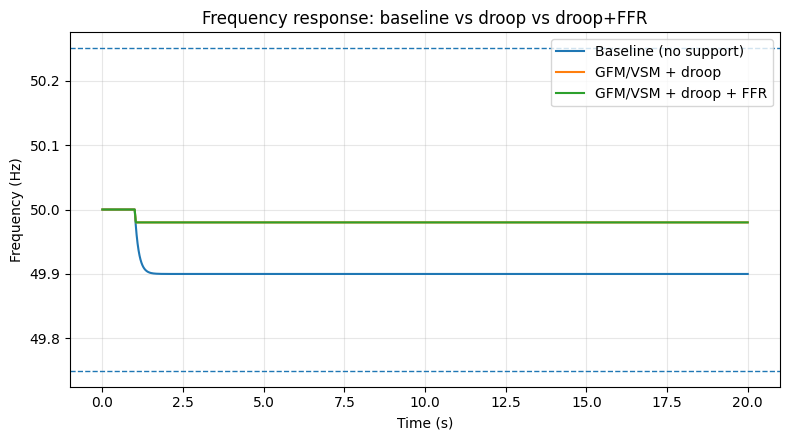

,Case,Model,RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,Baseline (no support),ThesisFreqCases.BaseCase,0.766689,49.90,1.20,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,GFM/VSM + droop,ThesisFreqCases.DroopCase,0.750001,49.98,1.01,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,GFM/VSM + droop + FFR,ThesisFreqCases.DroopFFRCase,0.825001,49.98,0.00,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


In [21]:
CASE_MODELS = {
    "Baseline (no support)": "ThesisFreqCases.BaseCase",
    "GFM/VSM + droop": "ThesisFreqCases.DroopCase",
    "GFM/VSM + droop + FFR": "ThesisFreqCases.DroopFFRCase",
}

results_rows = []
plt.figure(figsize=(8, 4.5))

for case_name, model_name in CASE_MODELS.items():
    result_csv, raw = simulate_openmodelica_model(
        omc, model_name, stopTime=20.0, stepSize=0.01, outputFormat="csv"
    )

    df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.02)

    results_rows.append([case_name, model_name, rocof, nadir, settling, result_csv])

    plt.plot(t, f_hz, label=case_name)

# Nigeria grid-code normal band (visual reference)
plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency response: baseline vs droop vs droop+FFR")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

case_metrics_df = pd.DataFrame(results_rows, columns=[
    "Case", "Model", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

case_metrics_df

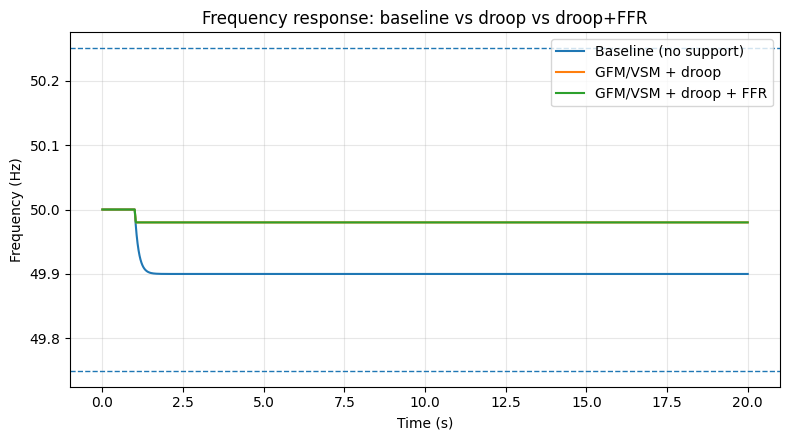

Saved metrics: C:\Users\ADMIN\Desktop\ms-project\dynamic_metrics_cases_openmodelica.csv
Saved figure: C:\Users\ADMIN\Desktop\ms-project\frequency_response_openmodelica_cases.png


In [22]:
out_dir = r"C:\Users\ADMIN\Desktop\ms-project"
os.makedirs(out_dir, exist_ok=True)

metrics_csv = os.path.join(out_dir, "dynamic_metrics_cases_openmodelica.csv")
plot_png = os.path.join(out_dir, "frequency_response_openmodelica_cases.png")

case_metrics_df.to_csv(metrics_csv, index=False)

# save plot
plt.figure(figsize=(8, 4.5))
for _, row in case_metrics_df.iterrows():
    df_res, t, f_hz, _ = load_thesis_frequency(row["Result CSV"])
    plt.plot(t, f_hz, label=row["Case"])
plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency response: baseline vs droop vs droop+FFR")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(plot_png, dpi=300, bbox_inches="tight")
plt.show()

print("Saved metrics:", metrics_csv)
print("Saved figure:", plot_png)

## Using PV + WING Data

In [25]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ZIP_PATH = r"C:\Users\ADMIN\Desktop\data.zip"  # uploaded file in this chat

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    # adjust if your zip root changes
    stage3_path = "data/stage3_timeseries/stage3_timeseries_summary.csv"
    with z.open(stage3_path) as f:
        ts_df = pd.read_csv(f)

# Clean column names
ts_df.columns = [c.strip() for c in ts_df.columns]

# Force numeric
for c in ["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]:
    ts_df[c] = pd.to_numeric(ts_df[c], errors="coerce")

ts_df = ts_df.dropna(subset=["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]).copy()

# Build net-load series (load minus RES)
ts_df["P_res_MW"] = ts_df["P_pv_MW"] + ts_df["P_wind_MW"]
ts_df["P_net_MW"] = ts_df["P_load_scaled_MW"] - ts_df["P_res_MW"]

# Hour-to-hour ramps (positive = increasing net load = harder for frequency)
ts_df["dP_net_MW"] = ts_df["P_net_MW"].diff()
ts_df["dP_res_MW"] = ts_df["P_res_MW"].diff()

display(ts_df.head())
print("Columns:", ts_df.columns.tolist())

,hour,load_scale,pv_availability,wind_availability,P_load_scaled_MW,P_pv_MW,P_wind_MW,Vmin_pu,Vmax_pu,max_line_loading_pct,max_line_name,losses_MW,P_res_MW,P_net_MW,dP_net_MW,dP_res_MW
0,0,0.512236,0.0,0.761803,1.028229,0.0,0.176244,0.994817,1.049409,8.485616,L_2_3,NaN,0.176244,0.851985,NaN,NaN
1,1,0.500343,0.0,0.786716,1.004355,0.0,0.177782,0.994953,1.050001,8.558682,L_2_3,NaN,0.177782,0.826573,-0.025411,0.001538
2,2,0.505463,0.0,0.798904,1.014634,0.0,0.182384,0.994895,1.049865,8.548889,L_2_3,NaN,0.182384,0.832250,0.005677,0.004602
3,3,0.527248,0.0,0.797538,1.058364,0.0,0.189919,0.994648,1.049013,8.458898,L_2_3,NaN,0.189919,0.868445,0.036195,0.007535
4,4,0.564214,0.0,0.782709,1.132566,0.0,0.199456,0.994228,1.047490,8.298855,L_2_3,NaN,0.199456,0.933110,0.064665,0.009537


Columns: ['hour', 'load_scale', 'pv_availability', 'wind_availability', 'P_load_scaled_MW', 'P_pv_MW', 'P_wind_MW', 'Vmin_pu', 'Vmax_pu', 'max_line_loading_pct', 'max_line_name', 'losses_MW', 'P_res_MW', 'P_net_MW', 'dP_net_MW', 'dP_res_MW']


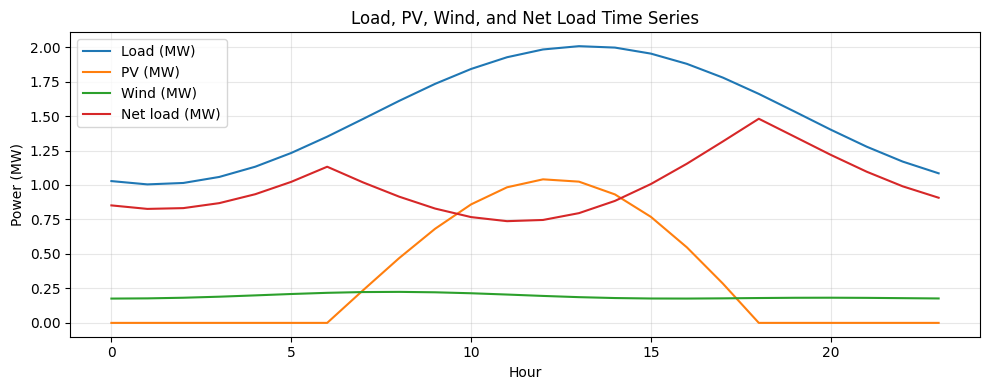

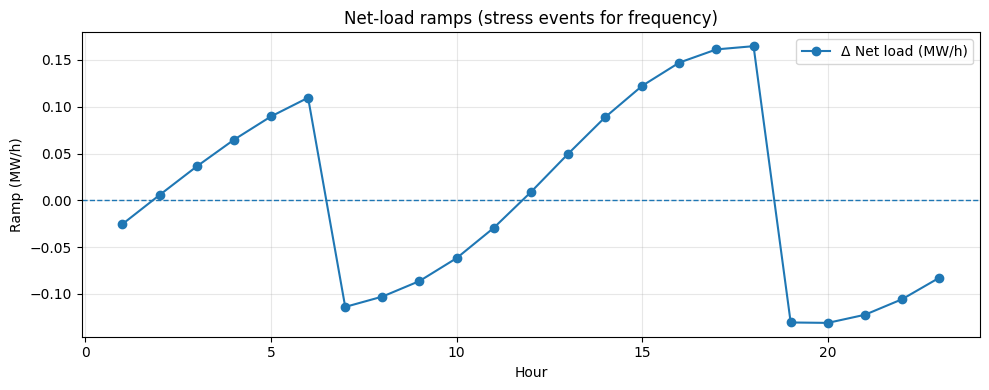

In [26]:
plt.figure(figsize=(10,4))
plt.plot(ts_df["hour"], ts_df["P_load_scaled_MW"], label="Load (MW)")
plt.plot(ts_df["hour"], ts_df["P_pv_MW"], label="PV (MW)")
plt.plot(ts_df["hour"], ts_df["P_wind_MW"], label="Wind (MW)")
plt.plot(ts_df["hour"], ts_df["P_net_MW"], label="Net load (MW)")
plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title("Load, PV, Wind, and Net Load Time Series")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ts_df["hour"], ts_df["dP_net_MW"], marker="o", label="Δ Net load (MW/h)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Hour")
plt.ylabel("Ramp (MW/h)")
plt.title("Net-load ramps (stress events for frequency)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
# Worst upward ramp in net load (largest positive dP_net_MW) = most stressful event
worst_idx = ts_df["dP_net_MW"].idxmax()
worst_event = ts_df.loc[worst_idx]

print("Worst net-load ramp event:")
display(worst_event[["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW", "P_net_MW", "dP_net_MW"]])

# Choose system base power for pu conversion.
# You can use feeder peak load or a fixed study base. This uses peak load from your data.
S_base_MW = float(ts_df["P_load_scaled_MW"].max())
print("S_base_MW (used for pu conversion):", S_base_MW)

# Disturbance in pu (negative means power deficit in our OpenModelica model convention)
dPstep_pu_from_data = - float(worst_event["dP_net_MW"] / S_base_MW)
print("dPstep_pu_from_data:", dPstep_pu_from_data)

Worst net-load ramp event:


hour                      18
P_load_scaled_MW    1.660576
P_pv_MW                  0.0
P_wind_MW           0.180255
P_net_MW            1.480321
dP_net_MW           0.164787
Name: 18, dtype: object

S_base_MW (used for pu conversion): 2.0066470101039418
dPstep_pu_from_data: -0.08212042076808211


In [28]:
CASE_MODELS = {
    "Baseline (no support)": "ThesisFreqCases.BaseCase",
    "GFM/VSM + droop": "ThesisFreqCases.DroopCase",
    "GFM/VSM + droop + FFR": "ThesisFreqCases.DroopFFRCase",
}

results_rows = []
plt.figure(figsize=(8,4.5))

for case_name, model_name in CASE_MODELS.items():
    # Use your data-derived event size
    overrides = {
        "dPstep": dPstep_pu_from_data,
        "tEvent": 1.0
    }

    result_csv, _ = simulate_openmodelica_model(
        omc,
        model_name,
        stopTime=20.0,
        stepSize=0.01,
        outputFormat="csv",
        parameter_overrides=overrides
    )

    df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.01)  # tighter eps

    results_rows.append([
        case_name, model_name, dPstep_pu_from_data, rocof, nadir, settling, result_csv
    ])

    plt.plot(t, f_hz, label=case_name)

plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency response using PV+wind net-load disturbance (from your data)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

case_metrics_data_driven = pd.DataFrame(results_rows, columns=[
    "Case", "Model", "dPstep (pu, from data)", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

display(case_metrics_data_driven)

OMCSessionException: [OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase(dPstep=-0.08212042076808211,tEvent=1.0), stopTime=20.0, stepSize=0.01, outputFormat="csv"), True)']: [translation:error:3] Class simulate not found in scope <global scope> (looking for a function or record).

<Figure size 800x450 with 0 Axes>

In [1]:
import os
import re
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------- EDIT THIS BASE PATH TO YOUR PC ----------
BASE_DIR = r"C:\Users\ADMIN\Desktop\ms-project"   # where you want outputs + Modelica file saved
DATA_ZIP_PATH = r"C:\Users\ADMIN\Desktop\data.zip"  # your uploaded data.zip on your PC
EXTRACTED_DATA_DIR = r"C:\Users\ADMIN\Desktop\data"  # optional: if already extracted (contains stage3_timeseries folder)
# ---------------------------------------------------

os.makedirs(BASE_DIR, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("ZIP exists:", os.path.exists(DATA_ZIP_PATH))
print("Extracted data dir exists:", os.path.exists(EXTRACTED_DATA_DIR))


BASE_DIR: C:\Users\ADMIN\Desktop\ms-project
ZIP exists: True
Extracted data dir exists: True


In [2]:
THESIS_MO_PATH = os.path.join(BASE_DIR, "ThesisFreqCases.mo")

modelica_code = r'''
within ;
package ThesisFreqCases
  /*
    Reduced-order frequency response models for disturbance studies.
    Exports:
      - fHz       : frequency (Hz)
      - df        : frequency deviation (Hz)
      - rocofHzps : RoCoF (Hz/s)
      - Pdist, Pdroop, Pffr, Psupport
  */

  partial model BaseFreqCase
    parameter Real f0 = 50 "Nominal frequency (Hz)";
    parameter Real H = 4.0 "Virtual inertia constant (s)";
    parameter Real D = 1.0 "Damping coefficient (pu/Hz)";
    parameter Real R = 0.06 "Droop gain (Hz/pu)";
    parameter Real deadband = 0.02 "Deadband (Hz)";
    parameter Real PmaxDroop = 0.20 "Droop support cap (pu)";
    parameter Real PmaxFFR = 0.10 "FFR support cap (pu)";
    parameter Real PmaxTotal = 0.30 "Total support cap (pu)";
    parameter Real ffrGain = 1.0 "FFR gain (pu/Hz)";
    parameter Real ffrDuration = 2.0 "FFR duration (s)";

    parameter Real tEvent = 1.0 "Disturbance start time (s)";
    parameter Real dPstep = -0.10 "Disturbance (pu), negative = deficit";

    Real df(start=0) "Frequency deviation (Hz)";
    Real fHz "Frequency (Hz)";
    Real rocofHzps "RoCoF (Hz/s)";

    Real Pdist "Disturbance power (pu)";
    Real Pdroop "Droop support (pu)";
    Real Pffr "FFR support (pu)";
    Real Psupport "Total support (pu)";

  protected
    Real Pdroop_raw;
    Real Pffr_raw;

  equation
    // Disturbance step
    Pdist = if time < tEvent then 0 else dPstep;

    // Droop control with deadband
    Pdroop_raw =
      if noEvent(abs(df) <= deadband) then 0
      else -df / R;

    Pdroop = min(max(Pdroop_raw, -PmaxDroop), PmaxDroop);

    // Fast frequency response (active shortly after event)
    Pffr_raw =
      if noEvent(time < tEvent or time > tEvent + ffrDuration or abs(df) <= deadband) then 0
      else -ffrGain * df;

    Pffr = min(max(Pffr_raw, -PmaxFFR), PmaxFFR);

    Psupport = min(max(Pdroop + Pffr, -PmaxTotal), PmaxTotal);

    // Reduced-order swing-like dynamics
    der(df) = (f0 / (2 * H)) * (Pdist + Psupport - D * df);

    fHz = f0 + df;
    rocofHzps = der(fHz);

    annotation(experiment(StopTime=20, Interval=0.01));
  end BaseFreqCase;

  model BaseCase
    extends BaseFreqCase(
      H=4.0, D=1.0, R=0.06, deadband=0.02,
      PmaxDroop=0.0, PmaxFFR=0.0, PmaxTotal=0.0,
      ffrGain=0.0, ffrDuration=0.0,
      tEvent=1.0, dPstep=-0.10
    );
    annotation(experiment(StopTime=20, Interval=0.01));
  end BaseCase;

  model DroopCase
    extends BaseFreqCase(
      H=4.0, D=1.0, R=0.06, deadband=0.02,
      PmaxDroop=0.20, PmaxFFR=0.0, PmaxTotal=0.20,
      ffrGain=0.0, ffrDuration=0.0,
      tEvent=1.0, dPstep=-0.10
    );
    annotation(experiment(StopTime=20, Interval=0.01));
  end DroopCase;

  model DroopFFRCase
    extends BaseFreqCase(
      H=4.0, D=1.0, R=0.06, deadband=0.02,
      PmaxDroop=0.20, PmaxFFR=0.15, PmaxTotal=0.30,
      ffrGain=1.0, ffrDuration=2.0,
      tEvent=1.0, dPstep=-0.10
    );
    annotation(experiment(StopTime=20, Interval=0.01));
  end DroopFFRCase;

end ThesisFreqCases;
'''

with open(THESIS_MO_PATH, "w", encoding="utf-8") as f:
    f.write(modelica_code)

print("Wrote:", THESIS_MO_PATH)

Wrote: C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo


In [3]:
from OMPython import OMCSessionZMQ

omc = OMCSessionZMQ()

# Load Modelica standard library
print("loadModel(Modelica):", omc.sendExpression("loadModel(Modelica)"))

# Load your custom package
print("loadFile(ThesisFreqCases.mo):", omc.sendExpression(f'loadFile("{THESIS_MO_PATH}")'))

# Confirm classes are visible
print("Classes in ThesisFreqCases:")
print(omc.sendExpression("getClassNames(ThesisFreqCases, recursive=true)"))

loadModel(Modelica): True


[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \T is not a valid Modelica escape sequence.


loadFile(ThesisFreqCases.mo): True
Classes in ThesisFreqCases:
('ThesisFreqCases', 'ThesisFreqCases.BaseFreqCase', 'ThesisFreqCases.BaseCase', 'ThesisFreqCases.DroopCase', 'ThesisFreqCases.DroopFFRCase')


In [5]:
def simulate_openmodelica_model(omc, model_name, stopTime=20.0, stepSize=0.01, outputFormat="csv", parameter_overrides=None):
    """
    Simulate a Modelica model and return result CSV path.
    Uses OpenModelica simflags override syntax (robust for parameter changes).
    """
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    # Use numberOfIntervals for consistent samples
    n_intervals = int(round(stopTime / stepSize))
    cmd = (
        f'simulate({model_name}, stopTime={stopTime}, numberOfIntervals={n_intervals}, '
        f'outputFormat="{outputFormat}"{simflags})'
    )

    sim_out = omc.sendExpression(cmd)
    print(f"\nSimulating: {model_name}")
    print("simulate() output:", sim_out)

    if isinstance(sim_out, dict) and "resultFile" in sim_out:
        return sim_out["resultFile"], sim_out

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        return m.group(1), sim_out

    raise RuntimeError("Could not parse result CSV path from simulate() output.")


def load_thesis_frequency(result_csv):
    """
    Load frequency outputs from ThesisFreqCases model.
    Expected columns: time, fHz, rocofHzps
    """
    df = pd.read_csv(result_csv)

    needed = ["time", "fHz", "rocofHzps"]
    for c in needed:
        if c not in df.columns:
            raise RuntimeError(f"Column '{c}' not found. Available columns: {df.columns.tolist()[:40]}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"], keep="first").reset_index(drop=True)

    t = df["time"].values
    f_hz = df["fHz"].values
    rocof_trace = df["rocofHzps"].values if "rocofHzps" in df.columns else None
    return df, t, f_hz, rocof_trace


def compute_frequency_metrics(t, f_hz, rocof_trace=None, eps=0.01):
    """
    Computes RoCoF, nadir, and settling time.
    eps = settling band around final value (Hz)
    """
    t = np.asarray(t, dtype=float)
    f = np.asarray(f_hz, dtype=float)

    # RoCoF
    if rocof_trace is not None:
        r = np.asarray(rocof_trace, dtype=float)
        rocof = float(np.nanmax(np.abs(r)))
    else:
        dt = np.diff(t)
        df = np.diff(f)
        valid = dt > 0
        rocof = float(np.max(np.abs(df[valid] / dt[valid]))) if np.any(valid) else np.nan

    # Nadir
    nadir = float(np.nanmin(f))

    # Settling time (stays within ±eps of final value)
    f_final = float(f[-1])
    within = np.abs(f - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break

    return rocof, nadir, settling


def plot_frequency_cases(results_df, title, save_path=None):
    plt.figure(figsize=(9, 5))
    for _, row in results_df.iterrows():
        df_res, t, f_hz, _ = load_thesis_frequency(row["Result CSV"])
        plt.plot(t, f_hz, label=row["Case"])
    plt.axhline(49.75, linestyle="--", linewidth=1)
    plt.axhline(50.25, linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [6]:
def load_stage3_timeseries(zip_path=DATA_ZIP_PATH, extracted_data_dir=EXTRACTED_DATA_DIR):
    """
    Loads stage3_timeseries_summary.csv either from:
    - extracted folder, or
    - data.zip
    """
    # Option A: extracted folder
    extracted_csv = os.path.join(extracted_data_dir, "stage3_timeseries", "stage3_timeseries_summary.csv")
    if os.path.exists(extracted_csv):
        print("Loading from extracted folder:", extracted_csv)
        ts_df = pd.read_csv(extracted_csv)
        return ts_df

    # Option B: zip file
    if os.path.exists(zip_path):
        print("Loading from zip:", zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            # common path inside your zip
            target = "data/stage3_timeseries/stage3_timeseries_summary.csv"
            if target not in z.namelist():
                # fallback search
                matches = [n for n in z.namelist() if n.endswith("stage3_timeseries_summary.csv")]
                if not matches:
                    raise FileNotFoundError("stage3_timeseries_summary.csv not found inside zip.")
                target = matches[0]
            with z.open(target) as f:
                ts_df = pd.read_csv(f)
        return ts_df

    raise FileNotFoundError("Could not find extracted data folder or data.zip.")


ts_df = load_stage3_timeseries()

# Clean + numeric
ts_df.columns = [c.strip() for c in ts_df.columns]
for c in ["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]:
    ts_df[c] = pd.to_numeric(ts_df[c], errors="coerce")

ts_df = ts_df.dropna(subset=["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]).copy()

# Build net load and ramps
ts_df["P_res_MW"] = ts_df["P_pv_MW"] + ts_df["P_wind_MW"]
ts_df["P_net_MW"] = ts_df["P_load_scaled_MW"] - ts_df["P_res_MW"]
ts_df["dP_net_MW"] = ts_df["P_net_MW"].diff()

display(ts_df.head())
print("Rows:", len(ts_df))

Loading from extracted folder: C:\Users\ADMIN\Desktop\data\stage3_timeseries\stage3_timeseries_summary.csv


,hour,load_scale,pv_availability,wind_availability,P_load_scaled_MW,P_pv_MW,P_wind_MW,Vmin_pu,Vmax_pu,max_line_loading_pct,max_line_name,losses_MW,P_res_MW,P_net_MW,dP_net_MW
0,0,0.512236,0.0,0.761803,1.028229,0.0,0.176244,0.994817,1.049409,8.485616,L_2_3,NaN,0.176244,0.851985,NaN
1,1,0.500343,0.0,0.786716,1.004355,0.0,0.177782,0.994953,1.050001,8.558682,L_2_3,NaN,0.177782,0.826573,-0.025411
2,2,0.505463,0.0,0.798904,1.014634,0.0,0.182384,0.994895,1.049865,8.548889,L_2_3,NaN,0.182384,0.832250,0.005677
3,3,0.527248,0.0,0.797538,1.058364,0.0,0.189919,0.994648,1.049013,8.458898,L_2_3,NaN,0.189919,0.868445,0.036195
4,4,0.564214,0.0,0.782709,1.132566,0.0,0.199456,0.994228,1.047490,8.298855,L_2_3,NaN,0.199456,0.933110,0.064665


Rows: 24


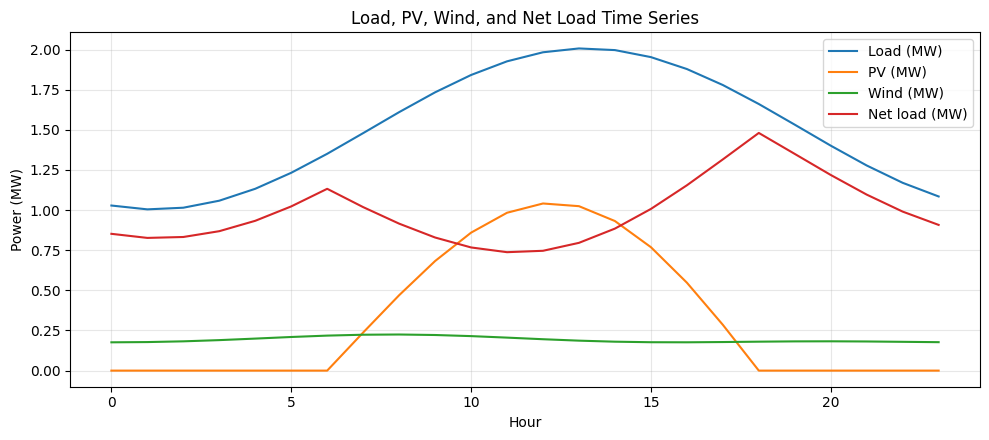

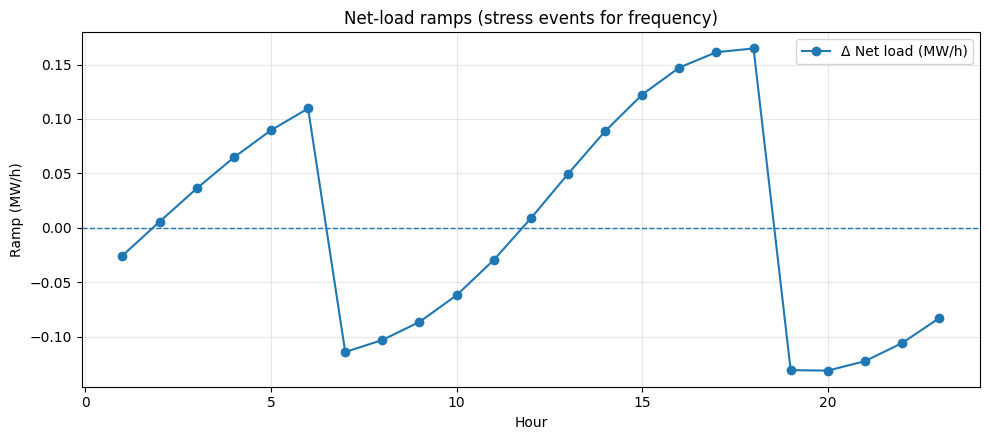

In [7]:
plt.figure(figsize=(10, 4.5))
plt.plot(ts_df["hour"], ts_df["P_load_scaled_MW"], label="Load (MW)")
plt.plot(ts_df["hour"], ts_df["P_pv_MW"], label="PV (MW)")
plt.plot(ts_df["hour"], ts_df["P_wind_MW"], label="Wind (MW)")
plt.plot(ts_df["hour"], ts_df["P_net_MW"], label="Net load (MW)")
plt.xlabel("Hour")
plt.ylabel("Power (MW)")
plt.title("Load, PV, Wind, and Net Load Time Series")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot(ts_df["hour"], ts_df["dP_net_MW"], marker="o", label="Δ Net load (MW/h)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Hour")
plt.ylabel("Ramp (MW/h)")
plt.title("Net-load ramps (stress events for frequency)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Worst upward ramp in net load (most stressful frequency event)
worst_idx = ts_df["dP_net_MW"].idxmax()
worst_event = ts_df.loc[worst_idx]

print("Worst net-load ramp event:")
display(worst_event[["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW", "P_net_MW", "dP_net_MW"]])

# Use peak load as base for pu conversion
S_base_MW = float(ts_df["P_load_scaled_MW"].max())
print("S_base_MW (MW):", S_base_MW)

# Negative sign = deficit in our frequency model convention
dPstep_pu_from_data = - float(worst_event["dP_net_MW"] / S_base_MW)
print("dPstep_pu_from_data:", dPstep_pu_from_data)

Worst net-load ramp event:


hour                      18
P_load_scaled_MW    1.660576
P_pv_MW                  0.0
P_wind_MW           0.180255
P_net_MW            1.480321
dP_net_MW           0.164787
Name: 18, dtype: object

S_base_MW (MW): 2.0066470101039418
dPstep_pu_from_data: -0.08212042076808211


[OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.08212042076808211,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.BaseCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.BaseCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.BaseCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.08212042076808211,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.6810496, 'timeBackend': 0.0788193, 'timeSimCode': 0.0130974, 'timeTemplates': 0.1154808, 'timeCompile': 18.8080126, 'timeSimulation': 11.1079069, 'timeTotal': 30.8051745}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.08212042076808211,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.08212042076808211,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.1916502, 'timeBackend': 0.0745772, 'timeSimCode': 0.0092965, 'timeTemplates': 0.0825798, 'timeCompile': 19.695896, 'timeSimulation': 470.7949083, 'timeTotal': 490.849591}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.08212042076808211,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.08212042076808211,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.3060614, 'timeBackend': 0.085066, 'timeSimCode': 0.014954, 'timeTemplates': 0.0701369, 'timeCompile': 16.6393984, 'timeSimulation': 340.2588239, 'timeTotal': 357.3750696}


,Case,Model,"dPstep (pu, from data)",RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,Baseline (no support),ThesisFreqCases.BaseCase,-0.08212,0.482152,49.917879,1.34,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,GFM/VSM + droop,ThesisFreqCases.DroopCase,-0.08212,0.482152,49.980000,1.03,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,GFM/VSM + droop + FFR,ThesisFreqCases.DroopFFRCase,-0.08212,0.482152,49.980000,1.03,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


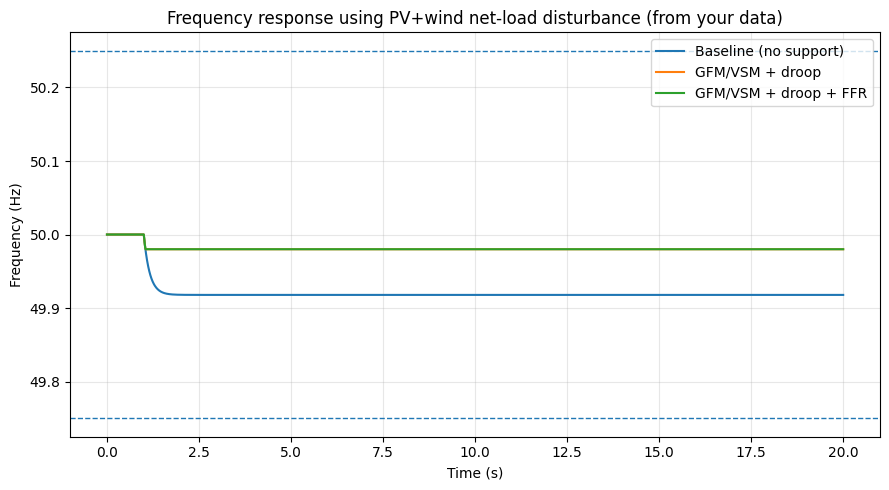

In [9]:
CASE_MODELS = {
    "Baseline (no support)": "ThesisFreqCases.BaseCase",
    "GFM/VSM + droop": "ThesisFreqCases.DroopCase",
    "GFM/VSM + droop + FFR": "ThesisFreqCases.DroopFFRCase",
}

rows = []
for case_name, model_name in CASE_MODELS.items():
    overrides = {
        "dPstep": dPstep_pu_from_data,
        "tEvent": 1.0
    }

    result_csv, _ = simulate_openmodelica_model(
        omc,
        model_name,
        stopTime=20.0,
        stepSize=0.01,
        outputFormat="csv",
        parameter_overrides=overrides
    )

    df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.01)

    rows.append([
        case_name, model_name, dPstep_pu_from_data, rocof, nadir, settling, result_csv
    ])

case_metrics_data_driven = pd.DataFrame(rows, columns=[
    "Case", "Model", "dPstep (pu, from data)", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

display(case_metrics_data_driven)

plot_frequency_cases(
    case_metrics_data_driven,
    title="Frequency response using PV+wind net-load disturbance (from your data)",
    save_path=os.path.join(BASE_DIR, "frequency_response_data_driven_cases.png")
)

[OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.15,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.BaseCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.BaseCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.BaseCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.15,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.6128081, 'timeBackend': 0.0442841, 'timeSimCode': 0.0059124, 'timeTemplates': 0.1823489, 'timeCompile': 17.3361507, 'timeSimulation': 2.1701099, 'timeTotal': 21.3521555}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.15,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.15,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.2889496, 'timeBackend': 0.0536869, 'timeSimCode': 0.0061631, 'timeTemplates': 0.0274822, 'timeCompile': 10.8294682, 'timeSimulation': 428.3814712, 'timeTotal': 439.5879536}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.15,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.15,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.5056414, 'timeBackend': 0.0909794, 'timeSimCode': 0.0145786, 'timeTemplates': 0.0503942, 'timeCompile': 14.7068839, 'timeSimulation': 548.24607, 'timeTotal': 563.6155897}


,Case,Model,"dPstep (pu, stress)",RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,Baseline (no support),ThesisFreqCases.BaseCase,-0.15,0.880692,49.849999,1.44,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,GFM/VSM + droop,ThesisFreqCases.DroopCase,-0.15,0.880692,49.980000,1.02,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,GFM/VSM + droop + FFR,ThesisFreqCases.DroopFFRCase,-0.15,0.880692,49.980000,1.02,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


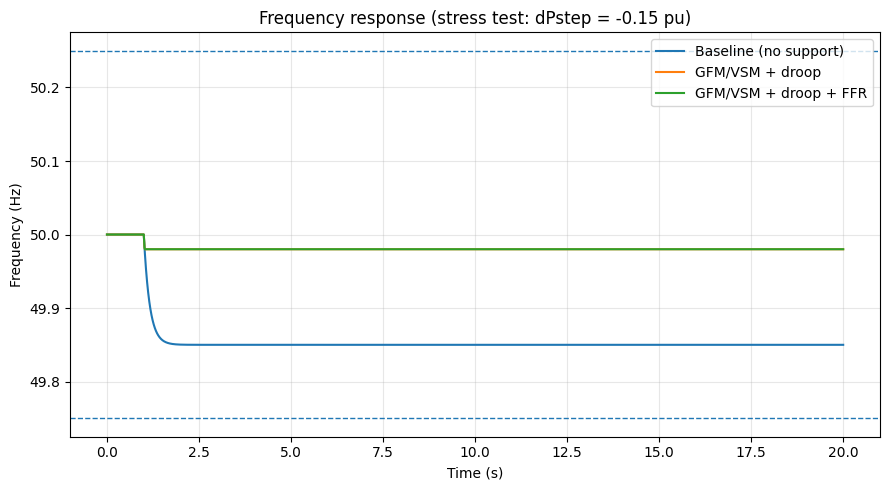

In [10]:
dPstep_stress = -0.15  # standardized severe test (pu)

rows_stress = []
for case_name, model_name in CASE_MODELS.items():
    overrides = {
        "dPstep": dPstep_stress,
        "tEvent": 1.0
    }

    result_csv, _ = simulate_openmodelica_model(
        omc,
        model_name,
        stopTime=20.0,
        stepSize=0.01,
        outputFormat="csv",
        parameter_overrides=overrides
    )

    df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.01)

    rows_stress.append([
        case_name, model_name, dPstep_stress, rocof, nadir, settling, result_csv
    ])

case_metrics_stress = pd.DataFrame(rows_stress, columns=[
    "Case", "Model", "dPstep (pu, stress)", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

display(case_metrics_stress)

plot_frequency_cases(
    case_metrics_stress,
    title="Frequency response (stress test: dPstep = -0.15 pu)",
    save_path=os.path.join(BASE_DIR, "frequency_response_stress_cases.png")
)

In [11]:
penetrations = [0, 10, 25, 50, 75]

# Find worst net-load ramp for each penetration level
pen_event_rows = []
for pen in penetrations:
    scale = pen / 100.0
    tmp = ts_df.copy()
    tmp["P_res_pen_MW"] = scale * (tmp["P_pv_MW"] + tmp["P_wind_MW"])
    tmp["P_net_pen_MW"] = tmp["P_load_scaled_MW"] - tmp["P_res_pen_MW"]
    tmp["dP_net_pen_MW"] = tmp["P_net_pen_MW"].diff()

    idx = tmp["dP_net_pen_MW"].idxmax()
    evt = tmp.loc[idx]

    dPstep_pu = - float(evt["dP_net_pen_MW"] / S_base_MW)

    pen_event_rows.append([
        pen,
        float(evt["hour"]),
        float(evt["dP_net_pen_MW"]),
        dPstep_pu
    ])

pen_event_df = pd.DataFrame(pen_event_rows, columns=[
    "Penetration (%)", "Worst-ramp hour", "Worst ΔP_net (MW)", "dPstep (pu)"
])

display(pen_event_df)

,Penetration (%),Worst-ramp hour,Worst ΔP_net (MW),dPstep (pu)
0,0,8.0,0.130601,-0.065084
1,10,6.0,0.117384,-0.058498
2,25,6.0,0.116095,-0.057855
3,50,6.0,0.113948,-0.056785
4,75,6.0,0.111800,-0.055715


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.06508421067736557,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.06508421067736557,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 2.9803729, 'timeBackend': 0.0673183, 'timeSimCode': 0.0090392, 'timeTemplates': 0.0995411, 'timeCompile': 18.5422386, 'timeSimulation': 368.5577182, 'timeTotal': 390.2568257}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.05849758845044143,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.05849758845044143,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.1368577, 'timeBackend': 0.0768771, 'timeSimCode': 0.0113958, 'timeTemplates': 0.0243632, 'timeCompile': 15.7403433, 'timeSimulation': 362.9372493, 'timeTotal': 379.9275143}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.05785542252758682,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.05785542252758682,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.3183574, 'timeBackend': 0.120241, 'timeSimCode': 0.017318, 'timeTemplates': 0.0612112, 'timeCompile': 18.2033231, 'timeSimulation': 357.6186092, 'timeTotal': 377.3400546}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.056785145989495876,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.056785145989495876,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.4154877, 'timeBackend': 0.0814112, 'timeSimCode': 0.015076, 'timeTemplates': 0.0403487, 'timeCompile': 13.9689089, 'timeSimulation': 380.9419884, 'timeTotal': 396.4638399}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=dPstep=-0.055714869451404934,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=dPstep=-0.055714869451404934,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.1566866, 'timeBackend': 0.0645741, 'timeSimCode': 0.0107134, 'timeTemplates': 0.0580983, 'timeCompile': 24.1911754, 'timeSimulation': 358.0097101, 'timeTotal': 383.4914688}


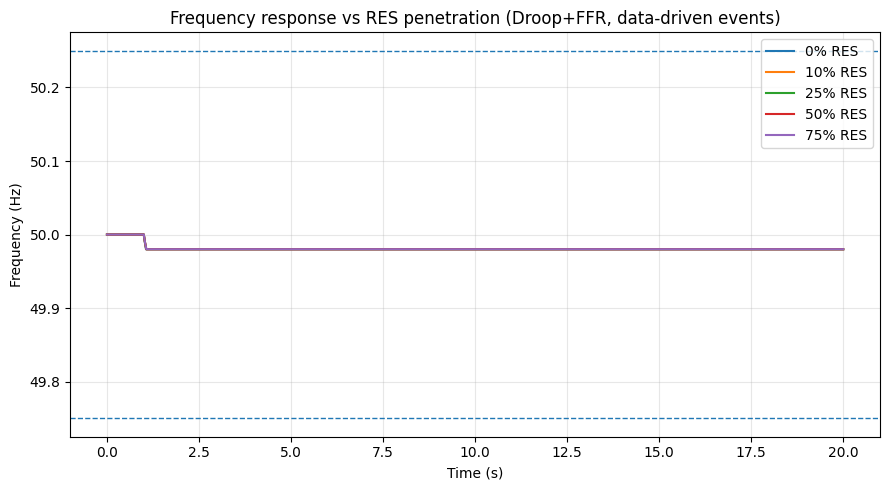

,Penetration (%),dPstep (pu),RoCoF (Hz/s),Nadir (Hz),Settling time (s),Result CSV
0,0,-0.065084,0.382128,49.98,1.03,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
1,10,-0.058498,0.343456,49.98,1.03,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
2,25,-0.057855,0.339686,49.98,1.04,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
3,50,-0.056785,0.333402,49.98,1.04,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...
4,75,-0.055715,0.327118,49.98,1.04,C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCa...


In [12]:
pen_rows = []
plt.figure(figsize=(9, 5))

for _, r in pen_event_df.iterrows():
    pen = int(r["Penetration (%)"])
    dPstep_pu = float(r["dPstep (pu)"])

    result_csv, _ = simulate_openmodelica_model(
        omc,
        "ThesisFreqCases.DroopFFRCase",
        stopTime=20.0,
        stepSize=0.01,
        outputFormat="csv",
        parameter_overrides={"dPstep": dPstep_pu, "tEvent": 1.0}
    )

    df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.01)

    pen_rows.append([pen, dPstep_pu, rocof, nadir, settling, result_csv])
    plt.plot(t, f_hz, label=f"{pen}% RES")

plt.axhline(49.75, linestyle="--", linewidth=1)
plt.axhline(50.25, linestyle="--", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Frequency response vs RES penetration (Droop+FFR, data-driven events)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "frequency_response_vs_penetration.png"), dpi=300, bbox_inches="tight")
plt.show()

pen_freq_metrics_df = pd.DataFrame(pen_rows, columns=[
    "Penetration (%)", "dPstep (pu)", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

display(pen_freq_metrics_df)

In [ ]:
Hs = [2.0, 3.0, 4.0, 5.0]
Rs = [0.04, 0.05, 0.06, 0.08]
DBs = [0.01, 0.02, 0.03, 0.05]

# Use your data-driven event OR the stress test
dP_for_sensitivity = dPstep_pu_from_data  # or use dPstep_stress

sens_rows = []
for H in Hs:
    for R in Rs:
        for db in DBs:
            overrides = {
                "H": H,
                "R": R,
                "deadband": db,
                "dPstep": dP_for_sensitivity,
                "tEvent": 1.0
            }

            result_csv, _ = simulate_openmodelica_model(
                omc,
                "ThesisFreqCases.DroopFFRCase",
                stopTime=20.0,
                stepSize=0.01,
                outputFormat="csv",
                parameter_overrides=overrides
            )

            df_res, t, f_hz, rocof_trace = load_thesis_frequency(result_csv)
            rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace=rocof_trace, eps=0.01)

            sens_rows.append([H, R, db, rocof, nadir, settling])

sens_df = pd.DataFrame(sens_rows, columns=[
    "H (s)", "Droop R (Hz/pu)", "Deadband (Hz)",
    "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)"
])

display(sens_df.head(10))

[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=H=2.0,R=0.04,deadband=0.01,dPstep=-0.08212042076808211,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=H=2.0,R=0.04,deadband=0.01,dPstep=-0.08212042076808211,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 0.8870393, 'timeBackend': 0.1172106, 'timeSimCode': 0.0265291, 'timeTemplates': 0.0349348, 'timeCompile': 8.2343504, 'timeSimulation': 743.6807298, 'timeTotal': 752.9828341}


[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=20.0, numberOfIntervals=2000, outputFormat="csv", simflags="-override=H=2.0,R=0.04,deadband=0.02,dPstep=-0.08212042076808211,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").



Simulating: ThesisFreqCases.DroopFFRCase
simulate() output: {'resultFile': 'C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.DroopFFRCase_res.csv', 'simulationOptions': "startTime = 0.0, stopTime = 20.0, numberOfIntervals = 2000, tolerance = 1e-6, method = 'dassl', fileNamePrefix = 'ThesisFreqCases.DroopFFRCase', options = '', outputFormat = 'csv', variableFilter = '.*', cflags = '', simflags = '-override=H=2.0,R=0.04,deadband=0.02,dPstep=-0.08212042076808211,tEvent=1.0'", 'messages': 'LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.\nLOG_SUCCESS       | info    | The simulation finished successfully.\n', 'timeFrontend': 1.7585517, 'timeBackend': 0.0363867, 'timeSimCode': 0.0062189, 'timeTemplates': 0.1485722, 'timeCompile': 12.3131382, 'timeSimulation': 1001.8356101, 'timeTotal': 1016.0990045}


In [1]:
import os, re, zipfile, numpy as np, pandas as pd, matplotlib.pyplot as plt
from OMPython import OMCSessionZMQ

# ===== EDIT ONLY THESE TWO PATHS =====
BASE_DIR = r"C:\Users\ADMIN\Desktop\ms-project"
DATA_ZIP_PATH = r"C:\Users\ADMIN\Desktop\data.zip"
# ====================================

os.makedirs(BASE_DIR, exist_ok=True)
THESIS_MO_PATH = os.path.join(BASE_DIR, "ThesisFreqCases.mo")

print("BASE_DIR:", BASE_DIR)
print("ZIP exists:", os.path.exists(DATA_ZIP_PATH))
print("Thesis .mo will be:", THESIS_MO_PATH)

BASE_DIR: C:\Users\ADMIN\Desktop\ms-project
ZIP exists: True
Thesis .mo will be: C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo


In [2]:
modelica_code = r'''
within ;
package ThesisFreqCases
  /*
    Reduced-order frequency response models (OpenModelica).
    Exports:
      time, fHz, rocofHzps, df, Pdist, Pdroop, Pffr, Psupport
  */

  partial model BaseFreqCase
    parameter Real f0 = 50 "Nominal frequency (Hz)";
    parameter Real H = 4.0 "Virtual inertia constant (s)";
    parameter Real D = 1.0 "Damping coefficient (pu/Hz)";
    parameter Real R = 0.06 "Droop gain (Hz/pu)";
    parameter Real deadband = 0.02 "Deadband (Hz)";

    // Response speed difference (important for seeing FFR benefit)
    parameter Real T_droop = 0.30 "Droop measurement/actuation time constant (s)";
    parameter Real T_ffr   = 0.05 "FFR time constant (s)";

    parameter Real PmaxDroop = 0.20 "Droop support cap (pu)";
    parameter Real PmaxFFR = 0.15 "FFR support cap (pu)";
    parameter Real PmaxTotal = 0.30 "Total support cap (pu)";
    parameter Real ffrGain = 1.00 "FFR gain (pu/Hz)";
    parameter Real ffrDuration = 2.0 "FFR duration after event (s)";

    parameter Real tEvent = 1.0 "Disturbance start time (s)";
    parameter Real dPstep = -0.10 "Disturbance (pu), negative = deficit";

    Real df(start=0) "Frequency deviation (Hz)";
    Real fHz "Frequency (Hz)";
    Real rocofHzps "RoCoF (Hz/s)";

    Real Pdist "Disturbance power (pu)";
    Real Pdroop "Droop support (pu)";
    Real Pffr "FFR support (pu)";
    Real Psupport "Total support (pu)";

  protected
    Real df_droop(start=0);
    Real df_ffr(start=0);
    Real Pdroop_raw;
    Real Pffr_raw;

  equation
    // Disturbance step
    Pdist = if time < tEvent then 0 else dPstep;

    // Filtered frequency measurements (droop slower, FFR faster)
    der(df_droop) = (df - df_droop)/T_droop;
    der(df_ffr)   = (df - df_ffr)/T_ffr;

    // Droop control with deadband
    Pdroop_raw =
      if noEvent(abs(df_droop) <= deadband) then 0
      else -df_droop / R;

    Pdroop = min(max(Pdroop_raw, -PmaxDroop), PmaxDroop);

    // Fast frequency response (active shortly after event)
    Pffr_raw =
      if noEvent(time < tEvent or time > tEvent + ffrDuration or abs(df_ffr) <= deadband) then 0
      else -ffrGain * df_ffr;

    Pffr = min(max(Pffr_raw, -PmaxFFR), PmaxFFR);

    // Total cap
    Psupport = min(max(Pdroop + Pffr, -PmaxTotal), PmaxTotal);

    // Reduced-order swing-like dynamics
    der(df) = (f0 / (2 * H)) * (Pdist + Psupport - D * df);

    // Outputs
    fHz = f0 + df;
    rocofHzps = der(fHz);

    annotation(experiment(StopTime=15, Interval=0.01));
  end BaseFreqCase;


  model BaseCase
    extends BaseFreqCase(
      PmaxDroop=0.0, PmaxFFR=0.0, PmaxTotal=0.0,
      ffrGain=0.0, ffrDuration=0.0
    );
    annotation(experiment(StopTime=15, Interval=0.01));
  end BaseCase;


  model DroopCase
    extends BaseFreqCase(
      PmaxDroop=0.20, PmaxFFR=0.0, PmaxTotal=0.20,
      ffrGain=0.0, ffrDuration=0.0
    );
    annotation(experiment(StopTime=15, Interval=0.01));
  end DroopCase;


  model DroopFFRCase
    extends BaseFreqCase(
      PmaxDroop=0.20, PmaxFFR=0.15, PmaxTotal=0.30,
      ffrGain=1.0, ffrDuration=2.0
    );
    annotation(experiment(StopTime=15, Interval=0.01));
  end DroopFFRCase;

end ThesisFreqCases;
'''

with open(THESIS_MO_PATH, "w", encoding="utf-8") as f:
    f.write(modelica_code)

print("Wrote:", THESIS_MO_PATH, "| Exists:", os.path.exists(THESIS_MO_PATH))

Wrote: C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo | Exists: True


In [3]:
omc = OMCSessionZMQ()
print("OpenModelica version:", omc.sendExpression("getVersion()"))
print("loadModel(Modelica):", omc.sendExpression("loadModel(Modelica)"))
print("cd(BASE_DIR):", omc.sendExpression(f'cd("{BASE_DIR}")'))
print("loadFile(ThesisFreqCases.mo):", omc.sendExpression(f'loadFile("{THESIS_MO_PATH}")'))
print("isModel(BaseCase):", omc.sendExpression("isModel(ThesisFreqCases.BaseCase)"))
print("Classes:", omc.sendExpression("getClassNames(ThesisFreqCases, recursive=true)"))

OpenModelica version: OpenModelica v1.26.2 (64-bit)


[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(cd("C:\Users\ADMIN\Desktop\ms-project"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.


loadModel(Modelica): True
cd(BASE_DIR): C:/Users/ADMIN/Desktop/ms-project


[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \U is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \A is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \D is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \m is not a valid Modelica escape sequence.
[OMC log for 'sendExpression(loadFile("C:\Users\ADMIN\Desktop\ms-project\ThesisFreqCases.mo"), True)']: [syntax:warning:2] Lexer treating \ as \\, since \T is not a valid Modelica escape sequence.


loadFile(ThesisFreqCases.mo): True
isModel(BaseCase): True
Classes: ('ThesisFreqCases', 'ThesisFreqCases.BaseFreqCase', 'ThesisFreqCases.BaseCase', 'ThesisFreqCases.DroopCase', 'ThesisFreqCases.DroopFFRCase')


In [4]:
def simulate_openmodelica_model(omc, model_name, stopTime=15.0, stepSize=0.01, outputFormat="csv", parameter_overrides=None):
    """
    Fast simulation: uses numberOfIntervals and simflags override.
    """
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    n_intervals = int(round(stopTime / stepSize))
    cmd = (
        f'simulate({model_name}, stopTime={stopTime}, numberOfIntervals={n_intervals}, '
        f'outputFormat="{outputFormat}"{simflags})'
    )
    sim_out = omc.sendExpression(cmd)

    if isinstance(sim_out, dict) and "resultFile" in sim_out:
        return sim_out["resultFile"], sim_out

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        return m.group(1), sim_out

    raise RuntimeError(f"Could not parse result CSV from simulate() output: {sim_out}")


def load_thesis_frequency(result_csv):
    df = pd.read_csv(result_csv)
    for c in ["time", "fHz", "rocofHzps"]:
        if c not in df.columns:
            raise RuntimeError(f"Missing '{c}' in {result_csv}. Columns: {df.columns.tolist()[:25]}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"], keep="first").reset_index(drop=True)

    t = df["time"].values
    f_hz = df["fHz"].values
    rocof_trace = df["rocofHzps"].values
    return t, f_hz, rocof_trace


def compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01):
    rocof = float(np.nanmax(np.abs(rocof_trace)))
    nadir = float(np.nanmin(f_hz))

    f_final = float(f_hz[-1])
    within = np.abs(f_hz - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break
    return rocof, nadir, settling


def plot_cases(results_df, title, out_png):
    plt.figure(figsize=(9,5))
    for _, r in results_df.iterrows():
        t, f_hz, _ = load_thesis_frequency(r["Result CSV"])
        plt.plot(t, f_hz, label=r["Case"])
    plt.axhline(49.75, linestyle="--", linewidth=1)
    plt.axhline(50.25, linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_png)

In [5]:
with zipfile.ZipFile(DATA_ZIP_PATH, "r") as z:
    path = "data/stage3_timeseries/stage3_timeseries_summary.csv"
    with z.open(path) as f:
        ts_df = pd.read_csv(f)

ts_df.columns = [c.strip() for c in ts_df.columns]
for c in ["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]:
    ts_df[c] = pd.to_numeric(ts_df[c], errors="coerce")

ts_df = ts_df.dropna(subset=["hour", "P_load_scaled_MW", "P_pv_MW", "P_wind_MW"]).copy()
ts_df["P_res_MW"] = ts_df["P_pv_MW"] + ts_df["P_wind_MW"]
ts_df["P_net_MW"] = ts_df["P_load_scaled_MW"] - ts_df["P_res_MW"]

S_base_MW = float(ts_df["P_load_scaled_MW"].max())
print("S_base_MW:", S_base_MW)

display(ts_df.head())

S_base_MW: 2.0066470101039418


,hour,load_scale,pv_availability,wind_availability,P_load_scaled_MW,P_pv_MW,P_wind_MW,Vmin_pu,Vmax_pu,max_line_loading_pct,max_line_name,losses_MW,P_res_MW,P_net_MW
0,0,0.512236,0.0,0.761803,1.028229,0.0,0.176244,0.994817,1.049409,8.485616,L_2_3,NaN,0.176244,0.851985
1,1,0.500343,0.0,0.786716,1.004355,0.0,0.177782,0.994953,1.050001,8.558682,L_2_3,NaN,0.177782,0.826573
2,2,0.505463,0.0,0.798904,1.014634,0.0,0.182384,0.994895,1.049865,8.548889,L_2_3,NaN,0.182384,0.832250
3,3,0.527248,0.0,0.797538,1.058364,0.0,0.189919,0.994648,1.049013,8.458898,L_2_3,NaN,0.189919,0.868445
4,4,0.564214,0.0,0.782709,1.132566,0.0,0.199456,0.994228,1.047490,8.298855,L_2_3,NaN,0.199456,0.933110


In [6]:
print("Max PV (MW):", ts_df["P_pv_MW"].max())
print("Hours with PV > 0:", ts_df.loc[ts_df["P_pv_MW"] > 0, "hour"].tolist()[:20])

Max PV (MW): 1.040955965047296
Hours with PV > 0: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]


In [7]:
ts_df[["hour","pv_availability","P_pv_MW"]].describe()

,hour,pv_availability,P_pv_MW
count,24.000000,24.000000,24.000000
mean,11.500000,0.331019,0.326281
std,7.071068,0.404858,0.409983
min,0.000000,0.000000,0.000000
25%,5.750000,0.000000,0.000000
50%,11.500000,0.000000,0.000000
75%,17.250000,0.750000,0.704086
max,23.000000,1.000000,1.040956


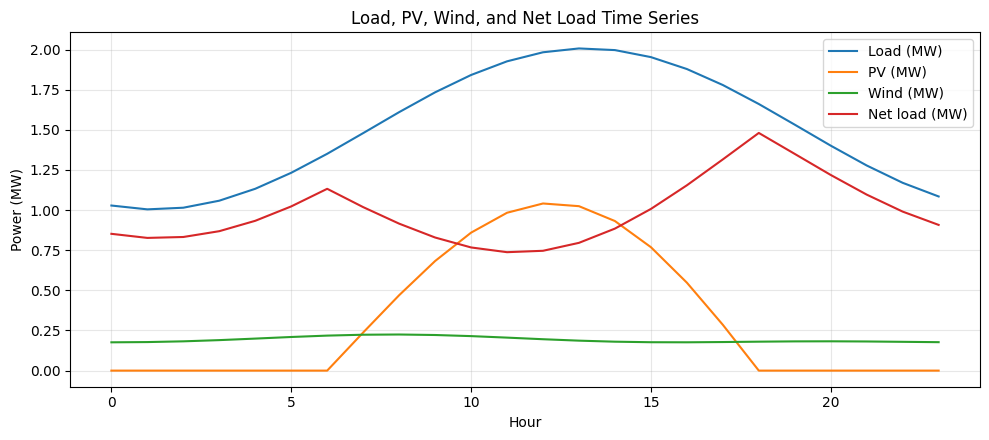

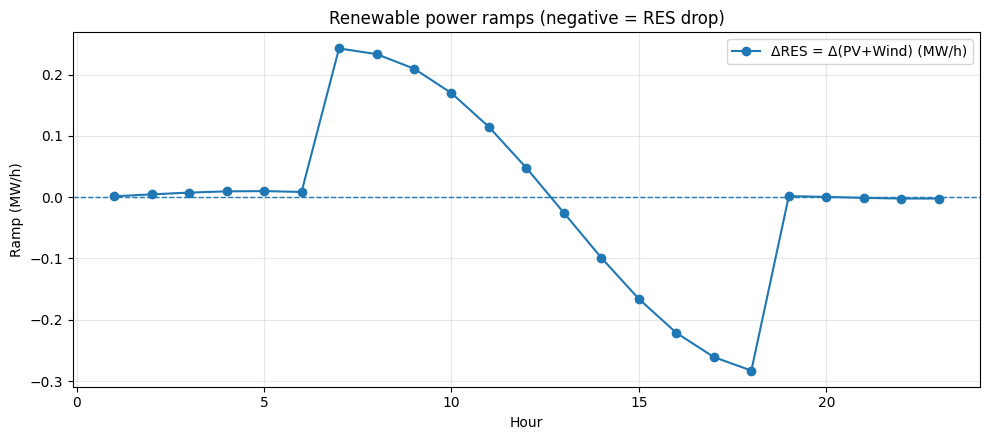

In [8]:
plt.figure(figsize=(10,4.5))
plt.plot(ts_df["hour"], ts_df["P_load_scaled_MW"], label="Load (MW)")
plt.plot(ts_df["hour"], ts_df["P_pv_MW"], label="PV (MW)")
plt.plot(ts_df["hour"], ts_df["P_wind_MW"], label="Wind (MW)")
plt.plot(ts_df["hour"], ts_df["P_net_MW"], label="Net load (MW)")
plt.xlabel("Hour"); plt.ylabel("Power (MW)")
plt.title("Load, PV, Wind, and Net Load Time Series")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "timeseries_load_pv_wind_netload.png"), dpi=300, bbox_inches="tight")
plt.show()

# Renewable drop ramps (key for frequency events)
ts_df["dP_res_MW"] = ts_df["P_res_MW"].diff()
plt.figure(figsize=(10,4.5))
plt.plot(ts_df["hour"], ts_df["dP_res_MW"], marker="o", label="ΔRES = Δ(PV+Wind) (MW/h)")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Hour"); plt.ylabel("Ramp (MW/h)")
plt.title("Renewable power ramps (negative = RES drop)")
plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "timeseries_res_ramps.png"), dpi=300, bbox_inches="tight")
plt.show()

In [9]:
penetrations = [0, 10, 25, 50, 75]
rows = []

for pen in penetrations:
    scale = pen/100.0
    tmp = ts_df.copy()
    tmp["P_res_pen_MW"] = scale * (tmp["P_pv_MW"] + tmp["P_wind_MW"])
    tmp["dP_res_pen_MW"] = tmp["P_res_pen_MW"].diff()  # most negative => worst RES drop
    idx = tmp["dP_res_pen_MW"].idxmin()
    evt = tmp.loc[idx]

    dP_deficit_MW = -float(evt["dP_res_pen_MW"])   # positive magnitude
    dPstep_pu = -(dP_deficit_MW / S_base_MW)       # negative in model convention

    rows.append([pen, float(evt["hour"]), float(evt["dP_res_pen_MW"]), dPstep_pu])

pen_event_df = pd.DataFrame(rows, columns=[
    "Penetration (%)", "Hour (worst RES drop)", "Worst ΔRES (MW/h)", "dPstep (pu)"
])
display(pen_event_df)
pen_event_df.to_csv(os.path.join(BASE_DIR, "penetration_event_mapping_res_drop.csv"), index=False)

,Penetration (%),Hour (worst RES drop),Worst ΔRES (MW/h),dPstep (pu)
0,0,1.0,0.000000,0.000000
1,10,18.0,-0.028303,-0.014105
2,25,18.0,-0.070757,-0.035262
3,50,18.0,-0.141515,-0.070523
4,75,18.0,-0.212272,-0.105785


In [12]:
import os, re

def simulate_openmodelica_model(
    omc, model_name,
    stopTime=15.0, stepSize=0.01,
    outputFormat="csv", parameter_overrides=None
):
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    n_intervals = int(round(stopTime / stepSize))
    cmd = (
        f'simulate({model_name}, stopTime={stopTime}, numberOfIntervals={n_intervals}, '
        f'outputFormat="{outputFormat}"{simflags})'
    )

    sim_out = omc.sendExpression(cmd)

    # OMPython usually returns dict
    if isinstance(sim_out, dict):
        # Print messages if any
        msg = sim_out.get("messages", "")
        if msg:
            print("OMC messages:\n", msg)

        res = sim_out.get("resultFile", "")
        if res and os.path.exists(res):
            return res, sim_out

        raise RuntimeError(
            f"Simulation did not produce a CSV file.\n"
            f"model={model_name}\n"
            f"resultFile='{res}'\n"
            f"messages:\n{msg}"
        )

    # Fallback parse from string output
    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        res = m.group(1)
        if os.path.exists(res):
            return res, sim_out
        raise RuntimeError(f"Parsed resultFile but it does not exist: {res}\nRaw:\n{txt}")

    raise RuntimeError(f"Could not parse simulate() output.\nRaw:\n{txt}")

In [13]:
# Debug single run
test_model = "ThesisFreqCases.BaseCase"
test_overrides = {"dPstep": dPstep_75, "tEvent": 1.0}

res_csv, sim_out = simulate_openmodelica_model(
    omc, test_model,
    stopTime=15.0, stepSize=0.01,
    parameter_overrides=test_overrides
)

print("CSV returned:", res_csv)
print("Exists:", os.path.exists(res_csv))

[OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase, stopTime=15.0, numberOfIntervals=1500, outputFormat="csv", simflags="-override=dPstep=-0.10578458987531997,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.

CSV returned: C:/Users/ADMIN/Desktop/ms-project/ThesisFreqCases.BaseCase_res.csv
Exists: True


In [14]:
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Robust simulation (never returns empty CSV path) ----------
def simulate_openmodelica_model(
    omc, model_name,
    stopTime=15.0, stepSize=0.01,
    outputFormat="csv", parameter_overrides=None
):
    simflags = ""
    if parameter_overrides:
        override_str = ",".join([f"{k}={v}" for k, v in parameter_overrides.items()])
        simflags = f', simflags="-override={override_str}"'

    n_intervals = int(round(stopTime / stepSize))
    cmd = (
        f'simulate({model_name}, stopTime={stopTime}, numberOfIntervals={n_intervals}, '
        f'outputFormat="{outputFormat}"{simflags})'
    )

    sim_out = omc.sendExpression(cmd)

    if isinstance(sim_out, dict):
        msg = sim_out.get("messages", "")
        if msg:
            print("OMC messages:\n", msg)

        res = sim_out.get("resultFile", "")
        if res and os.path.exists(res):
            return res, sim_out

        raise RuntimeError(
            f"Simulation did not produce a CSV file.\n"
            f"model={model_name}\n"
            f"resultFile='{res}'\n"
            f"messages:\n{msg}"
        )

    txt = str(sim_out)
    m = re.search(r'resultFile\s*=\s*"([^"]+)"', txt)
    if m:
        res = m.group(1)
        if os.path.exists(res):
            return res, sim_out
        raise RuntimeError(f"Parsed resultFile but it does not exist: {res}\nRaw:\n{txt}")

    raise RuntimeError(f"Could not parse simulate() output.\nRaw:\n{txt}")


# ---------- Load ThesisFreqCases outputs ----------
def load_thesis_frequency(result_csv):
    df = pd.read_csv(result_csv)
    for c in ["time", "fHz", "rocofHzps"]:
        if c not in df.columns:
            raise RuntimeError(f"Missing '{c}' in {result_csv}. Columns: {df.columns.tolist()[:25]}")
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["time", "fHz"]).sort_values("time")
    df = df.drop_duplicates(subset=["time"], keep="first").reset_index(drop=True)

    t = df["time"].values
    f_hz = df["fHz"].values
    rocof_trace = df["rocofHzps"].values
    return t, f_hz, rocof_trace


# ---------- Metrics ----------
def compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01):
    rocof = float(np.nanmax(np.abs(rocof_trace)))
    nadir = float(np.nanmin(f_hz))

    f_final = float(f_hz[-1])
    within = np.abs(f_hz - f_final) <= eps
    settling = np.nan
    for i in range(len(t)):
        if within[i] and np.all(within[i:]):
            settling = float(t[i])
            break
    return rocof, nadir, settling


# ---------- Plot ----------
def plot_cases(results_df, title, out_png):
    plt.figure(figsize=(9, 5))
    for _, r in results_df.iterrows():
        t, f_hz, _ = load_thesis_frequency(r["Result CSV"])
        plt.plot(t, f_hz, label=r["Case"])

    plt.axhline(49.75, linestyle="--", linewidth=1)
    plt.axhline(50.25, linestyle="--", linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Frequency (Hz)")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", out_png)


# ===================== RUN 75% RES EVENT =====================
CASE_MODELS = {
    "Baseline (no support)": "ThesisFreqCases.BaseCase",
    "GFM/VSM + droop": "ThesisFreqCases.DroopCase",
    "GFM/VSM + droop + FFR": "ThesisFreqCases.DroopFFRCase",
}

dPstep_75 = float(pen_event_df.loc[pen_event_df["Penetration (%)"] == 75, "dPstep (pu)"].iloc[0])
print("Using 75% RES event dPstep:", dPstep_75)

out_rows = []
for case, model in CASE_MODELS.items():
    res_csv, _ = simulate_openmodelica_model(
        omc, model, stopTime=15.0, stepSize=0.01,
        parameter_overrides={"dPstep": dPstep_75, "tEvent": 1.0}
    )

    t, f_hz, rocof_trace = load_thesis_frequency(res_csv)
    rocof, nadir, settling = compute_frequency_metrics(t, f_hz, rocof_trace, eps=0.01)
    out_rows.append([case, model, dPstep_75, rocof, nadir, settling, res_csv])

cases_75_df = pd.DataFrame(out_rows, columns=[
    "Case", "Model", "dPstep (pu)", "RoCoF (Hz/s)", "Nadir (Hz)", "Settling time (s)", "Result CSV"
])

display(cases_75_df)

csv_out = os.path.join(BASE_DIR, "dynamic_metrics_cases_75pct_res_event.csv")
png_out = os.path.join(BASE_DIR, "freq_cases_75pct_res_event.png")

cases_75_df.to_csv(csv_out, index=False)
plot_cases(cases_75_df, "Frequency response (75% RES worst renewable-drop event)", png_out)

print("Saved metrics:", csv_out)

Using 75% RES event dPstep: -0.10578458987531997


[OMC log for 'sendExpression(simulate(ThesisFreqCases.BaseCase, stopTime=15.0, numberOfIntervals=1500, outputFormat="csv", simflags="-override=dPstep=-0.10578458987531997,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.



[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopCase, stopTime=15.0, numberOfIntervals=1500, outputFormat="csv", simflags="-override=dPstep=-0.10578458987531997,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


OMC messages:
 LOG_SUCCESS       | info    | The initialization finished successfully without homotopy method.
LOG_SUCCESS       | info    | The simulation finished successfully.



[OMC log for 'sendExpression(simulate(ThesisFreqCases.DroopFFRCase, stopTime=15.0, numberOfIntervals=1500, outputFormat="csv", simflags="-override=dPstep=-0.10578458987531997,tEvent=1.0"), True)']: [translation:warning:496] The initial conditions are not fully specified. For more information set -d=initialization. In OMEdit Tools->Options->Simulation->Show additional information from the initialization process, in OMNotebook call setCommandLineOptions("-d=initialization").


OMC messages:
 Failed to build model: ThesisFreqCases.DroopFFRCase


RuntimeError: Simulation did not produce a CSV file.
model=ThesisFreqCases.DroopFFRCase
resultFile=''
messages:
Failed to build model: ThesisFreqCases.DroopFFRCase